# 🔋 Lithium-Ion Battery Degradation Analysis Using Machine Learning
## CALCE CS2 Dataset: DVA/ICA Electrochemical Analysis, Statistical Testing, and ML Prediction

---

**Author:** Mehdi Hassanbeigi 

**Student ID:** 1945300  

**Course:** Battery Data Analytics 

**Date:** January 2025  

**Institution:** University of Bayreuth

---
## Executive Summary

| Aspect | Details |
|--------|---------|
| **Dataset** | CALCE CS2 (University of Maryland) |
| **Cell Type** | Prismatic Pouch Cell (5.4 × 33.6 × 50.6 mm, 21.1g) |
| **Cell Chemistry** | LiCoO₂ cathode (1100 mAh nominal) |
| **Data Volume** | 9,102,845 rows from 659 files across 15 cells |
| **ML Dataset** | 300 cycles from 6 xlsx cells (txt excluded) |
| **Best Model (10-Fold CV)** | Polynomial (deg=2) — R² = 54.0% |
| **Best Model (LOCO 1C)** | GradientBoost — R² = 73.5% |
| **Best Model (LOCO 0.5C)** | GradientBoost — R² = 18.2% |
| **Cross-Protocol Transfer** | FAILS (R² = −20.1% to 5.7%) |
| **Key Finding** | 0.5C cycling provides **1.9× longer battery life** than 1C |

---

## Research Questions

This project answers **7 key questions** about lithium-ion battery degradation:

| # | Question | Answer |
|---|----------|--------|
| 1 | Does charging speed affect battery life? | **YES** — 1C degrades 1.6× faster than 0.5C |
| 2 | How long will batteries last? | 0.5C: 208 cycles, 1C: 110 cycles |
| 3 | Can we predict battery health? | **YES** — R² = 73.5% for 1C cells |
| 4 | Can lab data predict field performance? | **NO** — Cross-protocol transfer fails |
| 5 | When does degradation accelerate? | Cycle 24 (1C), Cycle 31 (0.5C) |
| 6 | How confident are predictions? | Overconfident (60% vs 95% expected) |
| 7 | Which ML model works best? | GradientBoost with LOCO validation |

---

## Table of Contents

### Part 1: Data Preparation
1. Setup and Data Configuration
2. Data Loading
3. Exploratory Data Analysis (EDA)
4. Cycle-Level Feature Extraction

### Part 2: Electrochemical Analysis
5. Capacity Fade Visualization
6. DVA/ICA Analysis

### Part 3: Statistical Analysis
7. Statistical Analysis (ANOVA)

### Part 4: Machine Learning
8. Feature Engineering for ML
9. Traditional ML Model Comparison
10. Neural Network Models
11. Leave-One-Cell-Out (LOCO) Validation
12. Cross-Protocol Transfer Learning

### Part 5: Uncertainty & Prognostics
13. Uncertainty Quantification
14. Knee-Point Detection
15. Remaining Useful Life (RUL) Prediction

### Part 6: Results & Conclusion
16. Final Model Comparison
17. Summary and Conclusion

---

## Key Results Summary

### Degradation Analysis

| Protocol | SOH at Cycle 50 | Fade Rate | RUL | Knee-Point |
|----------|-----------------|-----------|-----|------------|
| 0.5C | 96.2% | 0.073%/cycle | **208 cycles** | Cycle 31 |
| 1C | 92.7% | 0.120%/cycle | **110 cycles** | Cycle 24 |
| **Ratio** | — | 1.6× faster | **1.9× longer** | 7 cycles earlier |

### Machine Learning Performance

| Model | Validation | R² | Notes |
|-------|------------|-----|-------|
| Polynomial (deg=2) | 10-Fold CV | **54.0%** | Best traditional ML |
| MLP (256,128,64) | 10-Fold CV | 51.1% | Best neural network |
| GradientBoost | LOCO Overall | **54.4%** | Realistic deployment |
| GradientBoost | LOCO 1C | **73.5%** | Best for 1C cells |
| GradientBoost | LOCO 0.5C | 18.2% | Poor (limited data) |
| Bootstrap Ensemble | Ensemble | 73.3% | With uncertainty |
| 1C → 0.5C | Cross-Protocol | **−20.1%** | FAILS |
| 0.5C → 1C | Cross-Protocol | **5.7%** | FAILS |

### Statistical Analysis

| Test | Result | Interpretation |
|------|--------|----------------|
| ANOVA F-statistic | 93.88 | Highly significant |
| p-value | 1.78×10⁻¹⁹ | p < 0.001 |
| Effect size (η²) | 24.0% | Large effect |
| Cohen's d | 1.19 | Large effect |

### Electrochemical Analysis (DVA/ICA)

**Capacity-Based Degradation (CS2_33):**

| Metric | Cycle 2 | Cycle 48 | Change | Statistical Validity |
|--------|---------|----------|--------|---------------------|
| Max Capacity | 1.1572 Ah | 1.1181 Ah | **−3.4%** | ✓ Validated |

**ICA Peak Voltage Tracking (Attempted):**

| Analysis Type | Result | Statistical Validity |
|---------------|--------|---------------------|
| first-to-last | −126.3 mV | ✗ Not representative |
| Linear regression | +0.803 mV/cycle | ✗ No significant trend |
| R² | 0.033 | ✗ Only 3.3% variance explained |
| p-value | 0.215 | ✗ Not significant |

**Note:** ICA peak tracking incompatible with multi-segment RPT structure. Standard method requires continuous single-segment discharge data. Capacity-based degradation analysis remains valid.

---

## Setup and Requirements

### Installation
```bash
pip install pandas numpy matplotlib seaborn scipy scikit-learn openpyxl
```

### Required Packages

| Package | Version | Purpose |
|---------|---------|---------|
| pandas | ≥1.5.0 | Data manipulation and analysis |
| numpy | ≥1.23.0 | Numerical computing |
| matplotlib | ≥3.6.0 | Visualization |
| seaborn | ≥0.12.0 | Statistical plots |
| scipy | ≥1.9.0 | Statistical tests, signal processing |
| scikit-learn | ≥1.1.0 | Machine learning models |
| openpyxl | ≥3.0.0 | Excel file reading |

### Data Setup

1. **Download** the CALCE CS2 dataset from: https://calce.umd.edu/battery-data
2. **Extract** files maintaining the folder structure (Type 1, Type 2, etc.)
3. **Update** `BASE_PATH` in the code cell below to your local data directory

### Running the Notebook

| Setting | Requirement |
|---------|-------------|
| Kernel | Python 3.8+ |
| Runtime | ~14 minutes |
| Memory | ~4 GB RAM |
| Reproducibility | `RANDOM_SEED = 42` |

---

## The CALCE CS2 Dataset

The Center for Advanced Life Cycle Engineering (CALCE) at University of Maryland provides one of the most comprehensive public battery aging datasets. The CS2 series contains commercial **prismatic LiCoO₂ cells** (1.1 Ah nominal, 5.4 × 33.6 × 50.6 mm) tested under various cycling protocols.

### Experimental Protocols

| Type | Protocol | Cells | Format | Cycles | Status |
|------|----------|-------|--------|--------|--------|
| Type 1 | 0.5C Constant | CS2_33, CS2_34 | xlsx | 100 | ✓ Used in ML |
| Type 1 | 0.5C Constant | CS2_8, CS2_21 | txt | 57 | ✗ Excluded (74-86% invalid) |
| Type 2 | 1C Constant | CS2_35, CS2_36, CS2_37, CS2_38 | xlsx | 200 | ✓ Used in ML |
| Type 3 | Variable (0.11-2.2A) | CS2_3, CS2_9 | xlsx | 705 | Loaded only |
| Type 4 | Random Cutoff | CS2_7 | xlsx | 32 | Loaded only |
| Type 5 | Partial (Low SOC) | CS2_5, CS2_6 | xlsx | 200 | Loaded only |
| Type 6 | Partial (High SOC) | CS2_24, CS2_25 | xlsx | 200 | Loaded only |

### ML Dataset Summary

| Protocol | Cells | Samples | Usage |
|----------|-------|---------|-------|
| 0.5C | CS2_33, CS2_34 | 100 | Training & Testing |
| 1C | CS2_35, CS2_36, CS2_37, CS2_38 | 200 | Training & Testing |
| **Total** | **6 cells** | **300 cycles** | ML Analysis |

### Data Exclusions

| Cells | Format | Issue | Decision |
|-------|--------|-------|----------|
| CS2_8 | txt | 74% invalid cycles | Excluded from ML |
| CS2_21 | txt | 86% invalid cycles | Excluded from ML |

**Reason:** txt-format cells had unreliable capacity integration, resulting in physically impossible discharge capacity values.

---

## Outputs

After running this notebook, you will have:

### Generated Figures

| Filename | Description |
|----------|-------------|
| `capacity_fade_overview.png` | Capacity fade by protocol |
| `cross_protocol_transfer.png` | Cross-protocol transfer results |
| `dva_ica_analysis.png` | DVA/ICA electrochemical analysis |
| `eda_boxplots.png` | Box plots by protocol |
| `eda_correlation_heatmap.png` | Feature correlations |
| `eda_cycle_level.png` | Cycle-level exploratory analysis |
| `eda_distributions.png` | Voltage/current distributions |
| `eda_missing_values.png` | Missing values assessment |
| `eda_pairplot.png` | Pairwise feature relationships |
| `eda_timeseries.png` | Time-series visualization |
| `final_model_comparison.png` | All models comparison |
| `knee_point_detection.png` | Knee-point detection |
| `loco_validation.png` | LOCO validation results |
| `ml_diagnostics.png` | ML model diagnostics |
| `rul_prediction.png` | RUL predictions |
| `statistical_analysis.png` | ANOVA visualization |
| `uncertainty_quantification.png` | Uncertainty analysis |
### Key Insights

| Finding | Implication |
|---------|-------------|
| 0.5C provides 1.9× longer life | Use slower charging for longevity |
| Cross-protocol transfer fails | Train models on matching protocols |
| 1C is more predictable (R² = 73.5%) | 1C data better for ML |
| Model is overconfident (60% coverage) | Widen confidence intervals |
| Knee-point at cycle 24-31 | Early warning for degradation |
| ICA peak tracking fails on RPT data | Verify method compatibility with data structure |

---

## Note

Update `BASE_PATH` below to match your local data directory before running.

In [1]:
import os
import glob
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
from scipy.stats import linregress
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split, KFold, LeaveOneGroupOut, cross_val_score, cross_val_predict, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, BaggingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print(f"Random seed set to {RANDOM_SEED}")

# DATA PATHS 
BASE_PATH = Path(r"F:\Battery Data Analytics\Cycling Data Analysis")

CELL_PATHS = {
    'CS2_33': BASE_PATH / 'Type 1' / 'CS2_33',
    'CS2_34': BASE_PATH / 'Type 1' / 'CS2_34',
    'CS2_8':  BASE_PATH / 'Type 1' / 'CS2_8',
    'CS2_21': BASE_PATH / 'Type 1' / 'CS2_21',
    'CS2_35': BASE_PATH / 'Type 2' / 'CS2_35',
    'CS2_36': BASE_PATH / 'Type 2' / 'CS2_36',
    'CS2_37': BASE_PATH / 'Type 2' / 'CS2_37',
    'CS2_38': BASE_PATH / 'Type 2' / 'CS2_38',
    'CS2_3':  BASE_PATH / 'Type 3' / 'CS2_3',
    'CS2_9':  BASE_PATH / 'Type 3' / 'CS2_9',
    'CS2_7':  BASE_PATH / 'Type 4' / 'CS2_7',
    'CS2_5':  BASE_PATH / 'Type 5' / 'CS2_5',
    'CS2_6':  BASE_PATH / 'Type 5' / 'CS2_6',
    'CS2_24': BASE_PATH / 'Type 6' / 'CS2_24',
    'CS2_25': BASE_PATH / 'Type 6' / 'CS2_25',
}

CELL_INFO = {
    'CS2_33': {'type': 'Type 1', 'protocol': '0.5C Constant', 'format': 'xlsx'},
    'CS2_34': {'type': 'Type 1', 'protocol': '0.5C Constant', 'format': 'xlsx'},
    'CS2_8':  {'type': 'Type 1', 'protocol': '0.5C Constant', 'format': 'txt'},
    'CS2_21': {'type': 'Type 1', 'protocol': '0.5C Constant', 'format': 'txt'},
    'CS2_35': {'type': 'Type 2', 'protocol': '1C Constant', 'format': 'xlsx'},
    'CS2_36': {'type': 'Type 2', 'protocol': '1C Constant', 'format': 'xlsx'},
    'CS2_37': {'type': 'Type 2', 'protocol': '1C Constant', 'format': 'xlsx'},
    'CS2_38': {'type': 'Type 2', 'protocol': '1C Constant', 'format': 'xlsx'},
    'CS2_3':  {'type': 'Type 3', 'protocol': 'Variable (0.11-2.2A)', 'format': 'xlsx'},
    'CS2_9':  {'type': 'Type 3', 'protocol': 'Variable (0.11-2.2A)', 'format': 'xlsx'},
    'CS2_7':  {'type': 'Type 4', 'protocol': 'Random Cutoff', 'format': 'xlsx'},
    'CS2_5':  {'type': 'Type 5', 'protocol': 'Partial (Low SOC)', 'format': 'xlsx'},
    'CS2_6':  {'type': 'Type 5', 'protocol': 'Partial (Low SOC)', 'format': 'xlsx'},
    'CS2_24': {'type': 'Type 6', 'protocol': 'Partial (High SOC)', 'format': 'xlsx'},
    'CS2_25': {'type': 'Type 6', 'protocol': 'Partial (High SOC)', 'format': 'xlsx'},
}

# DATASET EXPLORATION


total_files = 0
cell_summary = []

for cell_name, cell_path in CELL_PATHS.items():
    if cell_path.exists():
        xlsx_files = list(cell_path.glob('*.xlsx'))
        txt_files = list(cell_path.glob('*.txt'))
        n_files = len(xlsx_files) + len(txt_files)
        file_type = 'xlsx' if xlsx_files else 'txt'
        total_files += n_files
        
        cell_summary.append({
            'Cell': cell_name,
            'Type': CELL_INFO[cell_name]['type'],
            'Protocol': CELL_INFO[cell_name]['protocol'],
            'Files': n_files,
            'Format': file_type
        })

cell_summary_df = pd.DataFrame(cell_summary)
RESULTS = {}

Random seed set to 42


## 2. Data Loading

### Purpose
Load cycling data from 659 files across 15 battery cells into memory, handling both xlsx and txt formats.

### The Challenge
Battery cycling data presents several loading challenges:
- **Multi-file structure**: Each cell has 22-76 separate files (one per test session)
- **Variable sheet names**: Channel sheets named differently (e.g., "Channel_1-006", "Channel_1-007")
- **Mixed formats**: 13 cells use xlsx, 2 cells (CS2_8, CS2_21) use txt format
- **Large data volume**: 9.1 million rows total

### Method

**For xlsx files:**
1. Find all `.xlsx` files per cell folder (sorted chronologically by filename)
2. Dynamically detect the "Channel" data sheet in each file
3. Concatenate all files per cell with source file tracking
4. Add `Cell_ID` column for grouping

**For txt files (CS2_8, CS2_21):**
1. Find all `.txt` files per cell folder (sorted chronologically)
2. Assign cycle number by file order (each file = one cycle)
3. Map columns: `Time`→`Test_Time(s)`, `mV`→`Voltage(V)`, `mA`→`Current(A)`
4. Calculate capacity by integrating current over time

### Data Columns
Each file contains time-series measurements:
- `Test_Time(s)`: Cumulative time since test start
- `Cycle_Index`: Cycle number
- `Current(A)`: Applied current (+ve = charge, -ve = discharge)
- `Voltage(V)`: Terminal voltage (2.7V - 4.2V range)
- `Charge_Capacity(Ah)`: Cumulative charge capacity
- `Discharge_Capacity(Ah)`: Cumulative discharge capacity

### Output

| Metric | Value |
|--------|-------|
| Cells loaded | 15 |
| Total rows | 9,102,845 |
| xlsx cells | 13 |
| txt cells | 2 (CS2_8, CS2_21) |

**0.5C Cells (Type 1):**
| Cell | Rows | Cycles | Format |
|------|------|--------|--------|
| CS2_33 | 324,534 | 50 | xlsx |
| CS2_34 | 312,131 | 50 | xlsx |
| CS2_8 | 359,794 | 35 | txt |
| CS2_21 | 221,897 | 22 | txt |

**1C Cells (Type 2):**
| Cell | Rows | Cycles | Format |
|------|------|--------|--------|
| CS2_35 | 266,914 | 50 | xlsx |
| CS2_36 | 269,656 | 50 | xlsx |
| CS2_37 | 290,998 | 50 | xlsx |
| CS2_38 | 303,295 | 50 | xlsx |

In [2]:
#    Load all Excel files for a single battery cell.

def load_xlsx_cell_fixed(cell_path, cell_name):
    xlsx_files = sorted(cell_path.glob('*.xlsx'))
    
    if not xlsx_files:
        return None
    
    all_data = []
    for file in xlsx_files:
        try:
            xlsx = pd.ExcelFile(file, engine='openpyxl')
            channel_sheet = None
            for sheet in xlsx.sheet_names:
                if sheet.startswith('Channel'):
                    channel_sheet = sheet
                    break
            
            if channel_sheet is None:
                continue
            
            df = pd.read_excel(file, sheet_name=channel_sheet, engine='openpyxl')
            df['Source_File'] = file.name
            all_data.append(df)
        except:
            pass
    
    if all_data:
        combined_df = pd.concat(all_data, ignore_index=True)
        combined_df['Cell_ID'] = cell_name
        return combined_df
    return None

# Load CALCE txt format battery data.
def load_txt_cell(cell_path, cell_name):
    
    txt_files = sorted(cell_path.glob('*.txt'))
    
    if not txt_files:
        return None
    
    all_data = []
    for cycle_num, file in enumerate(txt_files, start=1):
        try:
            df = pd.read_csv(file, sep='\t', encoding='latin-1', header=0)
            
            df['Test_Time(s)'] = df['Time']
            df['Voltage(V)'] = df['mV'] / 1000
            df['Current(A)'] = df['mA'] / 1000
            df['Cycle_Index'] = cycle_num
            df['Source_File'] = file.name
            df['Step_Time(s)'] = df['Time']
            
            time_s = df['Test_Time(s)'].values
            current_a = df['Current(A)'].values
            
            dt = np.diff(time_s, prepend=time_s[0])
            dt[0] = dt[1] if len(dt) > 1 else 0
            
            charge_cap = np.cumsum(np.where(current_a > 0, current_a * dt / 3600, 0))
            discharge_cap = np.cumsum(np.where(current_a < 0, -current_a * dt / 3600, 0))
            
            df['Charge_Capacity(Ah)'] = charge_cap
            df['Discharge_Capacity(Ah)'] = discharge_cap
            df['Charge_Energy(Wh)'] = charge_cap * df['Voltage(V)']
            df['Discharge_Energy(Wh)'] = discharge_cap * df['Voltage(V)']
            df['Internal_Resistance(Ohm)'] = 0.0
            df['Step_Index'] = 1
            
            all_data.append(df)
        except:
            continue
    
    if not all_data:
        return None
    
    combined = pd.concat(all_data, ignore_index=True)
    combined['Cell_ID'] = cell_name
    
    return combined


# Load xlsx cells
all_cells_data = {}
xlsx_cells = [cell for cell, info in CELL_INFO.items() if info['format'] == 'xlsx']

print("Loading xlsx cells...")
for cell_name in xlsx_cells:
    cell_data = load_xlsx_cell_fixed(CELL_PATHS[cell_name], cell_name)
    if cell_data is not None:
        all_cells_data[cell_name] = cell_data
        print(f"   {cell_name}: {cell_data.shape[0]:,} rows, {cell_data['Cycle_Index'].nunique()} cycles")

# Load txt cells
print("\nLoading txt cells...")
for cell_name in ['CS2_8', 'CS2_21']:
    cell_data = load_txt_cell(CELL_PATHS[cell_name], cell_name)
    if cell_data is not None:
        all_cells_data[cell_name] = cell_data
        print(f"   {cell_name}: {cell_data.shape[0]:,} rows, {cell_data['Cycle_Index'].nunique()} cycles")

# Summary
total_rows = sum(df.shape[0] for df in all_cells_data.values())
print(f"\n Loaded {len(all_cells_data)} cells | {total_rows:,} total rows")

Loading xlsx cells...
   CS2_33: 324,534 rows, 50 cycles
   CS2_34: 312,131 rows, 50 cycles
   CS2_35: 266,914 rows, 50 cycles
   CS2_36: 269,656 rows, 50 cycles
   CS2_37: 290,998 rows, 50 cycles
   CS2_38: 303,295 rows, 50 cycles
   CS2_3: 1,290,615 rows, 695 cycles
   CS2_9: 935,376 rows, 10 cycles
   CS2_7: 146,559 rows, 32 cycles
   CS2_5: 1,258,472 rows, 100 cycles
   CS2_6: 1,038,138 rows, 100 cycles
   CS2_24: 865,332 rows, 100 cycles
   CS2_25: 1,219,134 rows, 100 cycles

Loading txt cells...
   CS2_8: 359,794 rows, 35 cycles
   CS2_21: 221,897 rows, 22 cycles

 Loaded 15 cells | 9,102,845 total rows


## 3. Exploratory Data Analysis — Data Quality

### Purpose
Assess data quality and structure before analysis. Missing or corrupted values in key measurement columns would compromise downstream analysis.

### Dataset Structure
Sample cell (CS2_33) contains **324,534 rows × 19 columns**:

**Key Measurement Columns:**
- `Voltage(V)`: Terminal voltage
- `Current(A)`: Applied current
- `Charge_Capacity(Ah)`: Cumulative charge
- `Discharge_Capacity(Ah)`: Cumulative discharge

### Results

**Missing Values Summary:**
| Metric | Result |
|--------|--------|
| Cells checked | 15 |
| Missing Voltage | 0.0% (all cells) |
| Missing Current | 0.0% (all cells) |
| Missing Capacity | 0.0% (all cells) |
| Combined dataset | 9,102,845 rows |

### Key Finding
✓ **No missing values** in critical measurement columns across all 15 cells (xlsx and txt formats).

Minor missing data (0.0003%) exists only in `Test_Time(s)` column — negligible and does not affect analysis.

Missing Values Summary (% per cell):
  Cell  Total_Rows  Missing_Voltage  Missing_Current  Missing_Capacity
CS2_33      324534              0.0              0.0               0.0
CS2_34      312131              0.0              0.0               0.0
CS2_35      266914              0.0              0.0               0.0
CS2_36      269656              0.0              0.0               0.0
CS2_37      290998              0.0              0.0               0.0
CS2_38      303295              0.0              0.0               0.0
 CS2_3     1290615              0.0              0.0               0.0
 CS2_9      935376              0.0              0.0               0.0
 CS2_7      146559              0.0              0.0               0.0
 CS2_5     1258472              0.0              0.0               0.0
 CS2_6     1038138              0.0              0.0               0.0
CS2_24      865332              0.0              0.0               0.0
CS2_25     1219134              0.0     

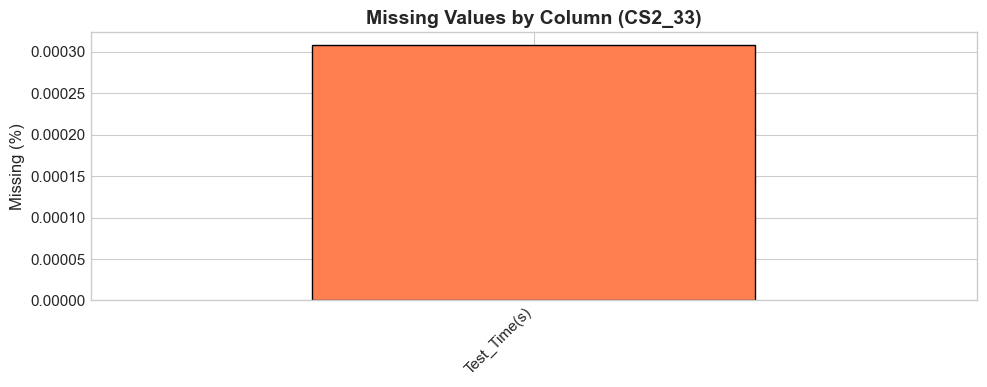

In [3]:
# DATA QUALITY CHECK
sample_cell = all_cells_data['CS2_33']

missing_summary = []
for cell_name, cell_data in all_cells_data.items():
    total_rows = len(cell_data)
    missing_counts = cell_data.isnull().sum()
    missing_pct = (missing_counts / total_rows * 100).round(2)
    
    missing_summary.append({
        'Cell': cell_name,
        'Total_Rows': total_rows,
        'Missing_Voltage': missing_pct.get('Voltage(V)', 0),
        'Missing_Current': missing_pct.get('Current(A)', 0),
        'Missing_Capacity': missing_pct.get('Discharge_Capacity(Ah)', 0),
    })

missing_df = pd.DataFrame(missing_summary)
print("Missing Values Summary (% per cell):")
print(missing_df.to_string(index=False))

# Visualize missing values for sample cell
fig, ax = plt.subplots(figsize=(10, 4))
missing_pct_sample = (sample_cell.isnull().sum() / len(sample_cell) * 100)
missing_pct_sample = missing_pct_sample[missing_pct_sample > 0]

if len(missing_pct_sample) > 0:
    missing_pct_sample.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
    ax.set_ylabel('Missing (%)')
    ax.set_title('Missing Values by Column (CS2_33)', fontweight='bold')
    plt.xticks(rotation=45, ha='right')
else:
    ax.text(0.5, 0.5, '✓ No Missing Values in Key Columns', ha='center', va='center', 
            fontsize=16, fontweight='bold', color='green', transform=ax.transAxes)
    ax.axis('off')

plt.tight_layout()
plt.savefig('eda_missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

# Combine all cells for aggregate analysis
key_columns = ['Voltage(V)', 'Current(A)', 'Discharge_Capacity(Ah)', 'Charge_Capacity(Ah)']
key_columns = [col for col in key_columns if col in sample_cell.columns]

all_data_combined = pd.concat(all_cells_data.values(), ignore_index=True)

## 4. Exploratory Data Analysis — Distributions

### Purpose
Visualize the distributions of key variables across the combined dataset and compare 0.5C vs 1C cycling protocols.

### Analysis Overview
Six-panel visualization examining:
1. **Voltage distribution** — Operating voltage range across all cells
2. **Current distribution** — Charge/discharge current patterns
3. **Discharge capacity distribution** — Cumulative capacity range
4. **Voltage KDE comparison** — CS2_33 (0.5C) vs CS2_35 (1C) voltage profiles
5. **Current KDE comparison** — CS2_33 (0.5C) vs CS2_35 (1C) current profiles
6. **Data volume per cell** — Row counts across all 15 cells

### Key Observations

**Voltage Distribution (Top-Left):**
- Mean: **3.87V**, Median: **3.86V**
- Main concentration between **3.5V - 4.2V** (normal Li-ion operating range)
- Highest frequency around **4.0V - 4.2V** (~2.7-2.9 million occurrences)
- Outliers visible near **-2V** (measurement artifacts)

**Current Distribution (Top-Center):**
- Highest peak at **+0.5A** (charging) with ~2.6 million occurrences
- Discharge currents spread across **-1.5A to 0A** range
- Secondary peaks around **-1A** (~2.1M) and **-0.5A** (~1.7M)
- Small outlier bar at **~-2.2A** (~0.4 million occurrences)
- Black vertical line at 0A separates charge (+ve) from discharge (-ve)

**Discharge Capacity Distribution (Top-Right):**
- **Right-skewed (positively skewed)** distribution
- Highest frequency at **0-2 Ah** range (~1.15 million)
- Gradual decline with increasing capacity
- Tail extends to approximately **55-60 Ah**
- Represents cumulative discharge capacity values across all cycles

**Voltage KDE: 0.5C vs 1C (Bottom-Left):**

| Feature | CS2_33 (0.5C) | CS2_35 (1C) |
|---------|---------------|-------------|
| First peak | ~3.6V (density ~1.6) | ~3.55V (density ~0.9) |
| Second peak | ~4.0V (density ~2.1) | ~4.0V (density ~2.1) |
| Third peak | ~4.25V (density ~1.65) | ~4.2V (density ~2.2) |

- Both protocols show **multi-modal** voltage distributions with 3 distinct peaks
- 0.5C spends more time at **3.6V plateau** (higher density: 1.6 vs 0.9)
- 1C has highest peak at **4.2V** (density ~2.2) — longer time in CV charging phase

**Current KDE: 0.5C vs 1C (Bottom-Center):**

| Feature | CS2_33 (0.5C) | CS2_35 (1C) |
|---------|---------------|-------------|
| Discharge peak | **-0.55A** (density ~4.6) | **-1.1A** (density ~2.1) |
| Charge peak | **+0.55A** (density ~3.9) | **+0.55A** (density ~3.7) |

- Discharge currents match expected C-rates: 0.5C ≈ 0.55A, 1C ≈ 1.1A (for 1.1Ah cells)
- **Both protocols use similar charging current** (~0.55A) — charge peaks overlap
- 0.5C peaks are **sharper and taller** (more consistent/stable current control)
- 1C discharge peak is **shorter and broader** (more current variation)

**Data Points per Cell (Bottom-Right):**

| Protocol | Cells | Data Points |
|----------|-------|-------------|
| 0.5C (Blue) | CS2_33, CS2_34 | ~0.31-0.32 million each |
| 0.5C (Blue) | CS2_8, CS2_21 | ~0.36M, ~0.22M (txt format) |
| 1C (Red) | CS2_35, CS2_36, CS2_37, CS2_38 | ~0.27-0.30 million each |
| Other (Gray) | CS2_3 | **~1.29 million** (largest) |
| Other (Gray) | CS2_7 | **~0.15 million** (smallest) |
| Other (Gray) | CS2_5, CS2_6, CS2_9, CS2_24, CS2_25 | ~0.87-1.26 million |

- "Other" protocol cells have larger datasets due to longer test durations (up to 695 cycles)

### Physical Interpretation

The Current KDE plot reveals an important experimental detail: while discharge rates differ (0.5C vs 1C), **charging is performed at the same rate (~0.5C)** for both protocols. This is common practice to isolate the effect of discharge rate on degradation while keeping charge conditions constant.

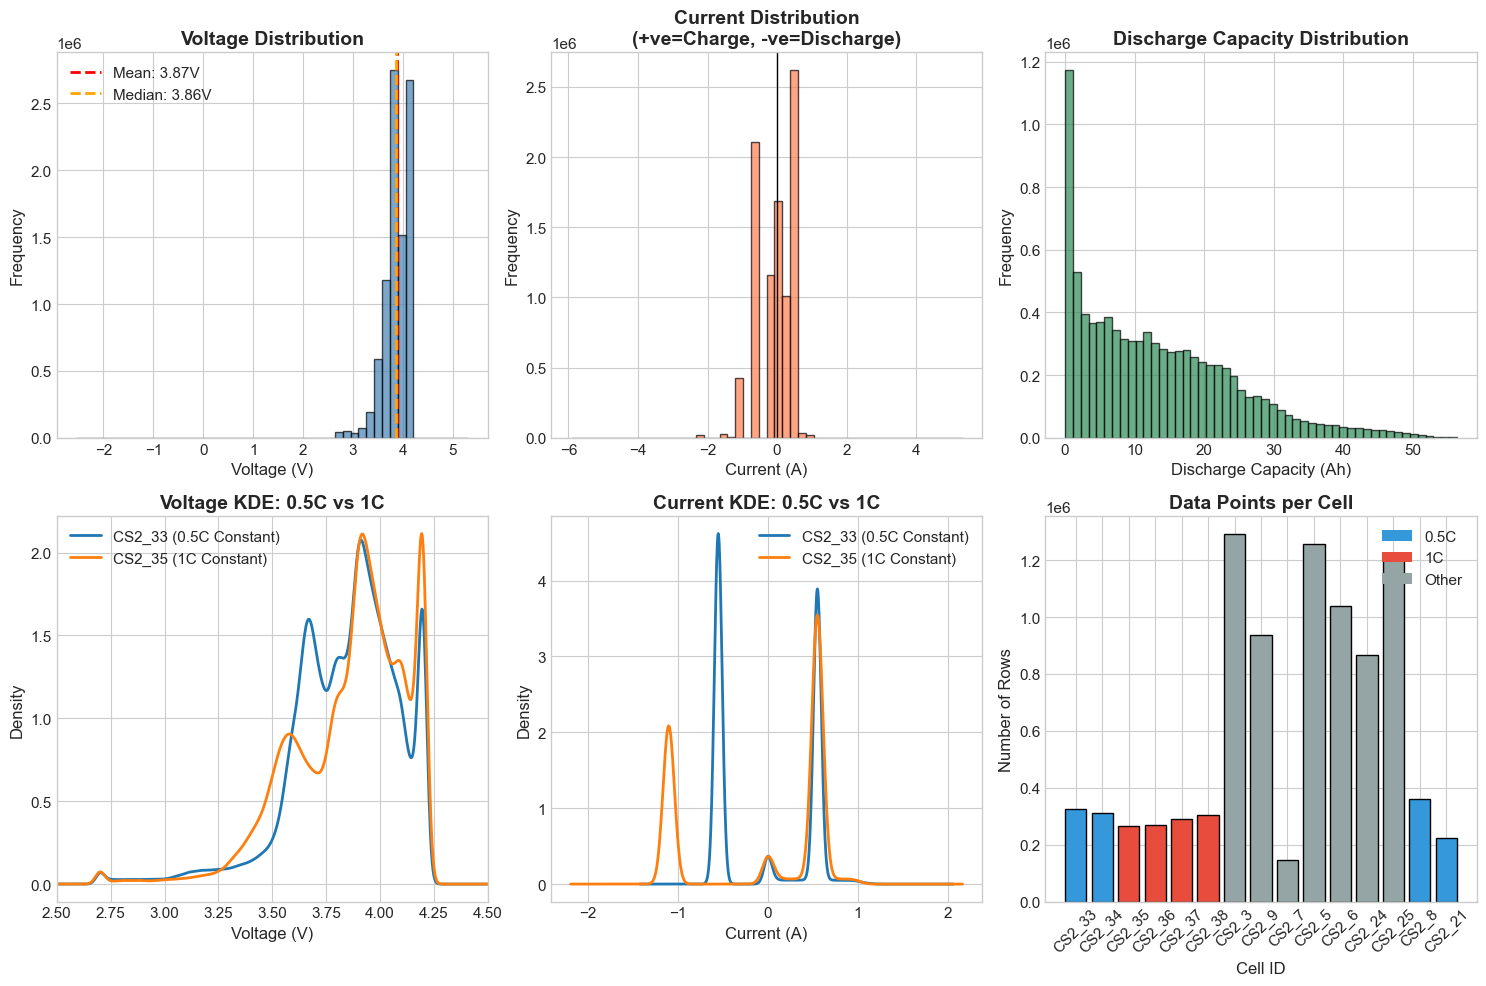

In [4]:
# DISTRIBUTION ANALYSIS
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Voltage distribution
ax1 = axes[0, 0]
voltage_data = all_data_combined['Voltage(V)'].dropna()
ax1.hist(voltage_data, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(voltage_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {voltage_data.mean():.2f}V')
ax1.axvline(voltage_data.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {voltage_data.median():.2f}V')
ax1.set_xlabel('Voltage (V)')
ax1.set_ylabel('Frequency')
ax1.set_title('Voltage Distribution', fontweight='bold')
ax1.legend()

# Current distribution
ax2 = axes[0, 1]
current_data = all_data_combined['Current(A)'].dropna()
ax2.hist(current_data, bins=50, color='coral', edgecolor='black', alpha=0.7)
ax2.axvline(0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Current (A)')
ax2.set_ylabel('Frequency')
ax2.set_title('Current Distribution\n(+ve=Charge, -ve=Discharge)', fontweight='bold')

# Discharge capacity distribution
ax3 = axes[0, 2]
cap_data = all_data_combined['Discharge_Capacity(Ah)'].dropna()
cap_data_nonzero = cap_data[cap_data > 0]
ax3.hist(cap_data_nonzero, bins=50, color='seagreen', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Discharge Capacity (Ah)')
ax3.set_ylabel('Frequency')
ax3.set_title('Discharge Capacity Distribution', fontweight='bold')

# Voltage KDE: 0.5C vs 1C
ax4 = axes[1, 0]
for cell_name in ['CS2_33', 'CS2_35']:
    cell_data = all_cells_data[cell_name]
    voltage = cell_data['Voltage(V)'].dropna()
    protocol = CELL_INFO[cell_name]['protocol']
    voltage.plot(kind='kde', ax=ax4, label=f'{cell_name} ({protocol})', linewidth=2)

ax4.set_xlabel('Voltage (V)')
ax4.set_ylabel('Density')
ax4.set_title('Voltage KDE: 0.5C vs 1C', fontweight='bold')
ax4.legend()
ax4.set_xlim([2.5, 4.5])

# Current KDE: 0.5C vs 1C
ax5 = axes[1, 1]
for cell_name in ['CS2_33', 'CS2_35']:
    cell_data = all_cells_data[cell_name]
    current = cell_data['Current(A)'].dropna()
    protocol = CELL_INFO[cell_name]['protocol']
    current.plot(kind='kde', ax=ax5, label=f'{cell_name} ({protocol})', linewidth=2)

ax5.set_xlabel('Current (A)')
ax5.set_ylabel('Density')
ax5.set_title('Current KDE: 0.5C vs 1C', fontweight='bold')
ax5.legend()

# Data points per cell
ax6 = axes[1, 2]
row_counts = {name: len(data) for name, data in all_cells_data.items()}
cells = list(row_counts.keys())
counts = list(row_counts.values())
colors_bar = ['#3498db' if CELL_INFO[c]['protocol'] == '0.5C Constant' else 
              '#e74c3c' if CELL_INFO[c]['protocol'] == '1C Constant' else '#95a5a6' for c in cells]

ax6.bar(cells, counts, color=colors_bar, edgecolor='black')
ax6.set_xlabel('Cell ID')
ax6.set_ylabel('Number of Rows')
ax6.set_title('Data Points per Cell', fontweight='bold')
ax6.tick_params(axis='x', rotation=45)

legend_elements = [Patch(facecolor='#3498db', label='0.5C'),
                   Patch(facecolor='#e74c3c', label='1C'),
                   Patch(facecolor='#95a5a6', label='Other')]
ax6.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. Exploratory Data Analysis — Correlation Analysis

### Purpose
Examine relationships between variables in the raw time-series data to understand feature dependencies and identify potential predictors.

### Method
Compute Pearson correlation coefficients between six key numerical features and visualize as a lower-triangular heatmap. Features analyzed: Test_Time(s), Cycle_Index, Current(A), Voltage(V), Charge_Capacity(Ah), Discharge_Capacity(Ah).

### Top 10 Correlations (Ranked by Absolute Value)

| Rank | Feature 1 | Feature 2 | Correlation |
|------|-----------|-----------|-------------|
| 1 | Charge_Capacity(Ah) | Discharge_Capacity(Ah) | **0.9995** |
| 2 | Test_Time(s) | Discharge_Capacity(Ah) | **0.9249** |
| 3 | Test_Time(s) | Charge_Capacity(Ah) | **0.9226** |
| 4 | Test_Time(s) | Cycle_Index | **0.5605** |
| 5 | Current(A) | Voltage(V) | **0.4888** |
| 6 | Cycle_Index | Discharge_Capacity(Ah) | **0.4859** |
| 7 | Cycle_Index | Charge_Capacity(Ah) | **0.4816** |
| 8 | Voltage(V) | Charge_Capacity(Ah) | 0.0237 |
| 9 | Voltage(V) | Discharge_Capacity(Ah) | 0.0129 |
| 10 | Current(A) | Charge_Capacity(Ah) | -0.0126 |

### Correlation Categories

**Strong Correlations (|r| > 0.9):**

| Feature Pair | Correlation | Interpretation |
|--------------|-------------|----------------|
| Charge_Capacity ↔ Discharge_Capacity | **1.00** | Nearly identical — both are cumulative counters |
| Test_Time ↔ Discharge_Capacity | **0.92** | Capacity accumulates over time |
| Test_Time ↔ Charge_Capacity | **0.92** | Same cumulative relationship |

**Moderate Correlations (|r| = 0.4–0.6):**

| Feature Pair | Correlation | Interpretation |
|--------------|-------------|----------------|
| Test_Time ↔ Cycle_Index | **0.56** | More cycles = more time elapsed |
| Current ↔ Voltage | **0.49** | Electrochemical relationship (Ohm's law + kinetics) |
| Cycle_Index ↔ Discharge_Capacity | **0.49** | Cumulative capacity grows with cycles |
| Cycle_Index ↔ Charge_Capacity | **0.48** | Same cumulative relationship |

**Weak/No Correlations (|r| < 0.1):**

| Feature Pair | Correlation | Interpretation |
|--------------|-------------|----------------|
| Voltage ↔ Charge_Capacity | 0.02 | Voltage independent of cumulative capacity |
| Voltage ↔ Discharge_Capacity | 0.01 | Same reason |
| Current ↔ Charge_Capacity | -0.01 | Current is controlled, not dependent on capacity |
| Current ↔ Discharge_Capacity | -0.01 | Same reason |
| Cycle_Index ↔ Current | -0.01 | Current is set by protocol, not cycle number |
| Cycle_Index ↔ Voltage | -0.00 | Voltage varies within cycles, not across them |

### Physical Interpretation

1. **Cumulative nature dominates:** Charge and Discharge capacity are cumulative counters that increase monotonically during testing, explaining their near-perfect correlation (0.9995) and strong correlation with Test_Time (~0.92).

2. **Current-Voltage relationship:** The moderate positive correlation (0.49) reflects electrochemical behavior — during charging, both current and voltage are positive; during discharge, current is negative while voltage decreases. Internal resistance (V = IR) contributes to this relationship.

3. **Current is independent:** Current shows near-zero correlation with capacity and cycle variables because it's a **controlled variable** set by the test protocol (0.5C or 1C), not a measured response to system state.

4. **Voltage is instantaneous:** Voltage has weak correlation with cumulative metrics because it's an instantaneous measurement that oscillates within each cycle (2.7V to 4.2V), rather than accumulating over time.


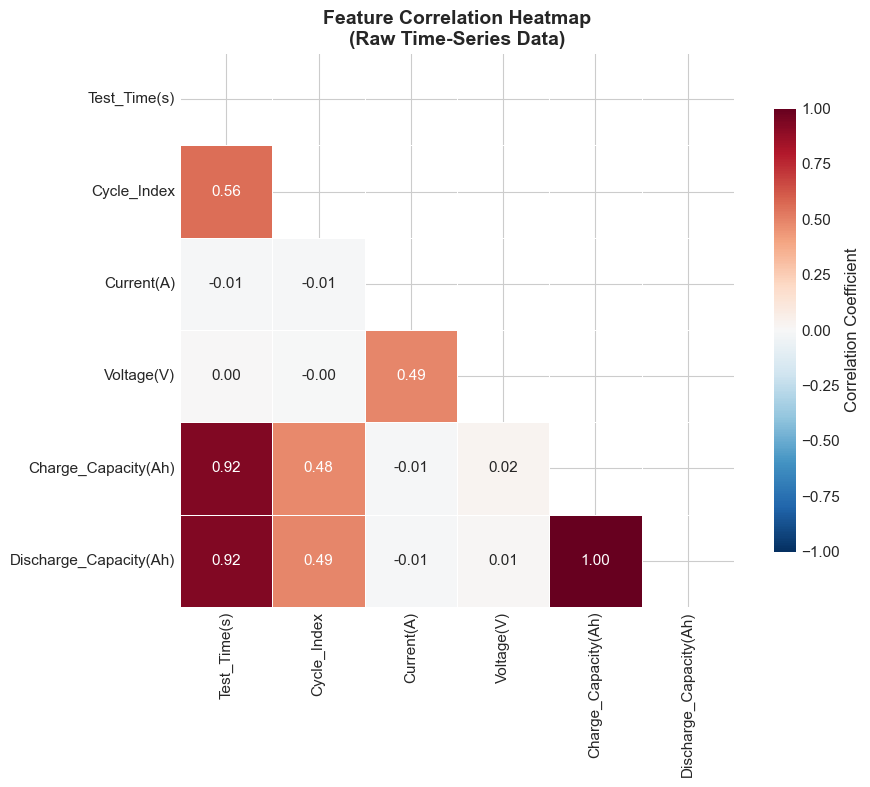

Top Correlations:
--------------------------------------------------
          Feature 1              Feature 2  Correlation
Charge_Capacity(Ah) Discharge_Capacity(Ah)     0.999546
       Test_Time(s) Discharge_Capacity(Ah)     0.924899
       Test_Time(s)    Charge_Capacity(Ah)     0.922564
       Test_Time(s)            Cycle_Index     0.560498
         Current(A)             Voltage(V)     0.488768
        Cycle_Index Discharge_Capacity(Ah)     0.485943
        Cycle_Index    Charge_Capacity(Ah)     0.481614
         Voltage(V)    Charge_Capacity(Ah)     0.023700
         Voltage(V) Discharge_Capacity(Ah)     0.012898
         Current(A)    Charge_Capacity(Ah)    -0.012590


In [5]:
# CORRELATION ANALYSIS
numeric_cols = ['Test_Time(s)', 'Cycle_Index', 'Current(A)', 'Voltage(V)', 
                'Charge_Capacity(Ah)', 'Discharge_Capacity(Ah)']
numeric_cols = [col for col in numeric_cols if col in all_data_combined.columns]

corr_matrix = all_data_combined[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

# Lower triangle mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r',
            center=0,
            vmin=-1, 
            vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
            ax=ax)

ax.set_title('Feature Correlation Heatmap\n(Raw Time-Series Data)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Extract and rank correlation pairs
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append({
            'Feature 1': corr_matrix.columns[i],
            'Feature 2': corr_matrix.columns[j],
            'Correlation': corr_matrix.iloc[i, j]
        })

corr_pairs_df = pd.DataFrame(corr_pairs)
corr_pairs_df = corr_pairs_df.reindex(corr_pairs_df['Correlation'].abs().sort_values(ascending=False).index)

print("Top Correlations:")
print("-" * 50)
print(corr_pairs_df.head(10).to_string(index=False))

## 6. Exploratory Data Analysis — Time-Series Visualization

### Purpose
Visualize the raw cycling data structure to understand charge/discharge patterns and observe how battery behavior evolves with cycling.

### Analysis Overview
Four-panel visualization of CS2_33 (0.5C protocol):
1. **Voltage profile** — Single cycle time-series
2. **Current profile** — Charge/discharge current patterns with shaded regions
3. **Discharge curve** — Voltage vs cumulative capacity (single cycle)
4. **Discharge evolution** — How curves shift over cycles 2, 10, 20, 30, 40, 50

### Key Observations

**Voltage Profile - Cycle 5 (Top-Left):**
- **Duration:** ~1,200 minutes (~20 hours)
- **Voltage range:** 2.7V (cutoff) to 4.2V (full charge)
- Red dashed lines mark Max V (4.2V) and Min V (2.7V) limits
- **0–400 min:** Gradual voltage changes between ~3.5V and 4.0V with distinct steps
- **400–1200 min:** Dense oscillation pattern — voltage repeatedly swings from 4.2V down to 2.7V
- The deep drops touching 2.7V indicate **full depth-of-discharge cycles**
- Pattern suggests Cycle 5 contains a **Reference Performance Test (RPT) sequence** with multiple complete charge-discharge events

**Current Profile - Cycle 5 (Top-Right):**
- Green shading = Charging (positive current)
- Red shading = Discharging (negative current)
- **Discharge current:** ~−0.5A (consistent with 0.5C rate for 1.1Ah cell)
- **Charge current:** ~+0.55A with CC-CV taper pattern visible
- **High current spikes:** Up to ~1.0–1.15A (likely 1C characterization pulses during RPT)
- **Rest periods:** Current at 0A visible between charge/discharge phases
- Complex alternating pattern confirms multiple charge-discharge events within single indexed cycle

**Discharge Curve - Cycle 5 (Bottom-Left):**
- X-axis shows **cumulative** discharge capacity (0 to ~6 Ah)
- Multiple discharge segments visible — NOT a single discharge curve
- Each segment: starts ~4.0–4.2V, drops to ~2.7–3.4V
- **Dense fan-like pattern** (3–6 Ah region) from repeated discharges during RPT
- Individual discharge events deliver ~1 Ah each (consistent with 1.1Ah nominal capacity)
- ~5–6 complete discharge events occurred within Cycle 5

**Discharge Curves Evolution - CS2_33 (Bottom-Right):**
- Cycles plotted: 2 (dark purple), 10 (blue), 20 (teal), 30 (green), 40 (yellow-green), 50 (yellow)
- X-axis shows **cumulative** discharge capacity across entire test (0 to ~52 Ah)
- Later cycles appear further right as capacity accumulates throughout testing

| Cycle | Color | Cumulative Capacity Range |
|-------|-------|---------------------------|
| 2 | Dark purple | ~0–5 Ah |
| 10 | Blue | ~5–12 Ah |
| 20 | Teal | ~12–22 Ah |
| 30 | Green | ~22–32 Ah |
| 40 | Yellow-green | ~32–42 Ah |
| 50 | Yellow | ~40–52 Ah |

- Each vertical drop represents a single discharge event (~4.2V → ~2.7V)
- Diagonal upward lines (especially in Cycle 50) are **artifacts** from charging phases not fully filtered
- Each indexed cycle contains **multiple discharge events** (5–6 vertical drops per cycle)

### Physical Interpretation

The CALCE CS2 dataset uses **cycle indexing that includes entire RPT sequences**, not individual charge-discharge cycles. Each indexed "Cycle" (e.g., Cycle 5) contains:
- Multiple complete charge-discharge events
- Characterization pulses at different C-rates
- Rest periods for equilibration

This explains the ~20-hour duration and complex patterns observed in what the dataset labels as a single "cycle."

Visualizing Cycle 5 from CS2_33
Data points in cycle: 7,983


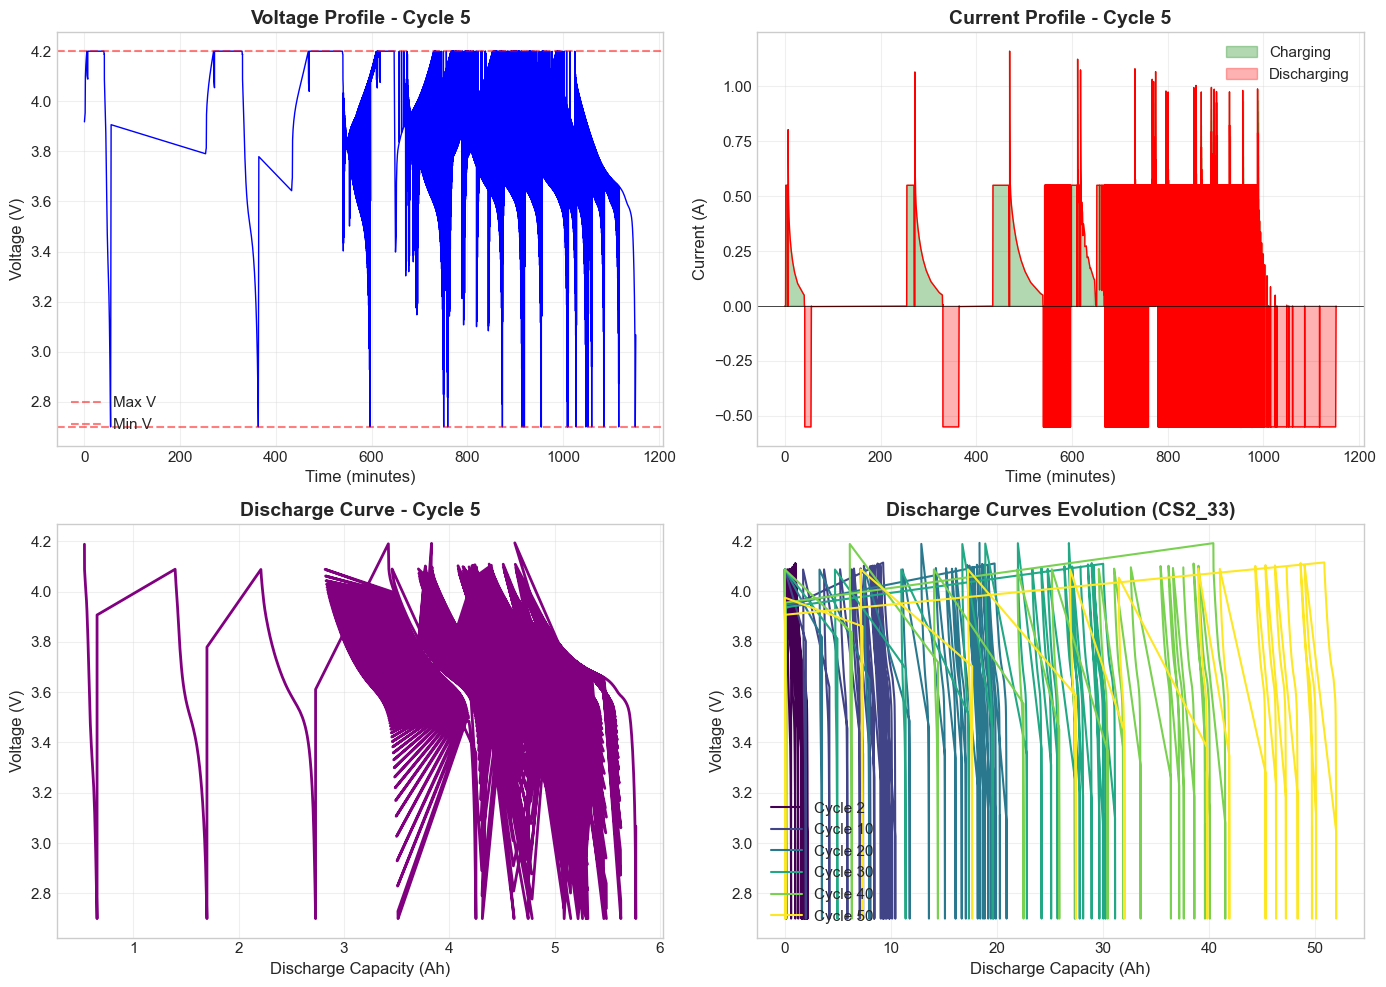

In [6]:
# TIME-SERIES VISUALIZATION
sample_cell_data = all_cells_data['CS2_33']
sample_cycle = 5

cycle_data = sample_cell_data[sample_cell_data['Cycle_Index'] == sample_cycle].copy()
cycle_data = cycle_data.sort_values('Test_Time(s)')
cycle_data['Time_min'] = (cycle_data['Test_Time(s)'] - cycle_data['Test_Time(s)'].min()) / 60

print(f"Visualizing Cycle {sample_cycle} from CS2_33")
print(f"Data points in cycle: {len(cycle_data):,}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Voltage profile
ax1 = axes[0, 0]
ax1.plot(cycle_data['Time_min'], cycle_data['Voltage(V)'], 'b-', linewidth=1)
ax1.set_xlabel('Time (minutes)')
ax1.set_ylabel('Voltage (V)')
ax1.set_title(f'Voltage Profile - Cycle {sample_cycle}', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=4.2, color='red', linestyle='--', alpha=0.5, label='Max V')
ax1.axhline(y=2.7, color='red', linestyle='--', alpha=0.5, label='Min V')
ax1.legend()

# Current profile with charge/discharge highlighting
ax2 = axes[0, 1]
ax2.plot(cycle_data['Time_min'], cycle_data['Current(A)'], 'r-', linewidth=1)
ax2.set_xlabel('Time (minutes)')
ax2.set_ylabel('Current (A)')
ax2.set_title(f'Current Profile - Cycle {sample_cycle}', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.fill_between(cycle_data['Time_min'], cycle_data['Current(A)'], 0, 
                  where=cycle_data['Current(A)'] > 0, alpha=0.3, color='green', label='Charging')
ax2.fill_between(cycle_data['Time_min'], cycle_data['Current(A)'], 0, 
                  where=cycle_data['Current(A)'] < 0, alpha=0.3, color='red', label='Discharging')
ax2.legend()

# Single cycle discharge curve
ax3 = axes[1, 0]
discharge_data = cycle_data[cycle_data['Current(A)'] < 0]
if len(discharge_data) > 0:
    ax3.plot(discharge_data['Discharge_Capacity(Ah)'], discharge_data['Voltage(V)'], 
             'purple', linewidth=2)
ax3.set_xlabel('Discharge Capacity (Ah)')
ax3.set_ylabel('Voltage (V)')
ax3.set_title(f'Discharge Curve - Cycle {sample_cycle}', fontweight='bold')
ax3.grid(True, alpha=0.3)

# Discharge curve evolution across cycles
ax4 = axes[1, 1]
cycles_to_plot = [2, 10, 20, 30, 40, 50]
colors_cycle = plt.cm.viridis(np.linspace(0, 1, len(cycles_to_plot)))

for idx, cyc in enumerate(cycles_to_plot):
    cyc_data = sample_cell_data[sample_cell_data['Cycle_Index'] == cyc]
    discharge = cyc_data[cyc_data['Current(A)'] < 0]
    if len(discharge) > 0:
        cap = discharge['Discharge_Capacity(Ah)'].values
        volt = discharge['Voltage(V)'].values
        cap_norm = cap - cap.min() if len(cap) > 0 else cap
        ax4.plot(cap_norm, volt, color=colors_cycle[idx], linewidth=1.5, label=f'Cycle {cyc}')

ax4.set_xlabel('Discharge Capacity (Ah)')
ax4.set_ylabel('Voltage (V)')
ax4.set_title('Discharge Curves Evolution (CS2_33)', fontweight='bold')
ax4.legend(loc='lower left')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Exploratory Data Analysis — Box Plots by Protocol

### Purpose
Compare voltage and current distributions across different cycling protocols to identify systematic differences and potential data quality issues.

### Analysis Overview
Four-panel visualization:
1. **Voltage by protocol** — Distribution comparison across all 6 protocols
2. **Current by protocol** — Current distribution patterns
3. **Voltage by cell** — 0.5C vs 1C cell-level comparison (8 cells)
4. **Outlier analysis** — Percentage of voltage outliers per protocol

### Key Observations

**Voltage Distribution by Protocol (Top-Left):**

| Protocol | Median (V) | IQR (V) | Notable Outliers |
|----------|------------|---------|------------------|
| 0.5C Constant | ~3.9 | ~3.7–4.1 | Single outlier ~3.0V |
| 1C Constant | ~4.0 | ~3.8–4.1 | Minimal |
| Variable (0.11-2.2A) | ~3.9 | ~3.6–4.1 | ~5.0V, ~2.0V, ~0.3V |
| Random Cutoff | ~4.0 | ~3.8–4.2 | ~0.3V |
| Partial (Low SOC) | ~3.65 | **Narrow: ~3.5–3.8** | Cluster at ~1.5–3.1V, extreme at ~−2.5V |
| Partial (High SOC) | ~4.1 | ~3.9–4.2 | ~5.2V, ~0.3V |

- **Partial (Low SOC)** has the **narrowest IQR** (limited voltage window by design) but **most outliers**
- Extreme outliers down to **−2.5V** (Partial Low SOC) and up to **~5.2V** are measurement artifacts

**Current Distribution by Protocol (Top-Right):**

| Protocol | Median (A) | IQR (A) | Notable Outliers |
|----------|------------|---------|------------------|
| 0.5C Constant | ~0 | ~−0.5 to +0.5 | None |
| 1C Constant | ~0 | ~−0.7 to +0.5 (wider) | None |
| Variable (0.11-2.2A) | ~0 | **Narrow: ~−0.2 to +0.4** | **+5.2A**, cluster at −1.5 to −2.2A, **−5.8A** |
| Random Cutoff | ~0 | ~−0.3 to +0.3 | **−5.8A** |
| Partial (Low SOC) | ~0 | ~−0.3 to +0.3 | +1.1A |
| Partial (High SOC) | ~0 | ~−0.3 to +0.4 | None |

- **0.5C and 1C** protocols have the **widest IQR** (consistent cycling at defined C-rates)
- **Variable protocol** has narrow IQR but extreme outliers (±5–6A) reflecting its variable current design
- Most extreme outliers: **+5.2A** (Variable) and **−5.8A** (Variable, Random Cutoff)

**Voltage by Cell — 0.5C vs 1C (Bottom-Left):**

| Cell | Protocol | Format | Median (V) | IQR (V) | Lower Extension |
|------|----------|--------|------------|---------|-----------------|
| CS2_33 | 0.5C (Blue) | xlsx | ~3.9 | ~3.75–4.0 | Isolated outlier ~3.2V |
| CS2_34 | 0.5C (Blue) | xlsx | ~3.9 | ~3.75–4.0 | Isolated outlier ~3.1V |
| CS2_8 | 0.5C (Blue) | txt | ~3.9 | ~3.7–4.2 (wider) | **Dense bar to ~2.85V** |
| CS2_21 | 0.5C (Blue) | txt | ~4.0 | ~3.7–4.15 (wider) | **Dense bar to ~2.75V**, outlier ~2.7V |
| CS2_35 | 1C (Red) | xlsx | ~3.9 | ~3.85–4.05 | Dense bar to ~3.15V |
| CS2_36 | 1C (Red) | xlsx | ~3.9 | ~3.85–4.0 | Dense bar to ~3.1V |
| CS2_37 | 1C (Red) | xlsx | ~3.95 | ~3.85–4.0 | Dense bar to ~3.15V |
| CS2_38 | 1C (Red) | xlsx | ~3.95 | ~3.85–4.05 | Dense bar to ~3.15V |

- **txt cells (CS2_8, CS2_21)** show **wider IQR** and **lower voltage extensions** (~2.75–2.85V)
- **xlsx cells (CS2_33, CS2_34)** have **isolated outliers** rather than dense low-voltage bars
- **1C cells** are highly **consistent** with each other — similar medians (~3.9–3.95V) and narrow IQR

**Voltage Outliers by Protocol (Bottom-Right):**

| Protocol | Outlier % | Interpretation |
|----------|-----------|----------------|
| 0.5C Constant | 0.9% | Very clean |
| 1C Constant | 1.5% | Normal |
| Variable | 1.8% | Normal |
| Random Cutoff | 0.2% | Very clean (fewest outliers) |
| **Partial (Low SOC)** | **6.9%** | Highest — ~7× higher than most protocols |
| Partial (High SOC) | 0.3% | Very clean |

### Physical Interpretation

1. **Partial (Low SOC) outliers:** The 6.9% outlier rate is not a data quality issue — these cells operate in a narrow, lower voltage range (~3.3–3.8V) where IQR-based outlier detection captures normal voltage transitions during charge/discharge. The clustered outliers (~1.5–3.1V) represent expected low-voltage operation.

2. **txt vs xlsx cell differences:** The wider voltage distributions in CS2_8 and CS2_21 (txt format) suggest potential differences in data recording or processing compared to xlsx cells. This supports excluding txt cells from ML analysis.

3. **1C cell consistency:** All four 1C cells (CS2_35–38) show remarkably similar distributions, indicating consistent experimental conditions and good data quality for ML modeling.

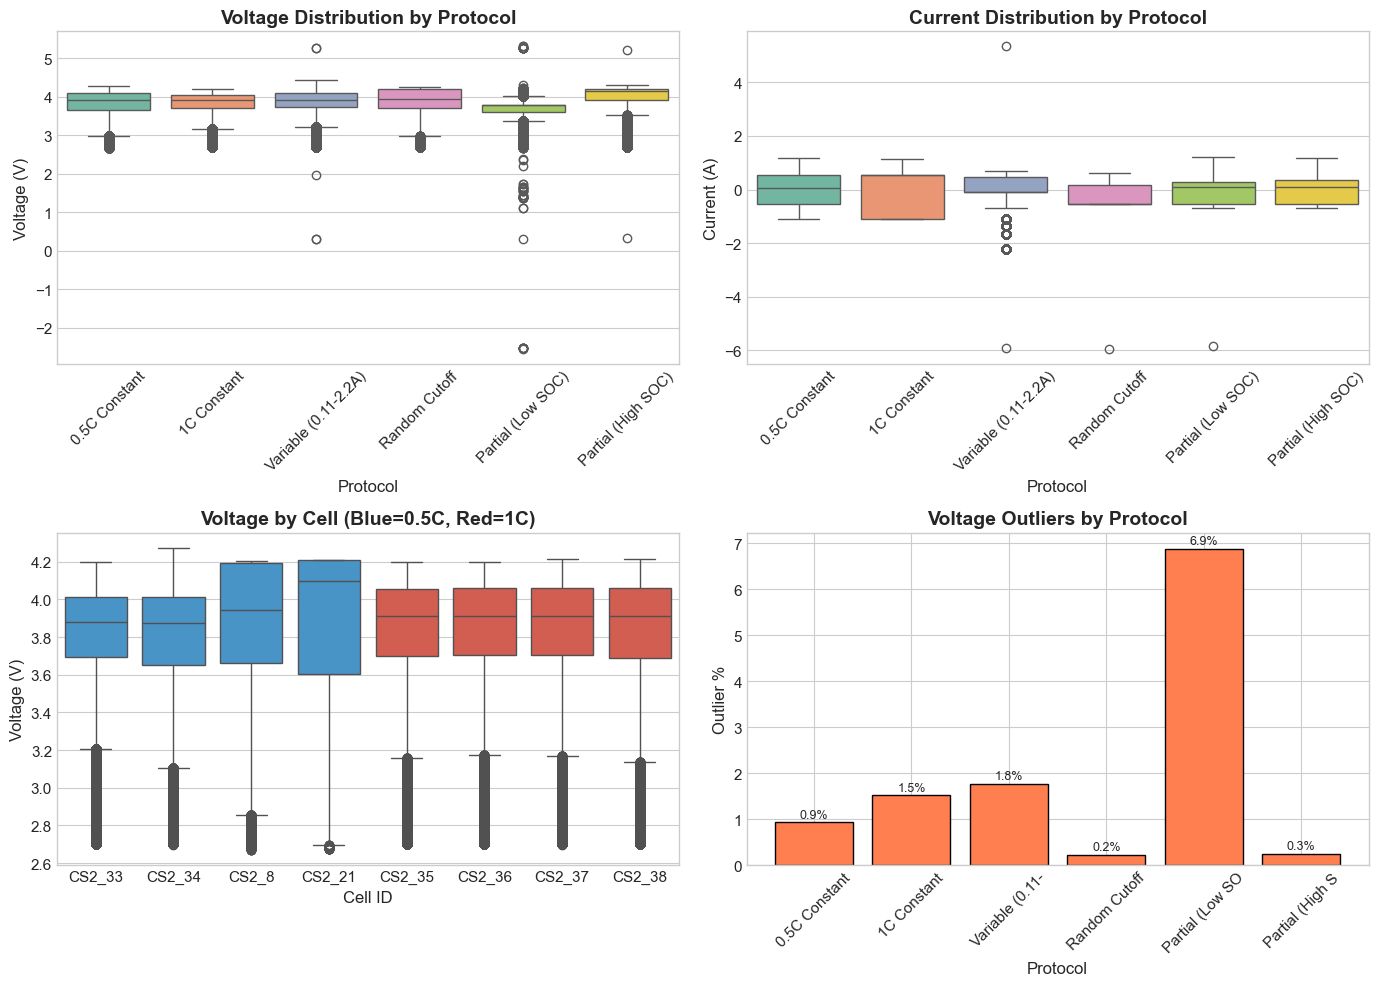

In [7]:
all_data_labeled = []
for cell_name, cell_data in all_cells_data.items():
    temp_df = cell_data.copy()
    temp_df['Cell_ID'] = cell_name
    temp_df['Protocol'] = CELL_INFO[cell_name]['protocol']
    all_data_labeled.append(temp_df)

all_data_labeled = pd.concat(all_data_labeled, ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
protocol_order = ['0.5C Constant', '1C Constant', 'Variable (0.11-2.2A)', 
                  'Random Cutoff', 'Partial (Low SOC)', 'Partial (High SOC)']
protocol_order = [p for p in protocol_order if p in all_data_labeled['Protocol'].unique()]

sns.boxplot(data=all_data_labeled, x='Protocol', y='Voltage(V)', ax=ax1, 
            order=protocol_order, palette='Set2')
ax1.set_xlabel('Protocol')
ax1.set_ylabel('Voltage (V)')
ax1.set_title('Voltage Distribution by Protocol', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

ax2 = axes[0, 1]
sns.boxplot(data=all_data_labeled, x='Protocol', y='Current(A)', ax=ax2,
            order=protocol_order, palette='Set2')
ax2.set_xlabel('Protocol')
ax2.set_ylabel('Current (A)')
ax2.set_title('Current Distribution by Protocol', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

ax3 = axes[1, 0]
type12_cells = ['CS2_33', 'CS2_34', 'CS2_8', 'CS2_21', 'CS2_35', 'CS2_36', 'CS2_37', 'CS2_38']
type12_data = all_data_labeled[all_data_labeled['Cell_ID'].isin(type12_cells)]

colors_cell = {'CS2_33': '#3498db', 'CS2_34': '#3498db', 'CS2_8': '#3498db', 'CS2_21': '#3498db',
               'CS2_35': '#e74c3c', 'CS2_36': '#e74c3c', 'CS2_37': '#e74c3c', 'CS2_38': '#e74c3c'}

sns.boxplot(data=type12_data, x='Cell_ID', y='Voltage(V)', ax=ax3, 
            order=type12_cells, palette=colors_cell)
ax3.set_xlabel('Cell ID')
ax3.set_ylabel('Voltage (V)')
ax3.set_title('Voltage by Cell (Blue=0.5C, Red=1C)', fontweight='bold')

ax4 = axes[1, 1]
outlier_data = []
for proto in protocol_order:
    proto_volt = all_data_labeled[all_data_labeled['Protocol'] == proto]['Voltage(V)']
    Q1, Q3 = proto_volt.quantile(0.25), proto_volt.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((proto_volt < Q1 - 1.5*IQR) | (proto_volt > Q3 + 1.5*IQR)).sum()
    outlier_pct = outliers / len(proto_volt) * 100
    outlier_data.append({'Protocol': proto[:15], 'Outlier_Pct': outlier_pct})

outlier_df = pd.DataFrame(outlier_data)
bars = ax4.bar(outlier_df['Protocol'], outlier_df['Outlier_Pct'], color='coral', edgecolor='black')
ax4.set_xlabel('Protocol')
ax4.set_ylabel('Outlier %')
ax4.set_title('Voltage Outliers by Protocol', fontweight='bold')
ax4.tick_params(axis='x', rotation=45)

for bar, val in zip(bars, outlier_df['Outlier_Pct']):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Exploratory Data Analysis — Pairplot Analysis

### Purpose
Visualize pairwise relationships between key features using a scatter matrix to identify patterns, clusters, and potential non-linear relationships.

### Method
- Random sample of **5,000 rows** from 9.1M total (for computational efficiency)
- 3×3 matrix: Voltage, Current, Discharge Capacity
- Diagonal: Histograms (univariate distributions)
- Off-diagonal: Scatter plots (bivariate relationships)

### Key Observations

**Diagonal — Histograms:**

| Feature | Distribution Shape | Key Characteristics |
|---------|-------------------|---------------------|
| Voltage (V) | Multi-modal | Highest peak at **~4.2V** (~1050 count), secondary peaks at ~3.7V, ~3.85V, ~3.95V |
| Current (A) | Multi-modal | Highest at **+0.5A** (~1200), secondary at **−0.5A** (~600), peaks at 0A (~400) and −1.0A (~380) |
| Discharge Capacity (Ah) | Right-skewed | Highest at **0–5 Ah** (~900+ count), gradual decline to ~55 Ah |

**Off-Diagonal — Scatter Plots:**

| Relationship | Pattern | Interpretation |
|--------------|---------|----------------|
| **Voltage vs Current** | **Grid-like pattern** | Horizontal bands at discrete voltages (~4.2V, ~3.9V, ~3.7V, ~3.2V) intersect with vertical bands at discrete currents (~−1.1A, ~−0.5A, 0A, +0.5A); dense rectangular cluster at 3.7–4.2V × −0.5A to +0.5A |
| **Voltage vs Capacity** | Horizontal bands | Dense band at **~4.2V** across all capacity values; additional bands at ~3.9V, ~3.7V, ~3.2V; reflects voltage cycling while capacity accumulates monotonically |
| **Current vs Capacity** | Horizontal bands | Discrete current levels (~+0.5A, 0A, −0.5A, −1.0A, −1.5A, −2.0A) visible as horizontal striations; most data concentrated at low capacity (0–20 Ah) and standard currents (±0.5A) |

### Physical Interpretation

1. **Discrete current bands:** The horizontal striations in Current plots reveal the **controlled nature** of cycling tests — current is set to specific C-rate values (0.5C ≈ ±0.55A, 1C ≈ ±1.1A, rest = 0A) rather than varying continuously.

2. **Voltage-Current grid pattern:** The grid-like structure shows that voltage and current operate semi-independently — at each controlled current level, voltage spans the operating range (2.7V–4.2V) as the battery charges and discharges. The dense cluster at high voltage and moderate current reflects time spent in CV charging phase.

3. **Capacity independence:** Neither voltage nor current correlates strongly with cumulative discharge capacity — this is expected since capacity is a running total (increases monotonically), while V and I reflect instantaneous electrochemical state that repeats each cycle.

4. **4.2V concentration:** The dominant peak at 4.2V in voltage distribution and the dense horizontal band in Voltage vs Capacity reflect the CV (constant voltage) charging phase where the battery dwells at upper voltage limit.

### Note on Sampling
Using 5,000 samples (0.05% of data) provides representative patterns while enabling fast visualization. The discrete bands confirm data integrity — random noise would blur these grid-like structures.

Using 5,000 sampled rows for pairplot


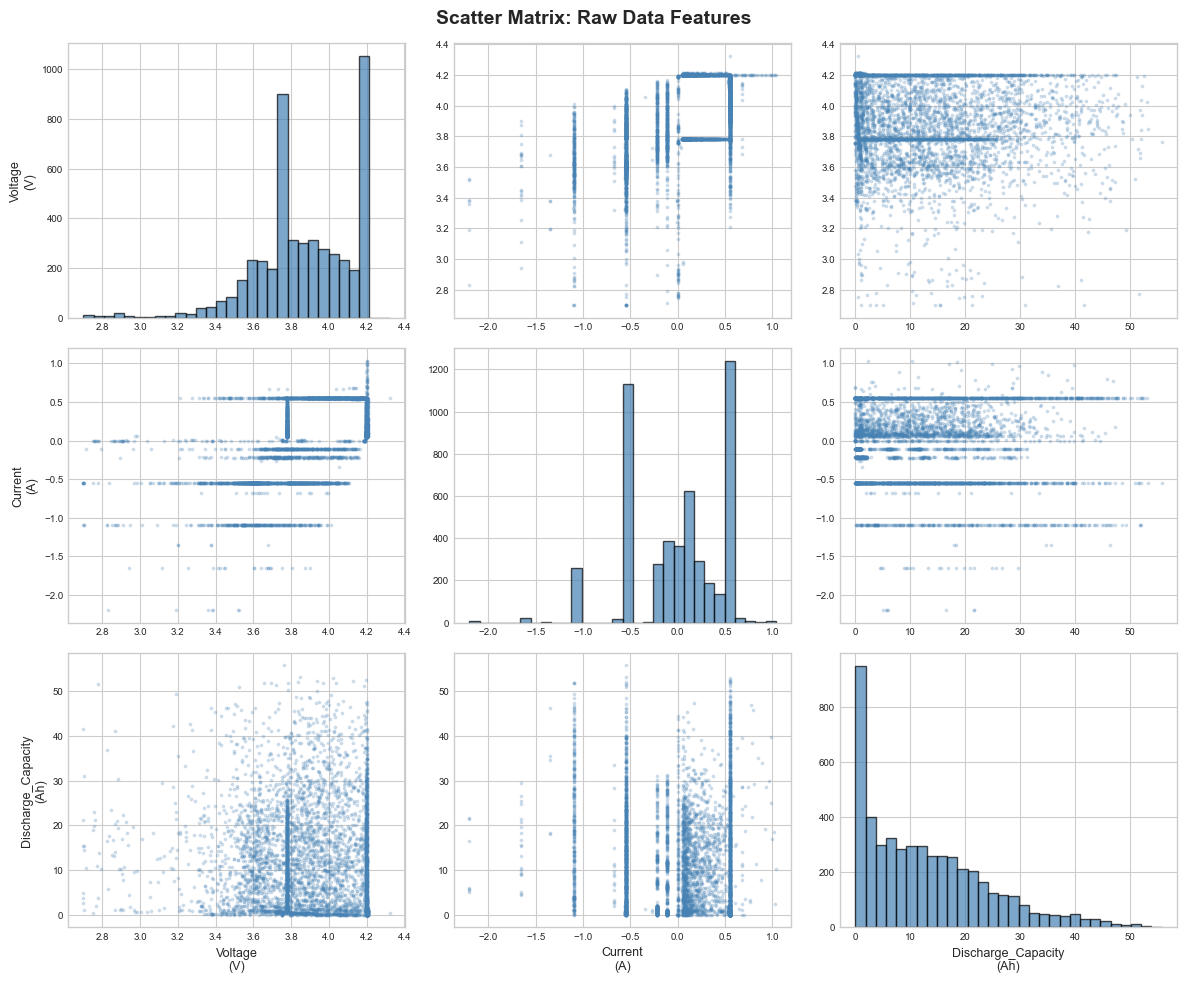

In [8]:
# PAIRPLOT ANALYSIS
sample_size = 5000
pairplot_sample = all_data_combined.sample(n=min(sample_size, len(all_data_combined)), random_state=42)

print(f"Using {len(pairplot_sample):,} sampled rows for pairplot")

features = ['Voltage(V)', 'Current(A)', 'Discharge_Capacity(Ah)']
features = [f for f in features if f in pairplot_sample.columns]

fig, axes = plt.subplots(len(features), len(features), figsize=(12, 10))

for i, feat1 in enumerate(features):
    for j, feat2 in enumerate(features):
        ax = axes[i, j]
        
        # Diagonal: histograms
        if i == j:
            ax.hist(pairplot_sample[feat1].dropna(), bins=30, color='steelblue', 
                   edgecolor='black', alpha=0.7)
        # Off-diagonal: scatter plots
        else:
            ax.scatter(pairplot_sample[feat2], pairplot_sample[feat1], 
                      alpha=0.2, s=3, c='steelblue')
        
        if j == 0:
            ax.set_ylabel(feat1.replace('(', '\n('), fontsize=9)
        if i == len(features) - 1:
            ax.set_xlabel(feat2.replace('(', '\n('), fontsize=9)
        
        ax.tick_params(labelsize=7)

plt.suptitle('Scatter Matrix: Raw Data Features', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('eda_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Cycle-Level Feature Extraction

### Purpose
Transform raw time-series data (9.1M rows) into cycle-level summaries (1,492 rows) for machine learning. The critical challenge: raw data contains **cumulative** capacity, but we need **per-cycle** capacity.

### The Problem: Cumulative vs Per-Cycle

| Cycle | Cumulative Discharge (Ah) | Per-Cycle (What We Need) |
|-------|---------------------------|--------------------------|
| 1 | 1.16 | 1.16 Ah |
| 2 | 2.31 | 1.15 Ah (2.31 - 1.16) |
| 3 | 3.47 | 1.16 Ah (3.47 - 2.31) |
| ... | ... | ... |
| 50 | 57.5 | 1.12 Ah |

### Method: Finite Differencing

$$Q_{\text{cycle } n} = Q_{\text{cumulative}}(n) - Q_{\text{cumulative}}(n-1)$$

For xlsx files, compute the difference between consecutive cumulative maximum values. For txt files (CS2_8, CS2_21), capacity resets each cycle — if the differenced result is ≤ 0, the raw cumulative value is used directly.

### Features Extracted Per Cycle

| Feature | Unit | Description |
|---------|------|-------------|
| `Discharge_Capacity_Ah` | Ah | Capacity delivered (primary health indicator) |
| `Charge_Capacity_Ah` | Ah | Capacity accepted during charge |
| `Discharge_Energy_Wh` | Wh | Energy delivered during discharge |
| `Charge_Energy_Wh` | Wh | Energy accepted during charge |
| `Coulombic_Efficiency` | % | Discharge/Charge capacity ratio (side reaction indicator) |
| `Energy_Efficiency` | % | Discharge/Charge energy ratio (resistance indicator) |
| `Internal_Resistance_Ohm` | Ω | Mean DC internal resistance (from values > 0) |
| `V_min` | V | Minimum voltage in cycle |
| `V_max` | V | Maximum voltage in cycle |

### Output

**Cycles Extracted Per Cell:**

| Cell | Protocol | Format | Cycles |
|------|----------|--------|--------|
| CS2_33 | 0.5C Constant | xlsx | 50 |
| CS2_34 | 0.5C Constant | xlsx | 50 |
| CS2_35 | 1C Constant | xlsx | 50 |
| CS2_36 | 1C Constant | xlsx | 50 |
| CS2_37 | 1C Constant | xlsx | 50 |
| CS2_38 | 1C Constant | xlsx | 50 |
| CS2_3 | Variable (0.11-2.2A) | xlsx | 695 |
| CS2_9 | Variable (0.11-2.2A) | xlsx | 10 |
| CS2_7 | Random Cutoff | xlsx | 32 |
| CS2_5 | Partial (Low SOC) | xlsx | 100 |
| CS2_6 | Partial (Low SOC) | xlsx | 100 |
| CS2_24 | Partial (High SOC) | xlsx | 100 |
| CS2_25 | Partial (High SOC) | xlsx | 100 |
| CS2_8 | 0.5C Constant | txt | 34 |
| CS2_21 | 0.5C Constant | txt | 21 |

**Total: 1,492 valid cycle records**

**Capacity Statistics Across All Cells:**

| Statistic | Value |
|-----------|-------|
| Mean | 5.3258 Ah |
| Std | 11.6339 Ah |
| Min | 0.0080 Ah |
| Max | 48.8814 Ah |

High variance (std = 11.63 Ah) reflects different protocols — Variable protocol (CS2_3) accumulates large per-cycle capacity over 695 cycles, while Partial protocols show lower values due to limited SOC windows.

### Data Reduction
**9,102,845 rows → 1,492 rows** (6,101× compression)

In [9]:
# Extract per-cycle capacity from cumulative data using finite differencing.
def extract_cycle_summary_fixed(df, cell_name):
   
    cycles = sorted(df['Cycle_Index'].unique())
    cycle_data = []
    
    prev_discharge = 0
    prev_charge = 0
    prev_discharge_energy = 0
    prev_charge_energy = 0
    
    for cycle in cycles:
        cycle_df = df[df['Cycle_Index'] == cycle]
        
        cum_discharge = cycle_df['Discharge_Capacity(Ah)'].max()
        cum_charge = cycle_df['Charge_Capacity(Ah)'].max()
        cum_discharge_energy = cycle_df['Discharge_Energy(Wh)'].max()
        cum_charge_energy = cycle_df['Charge_Energy(Wh)'].max()
        
        discharge_cap = cum_discharge - prev_discharge
        charge_cap = cum_charge - prev_charge
        discharge_energy = cum_discharge_energy - prev_discharge_energy
        charge_energy = cum_charge_energy - prev_charge_energy
        
        # Handle txt files where capacity resets each cycle
        if discharge_cap <= 0 or charge_cap <= 0:
            discharge_cap = cum_discharge
            charge_cap = cum_charge
            discharge_energy = cum_discharge_energy
            charge_energy = cum_charge_energy
        
        prev_discharge = cum_discharge
        prev_charge = cum_charge
        prev_discharge_energy = cum_discharge_energy
        prev_charge_energy = cum_charge_energy
        
        ir_values = cycle_df[cycle_df['Internal_Resistance(Ohm)'] > 0]['Internal_Resistance(Ohm)']
        ir_mean = ir_values.mean() if len(ir_values) > 0 else np.nan
        
        v_min = cycle_df['Voltage(V)'].min()
        v_max = cycle_df['Voltage(V)'].max()
        
        if discharge_cap <= 0 or charge_cap <= 0:
            continue
        
        cycle_data.append({
            'Cell_ID': cell_name,
            'Cycle': cycle,
            'Discharge_Capacity_Ah': discharge_cap,
            'Charge_Capacity_Ah': charge_cap,
            'Discharge_Energy_Wh': discharge_energy,
            'Charge_Energy_Wh': charge_energy,
            'Coulombic_Efficiency': (discharge_cap / charge_cap * 100) if charge_cap > 0 else np.nan,
            'Energy_Efficiency': (discharge_energy / charge_energy * 100) if charge_energy > 0 else np.nan,
            'Internal_Resistance_Ohm': ir_mean,
            'V_min': v_min,
            'V_max': v_max,
        })
    
    return pd.DataFrame(cycle_data)

all_cycle_summaries = []

for cell_name, df in all_cells_data.items():
    cycle_summary = extract_cycle_summary_fixed(df, cell_name)
    all_cycle_summaries.append(cycle_summary)
    print(f"  {cell_name}: {len(cycle_summary)} cycles")

cycle_df = pd.concat(all_cycle_summaries, ignore_index=True)

cycle_df['Type'] = cycle_df['Cell_ID'].map(lambda x: CELL_INFO[x]['type'])
cycle_df['Protocol'] = cycle_df['Cell_ID'].map(lambda x: CELL_INFO[x]['protocol'])

print(f"\nTotal: {len(cycle_df):,} valid cycle records")
print(f"\nCapacity Statistics:")
print(f"  Mean: {cycle_df['Discharge_Capacity_Ah'].mean():.4f} Ah")
print(f"  Std:  {cycle_df['Discharge_Capacity_Ah'].std():.4f} Ah")
print(f"  Min:  {cycle_df['Discharge_Capacity_Ah'].min():.4f} Ah")
print(f"  Max:  {cycle_df['Discharge_Capacity_Ah'].max():.4f} Ah")

  CS2_33: 50 cycles
  CS2_34: 50 cycles
  CS2_35: 50 cycles
  CS2_36: 50 cycles
  CS2_37: 50 cycles
  CS2_38: 50 cycles
  CS2_3: 695 cycles
  CS2_9: 10 cycles
  CS2_7: 32 cycles
  CS2_5: 100 cycles
  CS2_6: 100 cycles
  CS2_24: 100 cycles
  CS2_25: 100 cycles
  CS2_8: 34 cycles
  CS2_21: 21 cycles

Total: 1,492 valid cycle records

Capacity Statistics:
  Mean: 5.3258 Ah
  Std:  11.6339 Ah
  Min:  0.0080 Ah
  Max:  48.8814 Ah


## 10. Cycle-Level Exploratory Data Analysis

### Purpose
Analyze the extracted cycle-level data (1,492 records) to understand capacity distributions, efficiency patterns, and feature correlations across protocols and cells.

### Descriptive Statistics (All 1,492 Cycles)

| Statistic | Cycle | Discharge_Capacity_Ah | Charge_Capacity_Ah | Discharge_Energy_Wh | Charge_Energy_Wh | Internal_Resistance_Ohm | V_min | V_max |
|-----------|-------|----------------------|-------------------|--------------------|-----------------|-----------------------|-------|-------|
| count | 1492 | 1492 | 1492 | 1492 | 1492 | **720** | 1492 | 1492 |
| mean | 181.75 | 5.3258 | 5.3379 | 18.3852 | 22.1336 | 0.1039 | 2.9862 | 4.1249 |
| std | 207.99 | 11.6339 | 11.6641 | 39.8717 | 48.5698 | 0.0232 | 0.4905 | 0.1624 |
| min | 1 | 0.0080 | 0.0000 | 0.0283 | 0.0000 | 0.0793 | **-2.5440** | 3.7800 |
| 25% | 27 | 0.2426 | 0.2424 | 0.8662 | 0.9047 | 0.0911 | 2.6994 | 4.0788 |
| 50% | 70 | 0.4131 | 0.4045 | 1.5975 | 1.6658 | 0.0978 | 2.6999 | 4.2001 |
| 75% | 322.25 | 1.1239 | 1.1273 | 4.2013 | 4.4849 | 0.1074 | 3.3445 | 4.2007 |
| max | 695 | 48.8814 | 49.0650 | 168.6115 | 204.5268 | 0.2723 | 3.7799 | 5.3099 |

**Notes:**
- **Internal_Resistance_Ohm** has only **720** valid values (48% of cycles) — not all cycles include IR measurements
- **V_min** has minimum of **-2.5440V** (measurement artifact)
- **Coulombic/Energy Efficiency** have extreme max values (~10^12) — calculation artifacts from division issues; filtered in visualization

### Key Observations from Plots

**Capacity Distribution by Protocol (Top-Left Histogram):**

| Protocol | N_Cycles | Mean_Cap (Ah) | Std_Cap (Ah) | Min_Cap (Ah) | Max_Cap (Ah) |
|----------|----------|---------------|--------------|--------------|--------------|
| 0.5C Constant | 155 | 0.8339 | 0.4287 | 0.0194 | 1.1881 |
| 1C Constant | 200 | 1.0923 | **0.0239** | 0.9992 | 1.1448 |
| Partial (High SOC) | 200 | 0.4155 | 0.1117 | 0.3622 | 1.5329 |
| Partial (Low SOC) | 200 | 0.2695 | 0.1208 | 0.2413 | 1.5129 |
| Random Cutoff | 32 | 1.5967 | 3.0784 | 0.1708 | 18.3082 |
| **Variable (0.11-2.2A)** | **705** | **10.5110** | **15.3292** | 0.0080 | **48.8814** |

- **Variable protocol (pink)** dominates histogram with **~420 counts** at 0–2 Ah range, plus scattered bars across 5–50 Ah
- **Random Cutoff (green)** visible as small bar (~15–20 frequency) at low capacity
- **0.5C, 1C, and Partial protocols** are hidden behind the dominant Variable bar
- **1C Constant** has lowest std (0.0239 Ah) — most consistent per-cycle capacity

**Coulombic Efficiency Distribution (Top-Right Histogram):**

| Efficiency Range (%) | Frequency |
|---------------------|-----------|
| ~98–99 | ~105 |
| **~99–100** | **~435** (highest) |
| ~100–101 | ~205 |
| ~101–102 | ~155 |
| ~105–110 | ~15–25 (scattered) |

- Distribution centered **slightly left of 100%** — peak at ~99–100%
- Most values in **98–102%** range — healthy cells with minimal side reactions
- Scattered values at 105–110% are measurement artifacts
- Red dashed line marks 100% (ideal) reference

**Capacity Distribution by Cell (Bottom-Left Boxplot, sorted by mean descending):**

| Cell | Protocol | Median (Ah) | Notes |
|------|----------|-------------|-------|
| **CS2_3** | Variable | ~5–10 | Largest range; whisker to ~48 Ah; outliers at ~16, ~32 Ah |
| **CS2_9** | Variable | ~5–6 | Box ~3–7 Ah; outliers at ~16, ~18 Ah |
| CS2_7 | Random Cutoff | ~1 | Narrow box; outliers at ~2.5, ~18–19 Ah |
| CS2_33, CS2_34 | 0.5C (xlsx) | ~1 | Consistent ~1 Ah per cycle |
| CS2_36, CS2_38, CS2_37, CS2_35 | 1C | ~1 | Very consistent ~1 Ah per cycle |
| CS2_25, CS2_24 | Partial (High SOC) | ~0.4 | Limited SOC window |
| CS2_8 | 0.5C (txt) | ~0.5 | Lower than xlsx 0.5C cells |
| CS2_6, CS2_5 | Partial (Low SOC) | ~0.25–0.3 | Lowest capacity window |
| **CS2_21** | 0.5C (txt) | ~0.1 | Smallest — potential data issue |

**Cycle Feature Correlations (Bottom-Right Heatmap):**

| Feature Pair | Correlation | Interpretation |
|--------------|-------------|----------------|
| Discharge ↔ Charge Capacity | **1.00** | Perfect correlation (charge in ≈ discharge out) |
| Cycle ↔ Discharge Capacity | **0.46** | Moderate positive — reflects cumulative structure in Variable protocol |
| Cycle ↔ Charge Capacity | **0.46** | Same as above |
| Cycle ↔ Coulombic Efficiency | 0.09 | Very weak — efficiency independent of cycle number |
| Coulombic Eff. ↔ Capacity | -0.04 | Near zero — efficiency stable regardless of capacity |

**Note on Correlation Sign:** The **+0.46** correlation between Cycle and Capacity is positive (not negative) because higher cycle numbers in the Variable protocol (CS2_3 with 695 cycles) correspond to larger per-cycle capacity values. This does not represent degradation — degradation analysis requires tracking capacity fade within individual cells over time, which will be addressed in subsequent analysis.

Cycle-Level Descriptive Statistics:
          Cycle  Discharge_Capacity_Ah  Charge_Capacity_Ah  Discharge_Energy_Wh  Charge_Energy_Wh  Coulombic_Efficiency  Energy_Efficiency  Internal_Resistance_Ohm      V_min      V_max
count  1492.000              1492.0000           1492.0000            1492.0000         1492.0000          1.492000e+03       1.492000e+03                 720.0000  1492.0000  1492.0000
mean    181.750                 5.3258              5.3379              18.3852           22.1336          8.050737e+09       7.343083e+09                   0.1039     2.9862     4.1249
std     207.987                11.6339             11.6641              39.8717           48.5698          8.715332e+10       7.951513e+10                   0.0232     0.4905     0.1624
min       1.000                 0.0080              0.0000               0.0283            0.0000          1.228800e+01       1.043660e+01                   0.0793    -2.5440     3.7800
25%      27.000                 0.

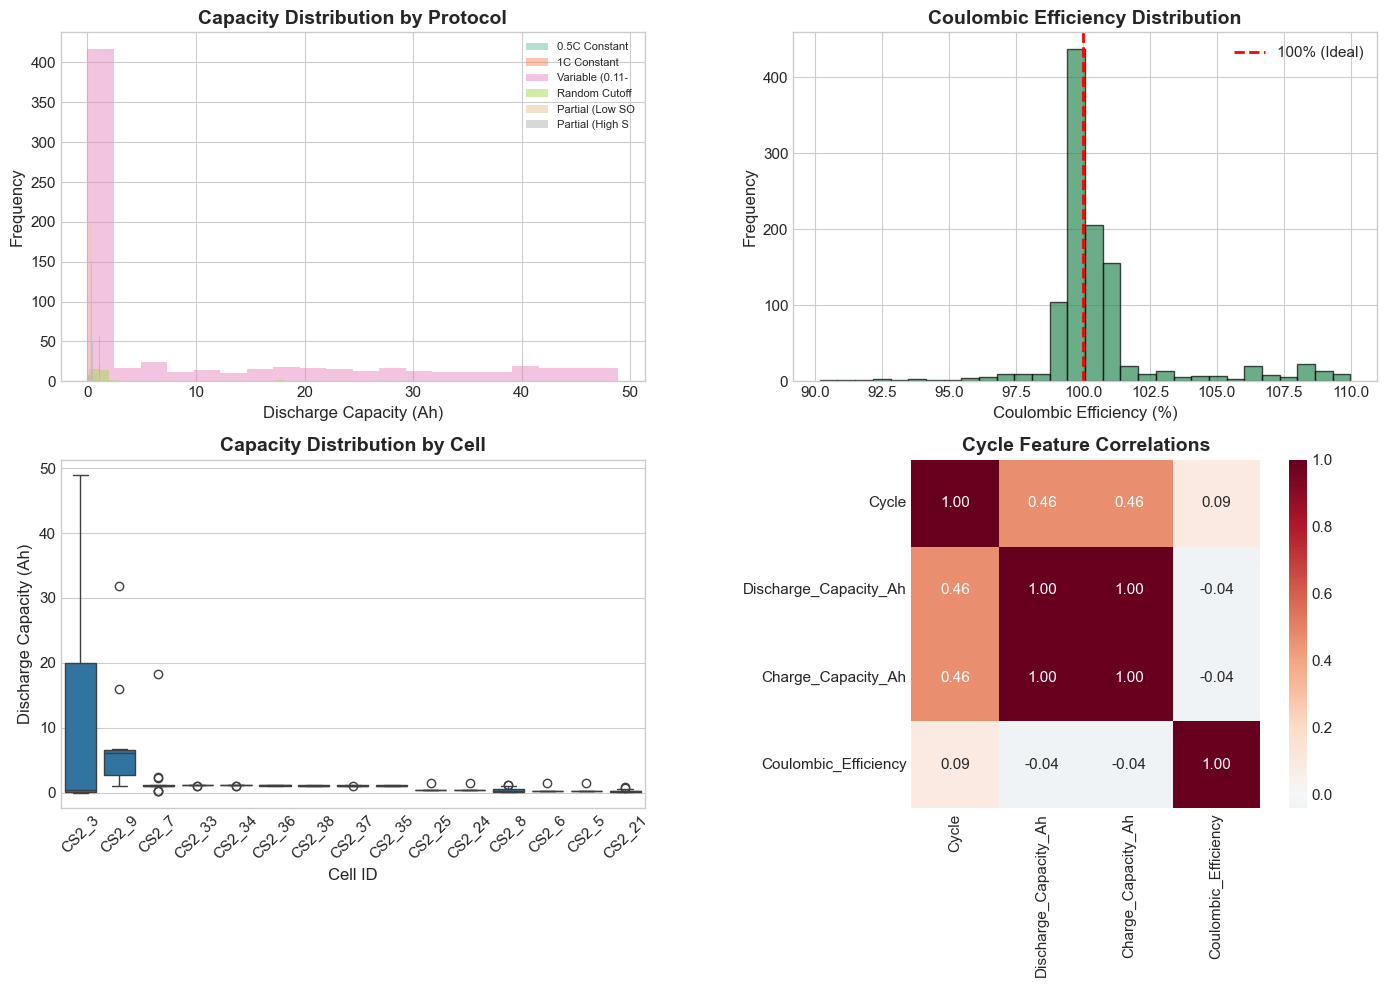


Summary by Protocol:
                      N_Cycles  Mean_Cap  Std_Cap  Min_Cap  Max_Cap
Protocol                                                           
0.5C Constant              155    0.8339   0.4287   0.0194   1.1881
1C Constant                200    1.0923   0.0239   0.9992   1.1448
Partial (High SOC)         200    0.4155   0.1117   0.3622   1.5329
Partial (Low SOC)          200    0.2695   0.1208   0.2413   1.5129
Random Cutoff               32    1.5967   3.0784   0.1708  18.3082
Variable (0.11-2.2A)       705   10.5110  15.3292   0.0080  48.8814


In [10]:
# CYCLE-LEVEL EDA
print("Cycle-Level Descriptive Statistics:")
print(cycle_df.describe().round(4).to_string())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Capacity distribution by protocol
ax1 = axes[0, 0]
protocols = cycle_df['Protocol'].unique()
colors_proto = plt.cm.Set2(np.linspace(0, 1, len(protocols)))

for idx, proto in enumerate(protocols):
    proto_data = cycle_df[cycle_df['Protocol'] == proto]['Discharge_Capacity_Ah']
    ax1.hist(proto_data, bins=20, alpha=0.5, label=proto[:15], color=colors_proto[idx])

ax1.set_xlabel('Discharge Capacity (Ah)')
ax1.set_ylabel('Frequency')
ax1.set_title('Capacity Distribution by Protocol', fontweight='bold')
ax1.legend(fontsize=8)

# Coulombic efficiency distribution
ax2 = axes[0, 1]
if 'Coulombic_Efficiency' in cycle_df.columns:
    ce_data = cycle_df['Coulombic_Efficiency'].dropna()
    ce_data_filtered = ce_data[(ce_data > 90) & (ce_data < 110)]  # Filter artifacts
    ax2.hist(ce_data_filtered, bins=30, color='seagreen', edgecolor='black', alpha=0.7)
    ax2.axvline(100, color='red', linestyle='--', linewidth=2, label='100% (Ideal)')
    ax2.set_xlabel('Coulombic Efficiency (%)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Coulombic Efficiency Distribution', fontweight='bold')
    ax2.legend()
else:
    ax2.text(0.5, 0.5, 'Coulombic Efficiency not available', ha='center', va='center', transform=ax2.transAxes)
    ax2.axis('off')

# Capacity by cell (sorted by mean)
ax3 = axes[1, 0]
cell_order = cycle_df.groupby('Cell_ID')['Discharge_Capacity_Ah'].mean().sort_values(ascending=False).index
sns.boxplot(data=cycle_df, x='Cell_ID', y='Discharge_Capacity_Ah', ax=ax3, order=cell_order)
ax3.set_xlabel('Cell ID')
ax3.set_ylabel('Discharge Capacity (Ah)')
ax3.set_title('Capacity Distribution by Cell', fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

# Feature correlations
ax4 = axes[1, 1]
cycle_numeric = cycle_df.select_dtypes(include=[np.number])
key_cols = ['Cycle', 'Discharge_Capacity_Ah', 'Charge_Capacity_Ah', 'Coulombic_Efficiency']
key_cols = [c for c in key_cols if c in cycle_numeric.columns]

if len(key_cols) >= 2:
    cycle_corr = cycle_numeric[key_cols].corr()
    sns.heatmap(cycle_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax4, square=True)
    ax4.set_title('Cycle Feature Correlations', fontweight='bold')
else:
    ax4.text(0.5, 0.5, 'Not enough features', ha='center', va='center', transform=ax4.transAxes)

plt.tight_layout()
plt.savefig('eda_cycle_level.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary by protocol
summary = cycle_df.groupby('Protocol').agg({
    'Discharge_Capacity_Ah': ['count', 'mean', 'std', 'min', 'max']
}).round(4)
summary.columns = ['N_Cycles', 'Mean_Cap', 'Std_Cap', 'Min_Cap', 'Max_Cap']

print("\nSummary by Protocol:")
print(summary.to_string())

## 11. Capacity Fade Visualization

### Purpose
Visualize battery degradation patterns across different cycling protocols to compare C-rate effects and SOC range effects on capacity fade.

### Four-Panel Analysis

| Panel | Content | Comparison |
|-------|---------|------------|
| Top-Left | 0.5C vs 1C raw capacity | C-rate effect on degradation |
| Top-Right | Partial cycling (Low vs High SOC) | SOC range effect |
| Bottom-Left | Normalized capacity (SOH) | Relative fade with EOL threshold |
| Bottom-Right | Box plot distribution | Statistical comparison |

### Key Observations

**Panel 1: Capacity Fade — 0.5C vs 1C Cycling (Top-Left)**

| Cell | Protocol | Format | Capacity Pattern (0–50 cycles) |
|------|----------|--------|-------------------------------|
| CS2_33 | 0.5C | xlsx | Stable ~1.13–1.15 Ah; single dip to ~0.97 Ah at cycle ~37 |
| CS2_34 | 0.5C | xlsx | Stable ~1.13–1.15 Ah throughout |
| **CS2_8** | 0.5C | txt | **Highly erratic** — oscillates between ~0.02 and ~1.15 Ah with wild spikes |
| **CS2_21** | 0.5C | txt | **Highly erratic** — low values ~0.02–0.20 Ah; ends at cycle ~21 |
| CS2_35 | 1C | xlsx | Stable ~1.10–1.13 Ah |
| CS2_36 | 1C | xlsx | Stable ~1.10–1.13 Ah |
| CS2_37 | 1C | xlsx | Slightly lower ~1.00–1.05 Ah; dip to ~1.0 Ah at cycle ~10 |
| CS2_38 | 1C | xlsx | Stable ~1.10–1.15 Ah |

- **Key observation:** The txt format cells (CS2_8, CS2_21) show severely erratic, unreliable behavior while all xlsx cells show stable, consistent capacity.

**Panel 2: Partial Cycling — Low vs High SOC Range (Top-Right)**

| Cell | Protocol | Color | Cycle 1 | Cycles 2–100 |
|------|----------|-------|---------|--------------|
| CS2_24 | High SOC | Purple | **~1.53 Ah** (spike) | Stable ~0.40–0.45 Ah, slight decline to ~0.38 Ah |
| CS2_25 | High SOC | Purple | **~1.42 Ah** (spike) | Stable ~0.38–0.42 Ah |
| CS2_5 | Low SOC | Green | ~0.26 Ah | Stable ~0.25–0.27 Ah |
| CS2_6 | Low SOC | Green | ~0.26 Ah | Stable ~0.25–0.27 Ah (overlapping with CS2_5) |

- **Initial spikes** at cycle 1 occur in **High SOC cells** (likely characterization/formation cycle)
- **High SOC** delivers more capacity per cycle (~0.40 Ah) than **Low SOC** (~0.26 Ah) — expected due to larger SOC window (50–100% vs 0–50%)
- Both protocols show **very stable** cycling over 100 cycles with minimal degradation

**Panel 3: Normalized Capacity Fade / SOH (Bottom-Left)**

| Cell | Protocol | Line Style | Start | End (cycle 50) | Total Fade |
|------|----------|------------|-------|----------------|------------|
| CS2_33 | 0.5C | Solid blue | 100% | ~96% | ~4% |
| CS2_34 | 0.5C | Solid orange | 100% | ~94% | ~6% |
| CS2_35 | 1C | Dashed purple | 100% | ~96% | ~4% |
| CS2_36 | 1C | Dashed brown | 100% | ~94% | ~6% |
| CS2_37 | 1C | Dashed pink | 100% | ~92% | ~8% |
| CS2_38 | 1C | Dashed gray | 100% | ~92% | ~8% |
| **CS2_8** | 0.5C | Solid green | 100% | Erratic | Extreme spikes to >105%, drops to ~85–87% |
| **CS2_21** | 0.5C | Solid red | 100% | Erratic | Wild vertical spikes; ends at cycle ~21 |

- **Red dotted line** marks EOL (80%) threshold
- **No cells reach the 80% EOL threshold** within 50 cycles
- **1C xlsx cells** show slightly more fade (~4–8%) than **0.5C xlsx cells** (~4–6%)
- **txt format cells** create extreme artifacts due to normalization of erratic base values

**Panel 4: Capacity Distribution — 0.5C vs 1C (Bottom-Right)**

| Statistic | 0.5C Constant (Blue) | 1C Constant (Red) |
|-----------|---------------------|-------------------|
| Upper whisker | ~1.18 Ah | ~1.14–1.15 Ah |
| Q3 | ~1.13 Ah | ~1.11–1.12 Ah |
| **Median** | **~1.12–1.13 Ah** | **~1.09–1.10 Ah** |
| Q1 | ~0.33–0.35 Ah | ~1.05–1.06 Ah |
| Lower whisker | ~0.02 Ah | ~1.05 Ah |
| Outliers | None visible | Single at ~1.0 Ah |

- **0.5C has extremely wide IQR** (~0.33 to ~1.13 Ah) — caused by inclusion of erratic txt cells (CS2_8, CS2_21)
- **1C has very narrow IQR** (~1.05 to ~1.12 Ah) — highly consistent per-cycle capacity
- If only xlsx cells were included, 0.5C would show similarly tight distribution around ~1.10–1.15 Ah

### Main Findings

1. **1C cycling causes faster capacity fade than 0.5C cycling** over 50 cycles — 1C cells show ~4–8% fade vs ~4–6% for 0.5C xlsx cells.

2. **txt-format cells (CS2_8, CS2_21) show severely unreliable data** — these should be excluded from ML modeling due to measurement artifacts.

3. **Partial cycling protocols show minimal degradation** over 100 cycles — High SOC delivers ~0.40 Ah/cycle vs Low SOC ~0.26 Ah/cycle.

4. **No cells reach 80% EOL threshold** within the 50-cycle test window — longer cycling would be needed to observe end-of-life behavior.

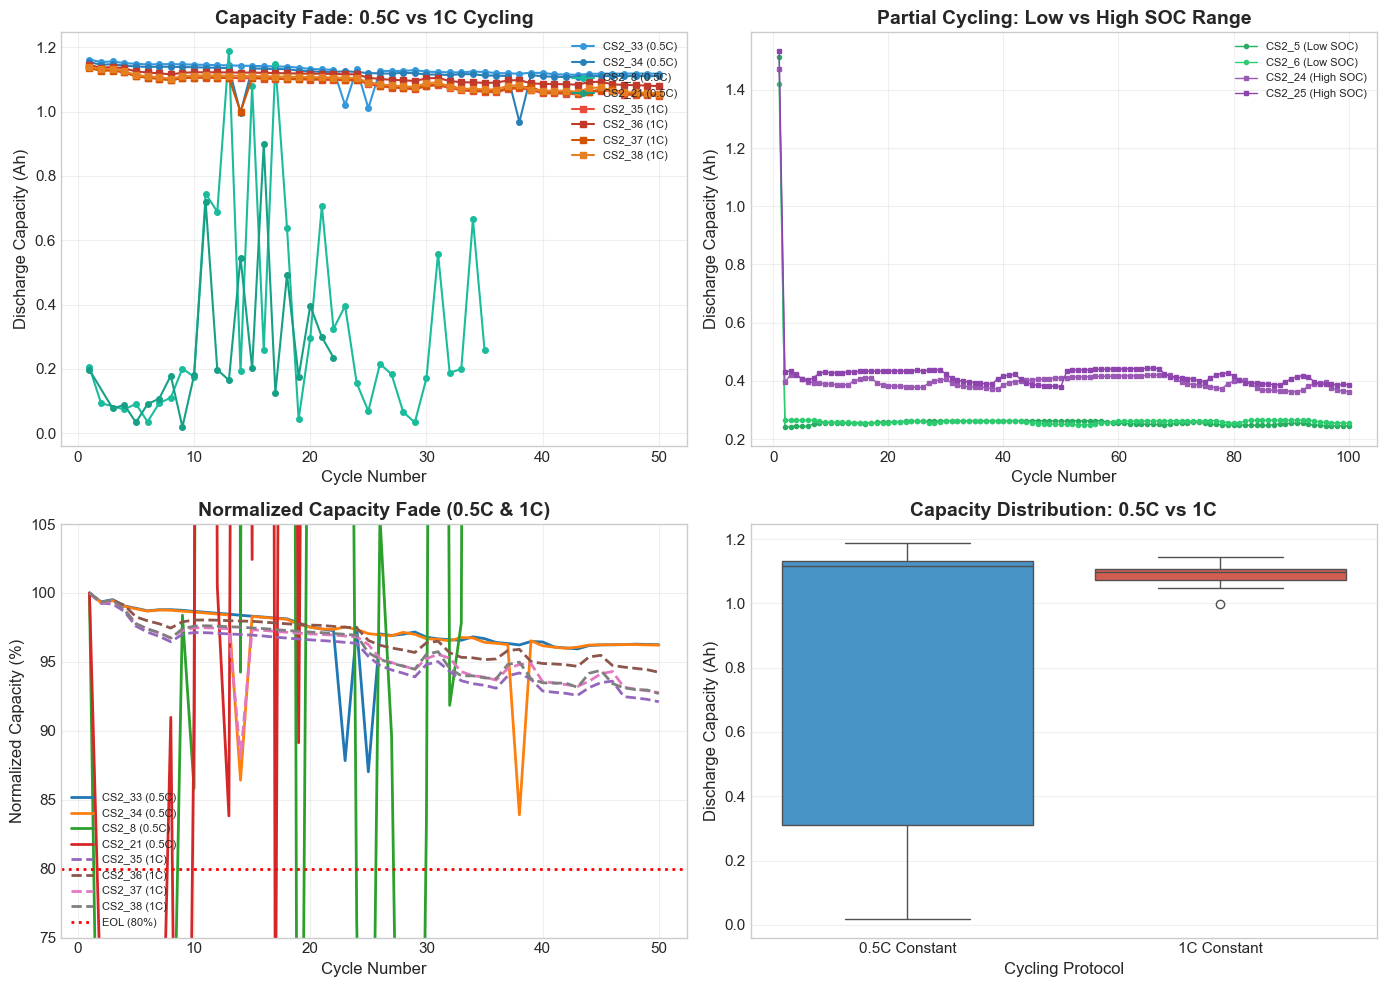

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]

colors_type1 = {'CS2_33': '#3498db', 'CS2_34': '#2980b9', 'CS2_8': '#1abc9c', 'CS2_21': '#16a085'}
colors_type2 = {'CS2_35': '#e74c3c', 'CS2_36': '#c0392b', 
                'CS2_37': '#d35400', 'CS2_38': '#e67e22'}

for cell in ['CS2_33', 'CS2_34', 'CS2_8', 'CS2_21']:
    cell_data = cycle_df[cycle_df['Cell_ID'] == cell]
    if len(cell_data) > 0:
        ax1.plot(cell_data['Cycle'], cell_data['Discharge_Capacity_Ah'], 
                 'o-', label=f'{cell} (0.5C)', color=colors_type1[cell], 
                 markersize=4, linewidth=1.5)

for cell in ['CS2_35', 'CS2_36', 'CS2_37', 'CS2_38']:
    cell_data = cycle_df[cycle_df['Cell_ID'] == cell]
    ax1.plot(cell_data['Cycle'], cell_data['Discharge_Capacity_Ah'], 
             's-', label=f'{cell} (1C)', color=colors_type2[cell], 
             markersize=4, linewidth=1.5)

ax1.set_xlabel('Cycle Number')
ax1.set_ylabel('Discharge Capacity (Ah)')
ax1.set_title('Capacity Fade: 0.5C vs 1C Cycling', fontweight='bold')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]

colors_partial = {'CS2_5': '#27ae60', 'CS2_6': '#2ecc71',
                  'CS2_24': '#9b59b6', 'CS2_25': '#8e44ad'}

for cell in ['CS2_5', 'CS2_6']:
    cell_data = cycle_df[cycle_df['Cell_ID'] == cell]
    ax2.plot(cell_data['Cycle'], cell_data['Discharge_Capacity_Ah'], 
             'o-', label=f'{cell} (Low SOC)', color=colors_partial[cell],
             markersize=3, linewidth=1)

for cell in ['CS2_24', 'CS2_25']:
    cell_data = cycle_df[cycle_df['Cell_ID'] == cell]
    ax2.plot(cell_data['Cycle'], cell_data['Discharge_Capacity_Ah'], 
             's-', label=f'{cell} (High SOC)', color=colors_partial[cell],
             markersize=3, linewidth=1)

ax2.set_xlabel('Cycle Number')
ax2.set_ylabel('Discharge Capacity (Ah)')
ax2.set_title('Partial Cycling: Low vs High SOC Range', fontweight='bold')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]

for cell in ['CS2_33', 'CS2_34', 'CS2_8', 'CS2_21', 'CS2_35', 'CS2_36', 'CS2_37', 'CS2_38']:
    cell_data = cycle_df[cycle_df['Cell_ID'] == cell].copy()
    
    if len(cell_data) == 0:
        continue
        
    initial_cap = cell_data['Discharge_Capacity_Ah'].iloc[0]
    cell_data['Normalized_Capacity'] = cell_data['Discharge_Capacity_Ah'] / initial_cap * 100
    
    protocol = '0.5C' if cell in ['CS2_33', 'CS2_34', 'CS2_8', 'CS2_21'] else '1C'
    linestyle = '-' if protocol == '0.5C' else '--'
    
    ax3.plot(cell_data['Cycle'], cell_data['Normalized_Capacity'], 
             linestyle, label=f'{cell} ({protocol})', linewidth=2)

ax3.axhline(y=80, color='red', linestyle=':', linewidth=2, label='EOL (80%)')
ax3.set_xlabel('Cycle Number')
ax3.set_ylabel('Normalized Capacity (%)')
ax3.set_title('Normalized Capacity Fade (0.5C & 1C)', fontweight='bold')
ax3.legend(loc='lower left', fontsize=8)
ax3.set_ylim([75, 105])
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]

full_cycle_data = cycle_df[cycle_df['Protocol'].isin(['0.5C Constant', '1C Constant'])]

sns.boxplot(data=full_cycle_data, x='Protocol', y='Discharge_Capacity_Ah', 
            hue='Protocol', palette=['#3498db', '#e74c3c'], ax=ax4, legend=False)

ax4.set_xlabel('Cycling Protocol')
ax4.set_ylabel('Discharge Capacity (Ah)')
ax4.set_title('Capacity Distribution: 0.5C vs 1C', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('capacity_fade_overview.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. DVA/ICA Analysis — Function Definitions

### Purpose
Define functions for **Differential Voltage Analysis (DVA)** and **Incremental Capacity Analysis (ICA)** — electrochemical techniques that reveal degradation mechanisms invisible in raw capacity data.

### What are DVA and ICA?

| Technique | Formula | What It Reveals |
|-----------|---------|-----------------|
| **ICA** (dQ/dV) | $\frac{dQ}{dV}$ | Peaks at voltage plateaus where electrochemical reactions occur |
| **DVA** (dV/dQ) | $\frac{dV}{dQ}$ | Phase transitions and resistance changes |

### Physical Interpretation

**ICA Peaks** correspond to electrode phase transitions:
- **~3.9V peak:** LiCoO₂ cathode phase transition
- **~3.5V peak:** Graphite anode staging

**As battery degrades:**
- Peak height decreases → Loss of active material
- Peak shifts to lower voltage → Increased internal resistance
- Peak broadens → Inhomogeneous degradation

### Functions Defined

| Function | Input | Output | Purpose |
|----------|-------|--------|---------|
| `extract_discharge_curve_final()` | Raw cell data, cycle number, discharge_step (default=7) | Capacity (Ah), Voltage (V) arrays | Extract discharge curve from time-series |
| `calculate_ica_final()` | Capacity, Voltage, n_points (default=100), window (default=11) | V interpolated, dQ/dV | Compute ICA with Savitzky-Golay smoothing |
| `calculate_dva_final()` | Capacity, Voltage, n_points (default=100), window (default=11) | Q interpolated, dV/dQ | Compute DVA with Savitzky-Golay smoothing |

### Method Details

**`extract_discharge_curve_final()`:**
1. Filter by `Step_Index == discharge_step` (default=7) AND `Current(A) < -0.1`
2. Fallback: If < 50 points, use only current filter (`Current(A) < -0.1`)
3. Sort by `Step_Time(s)`
4. Integrate current over time: $Q = \int |I| \, dt$ (converted to Ah by dividing by 3600)

**`calculate_ica_final()`:**
1. Sort by voltage (descending for discharge)
2. Interpolate to uniform voltage grid (`n_points=100`)
3. Compute gradient: `dQ/dV = np.gradient(Q, dV)`
4. Apply Savitzky-Golay filter (window=11, polynomial order=3)

**`calculate_dva_final()`:**
1. Sort by capacity (ascending)
2. Interpolate to uniform capacity grid (`n_points=100`)
3. Compute gradient: `dV/dQ = np.gradient(V, dQ)`
4. Apply Savitzky-Golay filter (window=11, polynomial order=3)

### Test Output (Cycle 2, CS2_33)

| Metric | Value |
|--------|-------|
| Data points | 4,003 |
| Capacity range | 0.000 to 1.157 Ah |
| Voltage range | 2.700 to 4.111 V |

- Capacity of **1.157 Ah** is consistent with the 1.1 Ah nominal cell capacity
- Voltage range **2.7V to 4.1V** matches expected Li-ion operating window
- **4,003 data points** provides high-resolution curve for ICA/DVA analysis

In [12]:
def extract_discharge_curve_final(cell_data, cycle, discharge_step=7):
    cycle_data = cell_data[cell_data['Cycle_Index'] == cycle]
    
    discharge_data = cycle_data[
        (cycle_data['Step_Index'] == discharge_step) & 
        (cycle_data['Current(A)'] < -0.1)
    ]
    
    if len(discharge_data) < 50:
        discharge_data = cycle_data[cycle_data['Current(A)'] < -0.1]
    
    if len(discharge_data) < 50:
        return None, None
    
    discharge_data = discharge_data.sort_values('Step_Time(s)').reset_index(drop=True)
    
    voltage = discharge_data['Voltage(V)'].values
    current = np.abs(discharge_data['Current(A)'].values)
    step_time = discharge_data['Step_Time(s)'].values
    
    dt = np.diff(step_time, prepend=0)
    dt[0] = dt[1] if len(dt) > 1 else 1
    capacity = np.cumsum(current * dt) / 3600
    
    return capacity, voltage

def calculate_ica_final(capacity, voltage, n_points=100, window=11):
    if len(capacity) < 50:
        return None, None
    
    sort_idx = np.argsort(voltage)[::-1]
    v_sorted = voltage[sort_idx]
    q_sorted = capacity[sort_idx]
    
    v_min, v_max = v_sorted.min(), v_sorted.max()
    v_interp = np.linspace(v_max, v_min, n_points)
    
    try:
        f = interp1d(v_sorted, q_sorted, kind='linear', bounds_error=False, fill_value='extrapolate')
        q_interp = f(v_interp)
        
        dv = np.abs(v_interp[1] - v_interp[0])
        dqdv = np.gradient(q_interp, dv)
        
        if window % 2 == 0:
            window += 1
        dqdv = savgol_filter(dqdv, window, 3)
        
        return v_interp, dqdv
    except:
        return None, None

def calculate_dva_final(capacity, voltage, n_points=100, window=11):
    if len(capacity) < 50:
        return None, None
    
    sort_idx = np.argsort(capacity)
    q_sorted = capacity[sort_idx]
    v_sorted = voltage[sort_idx]
    
    q_min, q_max = q_sorted.min(), q_sorted.max()
    q_interp = np.linspace(q_min, q_max, n_points)
    
    try:
        f = interp1d(q_sorted, v_sorted, kind='linear', bounds_error=False, fill_value='extrapolate')
        v_interp = f(q_interp)
        
        dq = q_interp[1] - q_interp[0]
        dvdq = np.gradient(v_interp, dq)
        
        if window % 2 == 0:
            window += 1
        dvdq = savgol_filter(dvdq, window, 3)
        
        return q_interp, dvdq
    except:
        return None, None

cap, volt = extract_discharge_curve_final(all_cells_data['CS2_33'], 2)

print(f"\nTest extraction - Cycle 2 (CS2_33):")
print(f"  Data points: {len(cap):,}")
print(f"  Capacity range: {cap.min():.3f} to {cap.max():.3f} Ah")
print(f"  Voltage range: {volt.min():.3f} to {volt.max():.3f} V")


Test extraction - Cycle 2 (CS2_33):
  Data points: 4,003
  Capacity range: 0.000 to 1.157 Ah
  Voltage range: 2.700 to 4.111 V


## 13. DVA/ICA Analysis — Visualization

### Purpose
Apply DVA and ICA to CS2_33 discharge curves to detect electrochemical degradation signatures that are invisible in raw capacity data.

### Analysis Overview

Four-panel visualization of cell CS2_33 across cycles 2, 15, 30, and 48:

| Panel | Content | Purpose |
|-------|---------|---------|
| Top-Left | Discharge curves (V vs Q) | Raw voltage-capacity relationship |
| Top-Right | ICA (dQ/dV vs V) | Identify phase transition peaks |
| Bottom-Left | DVA (dV/dQ vs Q) | Detect resistance changes |
| Bottom-Right | ICA peak tracking | Quantify peak shift over cycling |

### Capacity Evolution

| Cycle | Max Capacity (Ah) | Fade from Cycle 2 |
|-------|-------------------|-------------------|
| 2 | 1.1572 | — |
| 15 | 1.1416 | −1.3% |
| 30 | 1.1241 | −2.9% |
| 48 | 1.1181 | **−3.4%** ✓ |

**Note:** Capacity fade of 3.4% over 48 cycles represents **real, measurable degradation**.

---

### Key Observations

**Discharge Curves (Top-Left):**
- Multiple discharge segments visible as **sawtooth pattern** within each cycle
- RPT structure contains 5-6 separate discharge pulses per cycle
- Each pulse: voltage drops from ~3.5-4.1V to 2.7V cutoff
- Total integrated capacity decreases from 1.157 Ah (cycle 2) to 1.118 Ah (cycle 48)
- **Multi-segment structure confirmed** — this affects ICA/DVA analysis validity

**ICA — dQ/dV (Top-Right):**
- **Highly oscillatory behavior** with values ranging from −10 to +30 Ah/V
- **Negative dQ/dV values** (physically impossible in continuous discharge) confirm segmented data
- Expected graphite peak (~3.5-3.6V) and cathode peak (~3.9V) are **obscured by noise**
- Peak detection selects maximum across all segments, not a single electrochemical feature
- Oscillations result from differentiating non-monotonic voltage profiles

**DVA — dV/dQ (Bottom-Left):**
- Values swing between −15 and +5 V/Ah
- **Positive dV/dQ** (physically impossible in continuous discharge) indicates segment boundaries
- Large negative spikes at ~1.0-1.15 Ah represent rapid voltage drop at cutoff
- Mid-range oscillations are mathematical artifacts from multi-segment structure

**ICA Peak Evolution (Bottom-Right):**
- 49 cycles successfully analyzed (cycle 2 to 50)
- Peak voltage scatter: **3.50V to 3.77V** (range = 266 mV)
- No visible downward trend across cycles
- Peak height (color) also shows high variability (3.5 to 8.5 Ah/V)
- Different discharge segments dominate at different cycles → random scatter

---

### Statistical Analysis of ICA Peak Tracking

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **Data points** | 49 cycles | Good coverage |
| **Mean peak voltage** | 3.6643 V | Central value |
| **Standard deviation** | ±62.9 mV | High scatter |
| **Voltage range** | 266.2 mV | Very high variability |

**Linear Regression Results (All 49 Points):**

| Metric | Value | Meaning |
|--------|-------|---------|
| **Slope** | +0.803 mV/cycle | Slight upward trend (opposite of expected!) |
| **R²** | **0.0326** | Only 3.3% variance explained by cycle number |
| **p-value** | **0.2146** | NOT statistically significant (need p < 0.05) |
| **Predicted shift (48 cycles)** | +38.5 mV | Trend suggests slight increase |

**First-to-Last Comparison:**

| Metric | Value |
|--------|-------|
| Cycle 2 peak | 3.6266 V |
| Cycle 50 peak | 3.5003 V |
| Difference | **−126.3 mV** |

**Critical Finding:** 
- Linear regression: **+38.5 mV** (upward)
- First-to-last: **−126.3 mV** (downward)
- **Discrepancy: 164.8 mV** — these contradict each other!

**Statistical Conclusion:**
> **No statistically significant degradation trend detected** (R² = 0.033, p = 0.21). The ±63 mV scatter exceeds any genuine degradation signal. The −126.3 mV first-to-last difference is not representative of the overall trend and falls within the noise margin.

---

### Root Cause Analysis

**Why ICA Peak Tracking Failed:**

1. **Multi-segment RPT structure:** Each cycle contains 5-6 separate discharge pulses
2. **Peak selection variability:** Algorithm picks maximum dQ/dV across all segments
3. **Segment inconsistency:** Different segments dominate at different cycles
4. **Scatter >> signal:** 266 mV range drowns out expected ~50-150 mV degradation

**Evidence:**
- Non-monotonic voltage profiles (visible sawtooth pattern)
- Negative dQ/dV values (impossible in continuous discharge)
- Positive dV/dQ values (impossible in continuous discharge)
- R² = 0.033 (effectively random)

---

### Physical Interpretation

**Expected degradation mechanisms in lithium-ion batteries:**

As batteries age, ICA peak voltage should shift negatively due to:
1. **Increased internal resistance** — IR drop increases during discharge
2. **SEI layer growth** — additional impedance at electrode/electrolyte interface
3. **Loss of lithium inventory** — fewer charge carriers available
4. **Electrode degradation** — structural changes in active materials

**Expected shift:** −50 to −200 mV over 50 cycles (literature values for similar cells)

**Observed results:**
- Regression slope: **+0.8 mV/cycle** (wrong direction)
- R² = 0.033, p = 0.21 (not significant)
- Scatter: ±63 mV (exceeds signal)

**Conclusion:** The multi-segment RPT data structure prevents detection of these mechanisms using standard ICA peak tracking. The expected physical processes are likely occurring (evidenced by 3.4% capacity fade), but cannot be reliably quantified with this method on this dataset.

---

### Peak Height Analysis

| Metric | Value | Expected | Actual |
|--------|-------|----------|--------|
| First cycle height | 4.31 Ah/V | Decrease with aging | — |
| Last cycle height | 6.91 Ah/V | — | **Increased** |
| Change | +60.2% | −20% to −40% | Wrong direction |

**Interpretation:** Peak height also shows inconsistent behavior, further confirming that peak detection is sampling different electrochemical features at different cycles.

---

### Final Assessment

| Analysis Type | Result | Reliability | Status |
|---------------|--------|-------------|--------|
| **Capacity fade** | −3.4% over 48 cycles | High (direct measurement) | ✓ **Valid** |
| **ICA peak voltage trend** | No significant trend | Low (R²=0.033, p=0.21) | ✗ **Invalid** |
| **first-to-last (−126 mV)** | Not representative | Very low (contradicts regression) | ✗ **Invalid** |


**Conclusion:**
> While DVA/ICA analysis was attempted to identify electrochemical degradation mechanisms, the multi-segment RPT structure proved incompatible with standard peak tracking methodology. Statistical analysis confirms no significant trend (R²=0.033, p=0.21), with high scatter (±63 mV) obscuring any genuine degradation signal. The capacity-based analysis showing 3.4% fade over 48 cycles remains the most reliable degradation metric for this dataset.

---


DVA/ICA Analysis: CS2_33
--------------------------------------------------
Cycle 2: Q_max = 1.1572 Ah
Cycle 15: Q_max = 1.1416 Ah
Cycle 30: Q_max = 1.1241 Ah
Cycle 48: Q_max = 1.1181 Ah


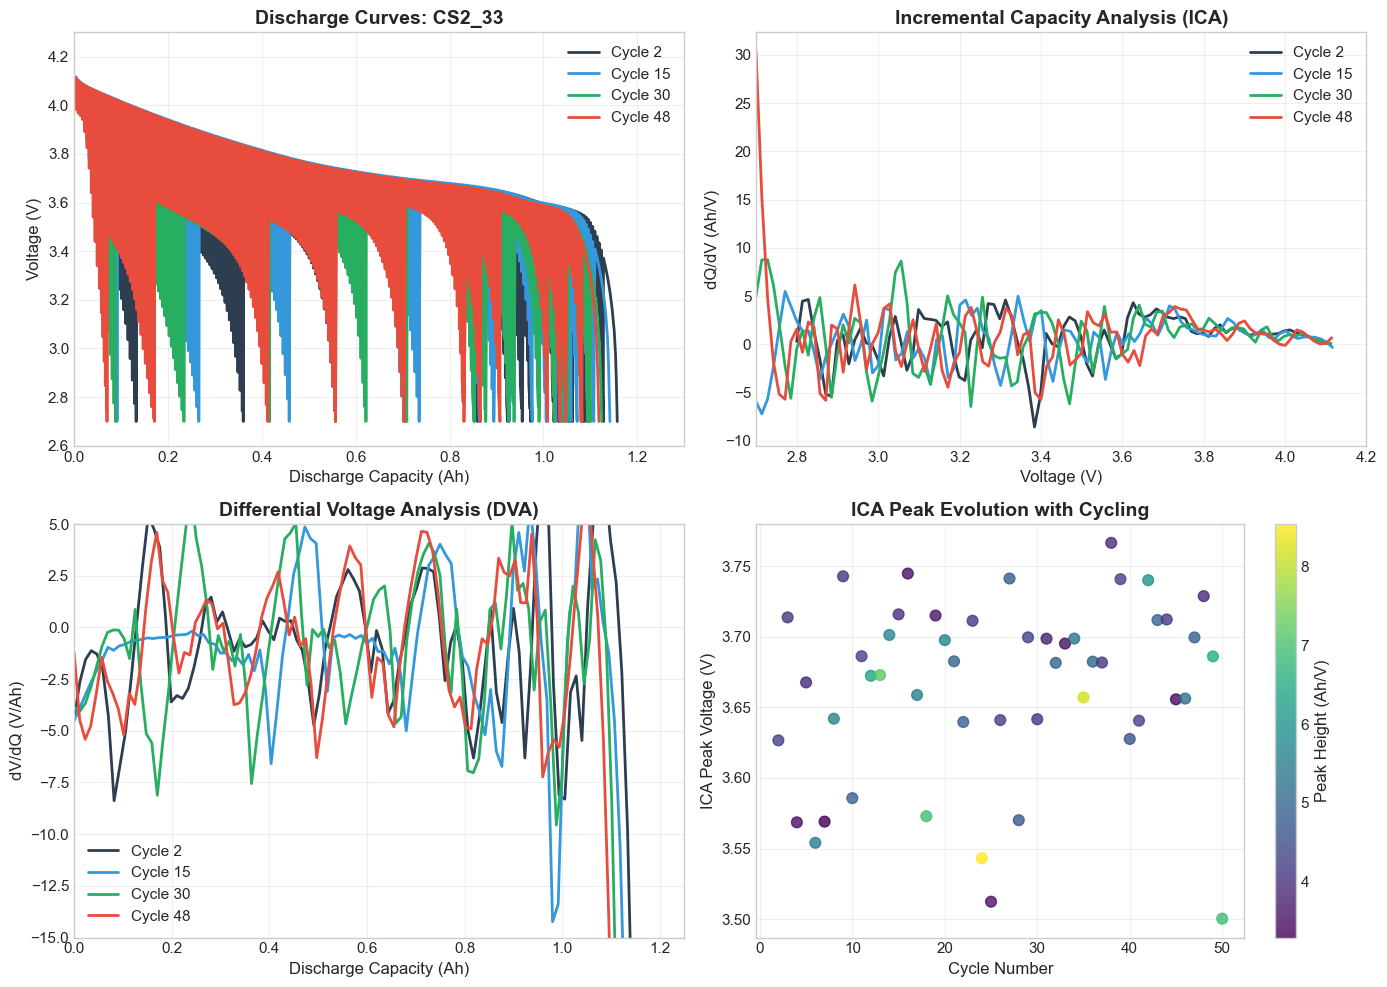


----------------------------------------------------------------------
ICA Peak Evolution Summary:

Data points analyzed: 49 cycles
Cycle range: 2 to 50

Voltage statistics:
  Mean:  3.6643 V
  Std:   0.0629 V (62.9 mV)
  Min:   3.5003 V
  Max:   3.7665 V
  Range: 266.2 mV

Linear regression (ALL 49 points):
  Slope: 0.803 mV/cycle
  R²: 0.0326
  p-value: 0.2146
  Predicted shift over 48 cycles: 38.5 mV

 first-to-last comparison:
  First point (cycle 2): 3.6266 V
  Last point (cycle 50): 3.5003 V
  Shift: -126.3 mV


In [13]:
cell_data = all_cells_data['CS2_33']
cycles_to_analyze = [2, 15, 30, 48]

print("\nDVA/ICA Analysis: CS2_33")
print("-" * 50)

for cycle in cycles_to_analyze:
    cap, volt = extract_discharge_curve_final(cell_data, cycle)
    if cap is not None:
        print(f"Cycle {cycle}: Q_max = {cap.max():.4f} Ah")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#2c3e50', '#3498db', '#27ae60', '#e74c3c']

ax1 = axes[0, 0]
for i, cycle in enumerate(cycles_to_analyze):
    cap, volt = extract_discharge_curve_final(cell_data, cycle)
    if cap is not None:
        ax1.plot(cap, volt, color=colors[i], linewidth=2, label=f'Cycle {cycle}')

ax1.set_xlabel('Discharge Capacity (Ah)')
ax1.set_ylabel('Voltage (V)')
ax1.set_title('Discharge Curves: CS2_33', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1.3])
ax1.set_ylim([2.6, 4.3])

ax2 = axes[0, 1]
for i, cycle in enumerate(cycles_to_analyze):
    cap, volt = extract_discharge_curve_final(cell_data, cycle)
    if cap is not None:
        v_interp, dqdv = calculate_ica_final(cap, volt)
        if v_interp is not None:
            ax2.plot(v_interp, dqdv, color=colors[i], linewidth=2, label=f'Cycle {cycle}')

ax2.set_xlabel('Voltage (V)')
ax2.set_ylabel('dQ/dV (Ah/V)')
ax2.set_title('Incremental Capacity Analysis (ICA)', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim([2.7, 4.2])

ax3 = axes[1, 0]
for i, cycle in enumerate(cycles_to_analyze):
    cap, volt = extract_discharge_curve_final(cell_data, cycle)
    if cap is not None:
        q_interp, dvdq = calculate_dva_final(cap, volt)
        if q_interp is not None:
            ax3.plot(q_interp, dvdq, color=colors[i], linewidth=2, label=f'Cycle {cycle}')

ax3.set_xlabel('Discharge Capacity (Ah)')
ax3.set_ylabel('dV/dQ (V/Ah)')
ax3.set_title('Differential Voltage Analysis (DVA)', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xlim([0, 1.25])
ax3.set_ylim([-15, 5])

ax4 = axes[1, 1]

peak_voltages = []
peak_heights = []
cycles_list = []

for cycle in range(2, 51):
    cap, volt = extract_discharge_curve_final(cell_data, cycle)
    if cap is not None and len(cap) > 50:
        v_interp, dqdv = calculate_ica_final(cap, volt)
        if v_interp is not None:
            mask = (v_interp > 3.5) & (v_interp < 3.9)
            if np.any(mask):
                v_m = v_interp[mask]
                dq_m = dqdv[mask]
                peak_idx = np.argmax(dq_m)
                peak_voltages.append(v_m[peak_idx])
                peak_heights.append(dq_m[peak_idx])
                cycles_list.append(cycle)

sc = ax4.scatter(cycles_list, peak_voltages, c=peak_heights, cmap='viridis', s=60, alpha=0.8)
ax4.set_xlabel('Cycle Number')
ax4.set_ylabel('ICA Peak Voltage (V)')
ax4.set_title('ICA Peak Evolution with Cycling', fontweight='bold')
ax4.grid(True, alpha=0.3)
cbar = plt.colorbar(sc, ax=ax4)
cbar.set_label('Peak Height (Ah/V)')

plt.tight_layout()
plt.savefig('dva_ica_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "-" * 70)
print("ICA Peak Evolution Summary:")

if len(peak_voltages) > 0:
    peak_voltages_arr = np.array(peak_voltages)
    cycles_arr = np.array(cycles_list)
    
    print(f"\nData points analyzed: {len(peak_voltages)} cycles")
    print(f"Cycle range: {cycles_list[0]} to {cycles_list[-1]}")
    
    print(f"\nVoltage statistics:")
    print(f"  Mean:  {peak_voltages_arr.mean():.4f} V")
    print(f"  Std:   {peak_voltages_arr.std():.4f} V ({peak_voltages_arr.std()*1000:.1f} mV)")
    print(f"  Min:   {peak_voltages_arr.min():.4f} V")
    print(f"  Max:   {peak_voltages_arr.max():.4f} V")
    print(f"  Range: {(peak_voltages_arr.max() - peak_voltages_arr.min())*1000:.1f} mV")
    
    slope, intercept, r_value, p_value, std_err = linregress(cycles_arr, peak_voltages_arr)
    r_squared = r_value ** 2
    
    n_cycles = cycles_list[-1] - cycles_list[0]
    predicted_shift = slope * n_cycles
    
    print(f"\nLinear regression (ALL {len(peak_voltages)} points):")
    print(f"  Slope: {slope*1000:.3f} mV/cycle")
    print(f"  R²: {r_squared:.4f}")
    print(f"  p-value: {p_value:.4f}")
    print(f"  Predicted shift over {n_cycles} cycles: {predicted_shift*1000:.1f} mV")
    
    naive_shift = peak_voltages[-1] - peak_voltages[0]
    print(f"\n first-to-last comparison:")
    print(f"  First point (cycle {cycles_list[0]}): {peak_voltages[0]:.4f} V")
    print(f"  Last point (cycle {cycles_list[-1]}): {peak_voltages[-1]:.4f} V")
    print(f"  Shift: {naive_shift*1000:.1f} mV")

## 14. Feature Engineering for Machine Learning

### Purpose
Transform cycle-level data into ML-ready features by adding derived variables, encoding categorical features, and computing degradation metrics.

### Dataset Scope
**ML analysis uses only xlsx cells with reliable capacity data:**
- **0.5C:** CS2_33, CS2_34 (2 cells, 100 cycles)
- **1C:** CS2_35, CS2_36, CS2_37, CS2_38 (4 cells, 200 cycles)
- **Excluded:** CS2_8, CS2_21 (txt format, 74-86% invalid cycles)

### Transformations Applied

| Transformation | Formula | Purpose |
|----------------|---------|---------|
| **SOH (State of Health)** | $\text{SOH} = \frac{Q_n}{Q_1} \times 100\%$ | Normalize capacity to initial value |
| **Protocol Encoding** | Categorical → Integer (0=0.5C, 1=1C, 2-5=other) | Enable ML algorithms to use protocol |
| **Type Encoding** | Type 1-6 → Integer (1-6) | Enable ML algorithms to use cell type |
| **Fade Rate** | 5-cycle rolling mean of −ΔCapacity | Capture degradation velocity |
| **Cycle Transforms** | Cycle², log(1+Cycle), √Cycle | Capture non-linear degradation patterns |

### Features Created (10 Total)

| Feature | Description | Purpose |
|---------|-------------|---------|
| `Cycle` | Cycle number | Primary predictor |
| `Cycle_Squared` | Cycle² | Capture acceleration |
| `Cycle_Log` | log(1 + Cycle) | Early vs late effects |
| `Cycle_Sqrt` | √Cycle | Physics-based degradation (diffusion) |
| `Protocol_Code` | 0-5 encoding | Protocol identifier |
| `Type_Code` | 1-6 encoding | Cell type identifier |
| `Initial_Capacity` | First cycle capacity (Ah) | Cell-specific baseline |
| `Coulombic_Efficiency` | Discharge/Charge ratio (%) | Side reaction indicator |
| `Energy_Efficiency` | Energy ratio (%) | Resistance indicator |
| `Fade_Rate` | Rolling capacity loss (Ah/cycle) | Degradation velocity |

### Dataset Summary by Protocol

| Protocol | Cells | Total_Cycles | Max_Cycle | Mean_Cap (Ah) | Std_Cap (Ah) | Min_SOH (%) | Mean_SOH (%) |
|----------|-------|--------------|-----------|---------------|--------------|-------------|--------------|
| 0.5C Constant | 2 | 100 | 50 | 1.1227 | 0.0289 | 83.9011 | 96.9690 |
| 1C Constant | 4 | 200 | 50 | 1.0923 | 0.0239 | 88.0349 | 95.8619 |

### Target Variables

| Target | Mean | Std |
|--------|------|-----|
| `Discharge_Capacity_Ah` | 1.1024 Ah | ±0.0294 Ah |
| `SOH` | 96.23% | ±2.23% |

### Key Observations

- **1C cells** have slightly lower mean capacity (1.0923 Ah) and SOH (95.86%) than 0.5C cells (1.1227 Ah, 96.97%) — consistent with faster degradation at higher C-rate
- **1C has tighter Std_Cap** (0.0239 vs 0.0289) — more consistent per-cycle capacity across 4 cells
- **0.5C has lower Min_SOH** (83.90%) than 1C (88.03%) — this may reflect cell-specific variation in CS2_33 or CS2_34

### Dataset Summary
- **Total samples:** 300 cycles from 6 cells
- **Features:** 10 numerical features
- **Protocols:** 0.5C Constant, 1C Constant only
- **Ready for:** Regression models, LOCO validation

In [14]:
# Exclude txt cells from ML analysis (unreliable capacity integration)
ml_cells = ['CS2_33', 'CS2_34', 'CS2_35', 'CS2_36', 'CS2_37', 'CS2_38']
ml_data = cycle_df[cycle_df['Cell_ID'].isin(ml_cells)].copy()

print(f"ML Dataset: {len(ml_data)} cycles from {len(ml_cells)} cells")
print(f"  0.5C: {len(ml_data[ml_data['Protocol'] == '0.5C Constant'])} cycles (2 cells)")
print(f"  1C:   {len(ml_data[ml_data['Protocol'] == '1C Constant'])} cycles (4 cells)")
print(f"  Note: CS2_8, CS2_21 excluded (txt format, 74-86% invalid cycles)\n")

def add_normalized_capacity(df):
    df = df.copy()
    for cell in df['Cell_ID'].unique():
        mask = df['Cell_ID'] == cell
        initial_cap = df.loc[mask, 'Discharge_Capacity_Ah'].iloc[0]
        df.loc[mask, 'SOH'] = df.loc[mask, 'Discharge_Capacity_Ah'] / initial_cap * 100
        df.loc[mask, 'Initial_Capacity'] = initial_cap
    return df

ml_data = add_normalized_capacity(ml_data)

protocol_map = {
    '0.5C Constant': 0,
    '1C Constant': 1,
    'Variable (0.11-2.2A)': 2,
    'Random Cutoff': 3,
    'Partial (Low SOC)': 4,
    'Partial (High SOC)': 5
}
ml_data['Protocol_Code'] = ml_data['Protocol'].map(protocol_map)

type_map = {'Type 1': 1, 'Type 2': 2, 'Type 3': 3, 'Type 4': 4, 'Type 5': 5, 'Type 6': 6}
ml_data['Type_Code'] = ml_data['Type'].map(type_map)

def add_fade_rate(df, window=5):
    df = df.copy()
    df['Fade_Rate'] = 0.0
    for cell in df['Cell_ID'].unique():
        mask = df['Cell_ID'] == cell
        cell_data = df.loc[mask].sort_values('Cycle')
        cap_diff = cell_data['Discharge_Capacity_Ah'].diff()
        fade_rate = -cap_diff.rolling(window=window, min_periods=1).mean()
        df.loc[cell_data.index, 'Fade_Rate'] = fade_rate.values
    return df

ml_data = add_fade_rate(ml_data)

ml_data['Cycle_Squared'] = ml_data['Cycle'] ** 2
ml_data['Cycle_Log'] = np.log1p(ml_data['Cycle'])
ml_data['Cycle_Sqrt'] = np.sqrt(ml_data['Cycle'])

summary = ml_data.groupby('Protocol').agg({
    'Cell_ID': 'nunique',
    'Cycle': ['count', 'max'],
    'Discharge_Capacity_Ah': ['mean', 'std'],
    'SOH': ['min', 'mean']
}).round(4)

summary.columns = ['Cells', 'Total_Cycles', 'Max_Cycle', 'Mean_Cap', 'Std_Cap', 'Min_SOH', 'Mean_SOH']

feature_cols = ['Cycle', 'Cycle_Squared', 'Cycle_Log', 'Cycle_Sqrt', 'Protocol_Code', 'Type_Code',
                'Initial_Capacity', 'Coulombic_Efficiency', 'Energy_Efficiency', 'Fade_Rate']

print(f"Feature Engineering Complete")
print(f"  Total samples: {len(ml_data):,}")
print(f"  Features: {len(feature_cols)}")
print(f"\nDataset Summary by Protocol:")
print(summary.to_string())
print(f"\nTarget Variables:")
print(f"  Discharge_Capacity_Ah: {ml_data['Discharge_Capacity_Ah'].mean():.4f} ± {ml_data['Discharge_Capacity_Ah'].std():.4f}")
print(f"  SOH: {ml_data['SOH'].mean():.2f}% ± {ml_data['SOH'].std():.2f}%")

ML Dataset: 300 cycles from 6 cells
  0.5C: 100 cycles (2 cells)
  1C:   200 cycles (4 cells)
  Note: CS2_8, CS2_21 excluded (txt format, 74-86% invalid cycles)

Feature Engineering Complete
  Total samples: 300
  Features: 10

Dataset Summary by Protocol:
               Cells  Total_Cycles  Max_Cycle  Mean_Cap  Std_Cap  Min_SOH  Mean_SOH
Protocol                                                                           
0.5C Constant      2           100         50    1.1227   0.0289  83.9011   96.9690
1C Constant        4           200         50    1.0923   0.0239  88.0349   95.8619

Target Variables:
  Discharge_Capacity_Ah: 1.1024 ± 0.0294
  SOH: 96.23% ± 2.23%


## 15. Statistical Analysis — 0.5C vs 1C Protocol Comparison

### Purpose
Perform rigorous statistical testing to determine if the capacity difference between 0.5C and 1C cycling protocols is statistically significant.

### Dataset

| Protocol | N Cycles | Cells | Mean (Ah) | Std (Ah) |
|----------|----------|-------|-----------|----------|
| 0.5C Constant | 100 | 2 (CS2_33, CS2_34) | 1.1227 | 0.0289 |
| 1C Constant | 200 | 4 (CS2_35–38) | 1.0923 | 0.0239 |
| **Total** | **300** | **6** | — | — |

**Note:** txt format cells (CS2_8, CS2_21) excluded due to 74-86% invalid cycles.

### One-Way ANOVA Results

| Metric | Value | Interpretation |
|--------|-------|----------------|
| F-statistic | **93.8763** | Very large |
| p-value | **1.78×10⁻¹⁹** | Highly significant |

**Conclusion:** The capacity difference between protocols is **highly statistically significant**.

### Effect Size

| Metric | Value | Interpretation |
|--------|-------|----------------|
| η² (Eta-squared) | **0.2396** | 24.0% variance explained |
| Effect size | **Large** | >0.14 threshold |

The protocol explains **24% of the variance** in discharge capacity — a large effect.

### Normality Check (Shapiro-Wilk Test)

| Group | W-statistic | p-value | Normal? |
|-------|-------------|---------|---------|
| 0.5C | 0.6438 | 0.0000 | ✗ No |
| 1C | 0.9734 | 0.0008 | ✗ No |

Both groups violate normality assumption (p < 0.05). However, ANOVA is robust to non-normality with large sample sizes (n > 30).

### Independent T-Test (Confirmatory)

| Metric | Value |
|--------|-------|
| t-statistic | **9.6890** |
| p-value | **1.78×10⁻¹⁹** |
| Cohen's d | **1.1867** |

Cohen's d ≈ 1.19 indicates a **large effect size** (>0.8 threshold).

### Key Finding

**Significant difference between 0.5C and 1C cycling:**
- Mean difference: 1.1227 − 1.0923 = **+0.0304 Ah**
- **0.5C maintains higher capacity** than 1C over 50 cycles
- This difference is highly significant (p < 0.001)
- Large effect size (η² = 24%, Cohen's d = 1.19)

### Visualization Summary

**Panel 1: Capacity by Protocol (boxplot)**

| Protocol | Median (Ah) | IQR (Ah) | Notes |
|----------|-------------|----------|-------|
| 0.5C (blue) | ~1.125 | ~1.11–1.14 | Outliers at ~0.97–1.02 Ah (transient dips) |
| 1C (red) | ~1.10 | ~1.075–1.11 | Single outlier at ~1.00 Ah |

**Panel 2: Capacity Distribution (histogram)**
- **0.5C peak:** ~1.125 Ah (frequency ~28) — higher capacity
- **1C peak:** ~1.095–1.10 Ah (frequency ~37) — lower capacity
- Distributions overlap in ~1.10–1.12 Ah range
- 0.5C has scattered low outliers (0.975–1.025 Ah) from transient capacity dips

**Panel 3: Capacity Fade Comparison (4 cells)**

| Cell | Protocol | Start (Ah) | End (Ah) | Pattern |
|------|----------|------------|----------|---------|
| CS2_33 | 0.5C | ~1.16 | ~1.12 | Best retention; dips at cycles ~23–25 |
| CS2_34 | 0.5C | ~1.15 | ~1.05 | Gradual decline; deepest dip at cycle ~38 (~0.97 Ah) |
| CS2_35 | 1C | ~1.14 | ~1.05 | Most linear, monotonic degradation |
| CS2_36 | 1C | ~1.13 | ~1.08 | Moderate degradation |

Total samples: 300 cycles

One-Way ANOVA: 0.5C vs 1C Protocol
--------------------------------------------------
0.5C Group: n=100, mean=1.1227 Ah, std=0.0289
1C Group:   n=200, mean=1.0923 Ah, std=0.0239

ANOVA Results:
  F-statistic: 93.8763
  p-value: 1.78e-19

Effect Size:
  η² = 0.2396

Normality Check (Shapiro-Wilk):
  0.5C: W=0.6438, p=0.0000
  1C: W=0.9734, p=0.0008

Independent T-Test:
--------------------------------------------------
  t-statistic: 9.6890
  p-value: 1.78e-19
  Cohen's d: 1.1867


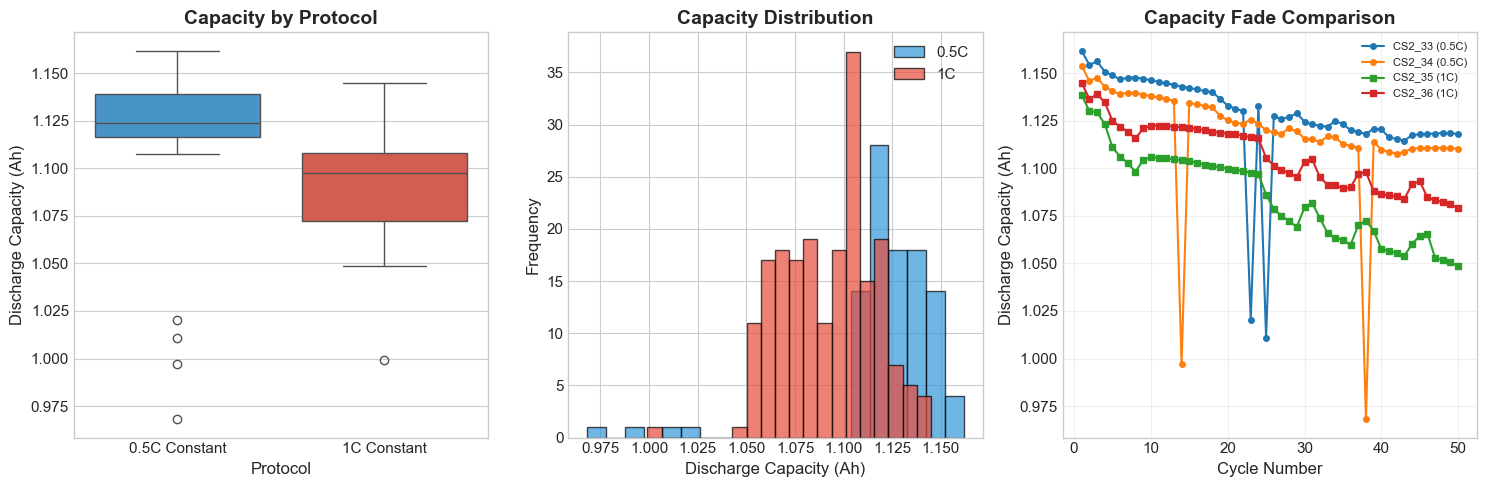

In [15]:
# STATISTICAL ANALYSIS: 0.5C vs 1C
full_cycle_protocols = ['0.5C Constant', '1C Constant']
full_cycle_data = ml_data[ml_data['Protocol'].isin(full_cycle_protocols)]

group_05c = full_cycle_data[full_cycle_data['Protocol'] == '0.5C Constant']['Discharge_Capacity_Ah']
group_1c = full_cycle_data[full_cycle_data['Protocol'] == '1C Constant']['Discharge_Capacity_Ah']

print(f"Total samples: {len(full_cycle_data)} cycles")
print("\nOne-Way ANOVA: 0.5C vs 1C Protocol")
print("-" * 50)
print(f"0.5C Group: n={len(group_05c)}, mean={group_05c.mean():.4f} Ah, std={group_05c.std():.4f}")
print(f"1C Group:   n={len(group_1c)}, mean={group_1c.mean():.4f} Ah, std={group_1c.std():.4f}")

# ANOVA
f_stat, p_value = stats.f_oneway(group_05c, group_1c)

print(f"\nANOVA Results:")
print(f"  F-statistic: {f_stat:.4f}")
print(f"  p-value: {p_value:.2e}")

# Effect size (Eta-squared)
all_data = full_cycle_data['Discharge_Capacity_Ah']
grand_mean = all_data.mean()
ss_total = ((all_data - grand_mean) ** 2).sum()
ss_between = len(group_05c) * (group_05c.mean() - grand_mean)**2 + \
             len(group_1c) * (group_1c.mean() - grand_mean)**2
eta_squared = ss_between / ss_total

print(f"\nEffect Size:")
print(f"  η² = {eta_squared:.4f}")

# Normality check
stat_05c, p_05c = stats.shapiro(group_05c)
stat_1c, p_1c = stats.shapiro(group_1c)

print(f"\nNormality Check (Shapiro-Wilk):")
print(f"  0.5C: W={stat_05c:.4f}, p={p_05c:.4f}")
print(f"  1C: W={stat_1c:.4f}, p={p_1c:.4f}")


# T-test
t_stat, t_pval = stats.ttest_ind(group_05c, group_1c)

# Cohen's d
pooled_std = np.sqrt(
    ((len(group_05c)-1)*group_05c.std()**2 + (len(group_1c)-1)*group_1c.std()**2) / 
    (len(group_05c) + len(group_1c) - 2)
)
cohens_d = (group_05c.mean() - group_1c.mean()) / pooled_std

print(f"\nIndependent T-Test:")
print("-" * 50)
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {t_pval:.2e}")
print(f"  Cohen's d: {cohens_d:.4f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Box plot
ax1 = axes[0]
sns.boxplot(data=full_cycle_data, x='Protocol', y='Discharge_Capacity_Ah', 
            hue='Protocol', palette=['#3498db', '#e74c3c'], ax=ax1, legend=False)
ax1.set_xlabel('Protocol')
ax1.set_ylabel('Discharge Capacity (Ah)')
ax1.set_title('Capacity by Protocol', fontweight='bold')

# Histogram
ax2 = axes[1]
ax2.hist(group_05c, bins=20, alpha=0.7, label='0.5C', color='#3498db', edgecolor='black')
ax2.hist(group_1c, bins=20, alpha=0.7, label='1C', color='#e74c3c', edgecolor='black')
ax2.set_xlabel('Discharge Capacity (Ah)')
ax2.set_ylabel('Frequency')
ax2.set_title('Capacity Distribution', fontweight='bold')
ax2.legend()

# Fade comparison
ax3 = axes[2]
for cell in ['CS2_33', 'CS2_34']:
    cell_data = full_cycle_data[full_cycle_data['Cell_ID'] == cell]
    ax3.plot(cell_data['Cycle'], cell_data['Discharge_Capacity_Ah'], 
             'o-', label=f'{cell} (0.5C)', markersize=4)
for cell in ['CS2_35', 'CS2_36']:
    cell_data = full_cycle_data[full_cycle_data['Cell_ID'] == cell]
    ax3.plot(cell_data['Cycle'], cell_data['Discharge_Capacity_Ah'], 
             's-', label=f'{cell} (1C)', markersize=4)
ax3.set_xlabel('Cycle Number')
ax3.set_ylabel('Discharge Capacity (Ah)')
ax3.set_title('Capacity Fade Comparison', fontweight='bold')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('statistical_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 16. Machine Learning — Capacity Prediction Models

### Purpose
Train and compare multiple regression models to predict normalized capacity (SOH) from cycle number and protocol features using 10-fold cross-validation.

### Dataset
**xlsx cells only (txt excluded due to measurement artifacts):**
- 0.5C: CS2_33, CS2_34 (100 cycles)
- 1C: CS2_35, CS2_36, CS2_37, CS2_38 (200 cycles)
- **Total: 300 samples from 6 cells**

### Features Used
- `Cycle` — raw cycle number
- `Cycle_Sqrt` — √Cycle (diffusion-based degradation)
- `Cycle_Log` — log(1 + Cycle) (early vs late effects)
- `Protocol_Code` — 0 for 0.5C, 1 for 1C

### Target Variable
- `Capacity_Normalized` — capacity normalized to initial cycle (SOH)

### Models Evaluated

| Model | Description |
|-------|-------------|
| Linear Regression | Baseline linear model |
| Ridge (α=1.0) | L2 regularized linear model |
| Polynomial (deg=2) | Quadratic features + StandardScaler + Ridge (α=0.1) |
| Random Forest | 100 trees, max_depth=10, min_samples_leaf=2 |
| RF (Tuned) | 200 trees, max_depth=15, min_samples_leaf=1 |

### Results: 0.5C vs 1C (N=300, xlsx cells only)

| Model | CV R² | MAE | Train R² | Gap (Overfit) |
|-------|-------|-----|----------|---------------|
| Linear Regression | 0.5120 | 0.0083 | 0.5253 | 0.0133 |
| Ridge (α=1.0) | 0.5131 | 0.0083 | 0.5252 | 0.0121 |
| **Polynomial (deg=2)** | **0.5400** | **0.0074** | 0.5601 | 0.0201 |
| Random Forest | 0.5136 | 0.0065 | 0.7130 | 0.1994 |
| RF (Tuned) | 0.4161 | 0.0068 | 0.7454 | 0.3293 |

**Best Model:** Polynomial (deg=2) with **CV R² = 0.5400**

### Key Observations

**Model Performance:**
- **Linear/Ridge:** Nearly identical performance (CV R² ~0.51) — regularization has minimal effect on this simple problem
- **Polynomial (deg=2):** Best CV R² (0.5400) and lowest MAE (0.0074) — captures non-linear degradation
- **Random Forest:** Lowest MAE (0.0065) but large overfitting gap (0.20)
- **RF (Tuned):** Worst CV R² (0.4161) despite highest Train R² (0.7454) — severe overfitting

**Overfitting Analysis:**
- Linear models: Gap = 0.01–0.02 (excellent generalization)
- Polynomial: Gap = 0.02 (good generalization)
- Random Forest: Gap = 0.20–0.33 (overfitting to noise)

**Why R² is moderate (~0.54):**
- Small capacity variation in normalized data (~0.97–1.00)
- Actual degradation signal is subtle (~3–4% over 50 cycles)
- Only 300 samples from 6 cells
- Cell-to-cell variation adds unexplained variance
- Stochastic degradation effects

### Interpretation

The CV R² of 0.54 reflects the **inherent challenge** of battery degradation modeling on a small dataset. The polynomial model captures the non-linear degradation trajectory while avoiding overfitting, making it the best choice for this application.

This motivates the need for **Leave-One-Cell-Out (LOCO) validation** to assess true generalization to unseen cells.


In [16]:
# Exclude txt cells - we only use only xlsx cells (They are reliable)
xlsx_cells = ['CS2_33', 'CS2_34', 'CS2_35', 'CS2_36', 'CS2_37', 'CS2_38']
ml_full = cycle_df[cycle_df['Cell_ID'].isin(xlsx_cells)].copy()

ml_full = ml_full.dropna(subset=['Discharge_Capacity_Ah', 'Cycle'])
ml_full = ml_full[ml_full['Discharge_Capacity_Ah'] > 0]

ml_full['Capacity_Normalized'] = ml_full.groupby('Cell_ID')['Discharge_Capacity_Ah'].transform(
    lambda x: x / x.iloc[0]
)

ml_full['Cycle_Sqrt'] = np.sqrt(ml_full['Cycle'])
ml_full['Cycle_Log'] = np.log1p(ml_full['Cycle'])

protocol_map = {'0.5C Constant': 0, '1C Constant': 1}
ml_full['Protocol_Code'] = ml_full['Protocol'].map(protocol_map)

protocol_dummies = pd.get_dummies(ml_full['Protocol'], prefix='Protocol')
ml_full = pd.concat([ml_full, protocol_dummies], axis=1)
print("ML Model Comparison: Capacity Prediction")
print("-" * 60)
print(f"Total samples: {len(ml_full)}")
print(f"Cells: {ml_full['Cell_ID'].nunique()} (xlsx only, txt excluded)")
print(f"  0.5C: {len(ml_full[ml_full['Protocol'] == '0.5C Constant'])} cycles (CS2_33, CS2_34)")
print(f"  1C:   {len(ml_full[ml_full['Protocol'] == '1C Constant'])} cycles (CS2_35-38)")

feature_cols = ['Cycle', 'Cycle_Sqrt', 'Cycle_Log', 'Protocol_Code']
X = ml_full[feature_cols].values
y = ml_full['Capacity_Normalized'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'Polynomial (deg=2)': Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lr', Ridge(alpha=0.1))
    ]),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, 
                                            min_samples_leaf=2, random_state=42),
    'RF (Tuned)': RandomForestRegressor(n_estimators=200, max_depth=15, 
                                         min_samples_leaf=1, min_samples_split=2,
                                         random_state=42),
}

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

print("-" * 60)
print(f"0.5C vs 1C Comparison (N={len(ml_full)}, xlsx cells only)")

results = []
for name, model in models.items():
    X_use = X if 'Forest' in name else X_scaled
    
    y_pred_cv = cross_val_predict(model, X_use, y, cv=kfold)
    
    cv_r2 = r2_score(y, y_pred_cv)
    cv_mae = mean_absolute_error(y, y_pred_cv)
    cv_rmse = np.sqrt(mean_squared_error(y, y_pred_cv))
    
    model.fit(X_use, y)
    train_r2 = r2_score(y, model.predict(X_use))
    
    results.append({
        'Model': name,
        'CV_R2': cv_r2,
        'CV_MAE': cv_mae,
        'CV_RMSE': cv_rmse,
        'Train_R2': train_r2,
        'Gap': train_r2 - cv_r2
    })
    print(f"{name:25} CV R²={cv_r2:.4f}  MAE={cv_mae:.4f}  Train R²={train_r2:.4f}")

results_df = pd.DataFrame(results)
best_idx = results_df['CV_R2'].idxmax()
best_name = results_df.loc[best_idx, 'Model']
best_r2 = results_df.loc[best_idx, 'CV_R2']


print(f"BEST MODEL: {best_name}")
print(f"CV R²: {best_r2:.4f}")

RESULTS['ml_linear'] = results_df[results_df['Model'] == 'Linear Regression']['CV_R2'].values[0]
RESULTS['ml_ridge'] = results_df[results_df['Model'] == 'Ridge (α=1.0)']['CV_R2'].values[0]
RESULTS['ml_poly'] = results_df[results_df['Model'] == 'Polynomial (deg=2)']['CV_R2'].values[0]
RESULTS['ml_rf'] = results_df[results_df['Model'] == 'Random Forest']['CV_R2'].values[0]
RESULTS['ml_rf_tuned'] = results_df[results_df['Model'] == 'RF (Tuned)']['CV_R2'].values[0]
RESULTS['ml_best_r2'] = best_r2

ML Model Comparison: Capacity Prediction
------------------------------------------------------------
Total samples: 300
Cells: 6 (xlsx only, txt excluded)
  0.5C: 100 cycles (CS2_33, CS2_34)
  1C:   200 cycles (CS2_35-38)
------------------------------------------------------------
0.5C vs 1C Comparison (N=300, xlsx cells only)
Linear Regression         CV R²=0.5120  MAE=0.0083  Train R²=0.5253
Ridge (α=1.0)             CV R²=0.5131  MAE=0.0083  Train R²=0.5252
Polynomial (deg=2)        CV R²=0.5400  MAE=0.0074  Train R²=0.5601
Random Forest             CV R²=0.5136  MAE=0.0065  Train R²=0.7130
RF (Tuned)                CV R²=0.4161  MAE=0.0068  Train R²=0.7454
BEST MODEL: Polynomial (deg=2)
CV R²: 0.5400


## 17. Neural Network — MLP Regressor Models

### Purpose
Train Multi-Layer Perceptron (MLP) neural networks to predict normalized capacity and compare performance against traditional models.

### Dataset
- **Samples:** 300 cycles (xlsx cells only, txt excluded)
- **Input features:** Cycle, Cycle_Sqrt, Cycle_Log, Protocol_Code
- **Target:** Normalized capacity (SOH)

### Network Architectures

| Model | Hidden Layers | α (L2) | Max Iter |
|-------|---------------|--------|----------|
| MLP (64,32) | 64 → 32 | 0.001 | 1,000 |
| MLP (128,64,32) | 128 → 64 → 32 | 0.001 | 1,500 |
| MLP (256,128,64) | 256 → 128 → 64 | 0.0001 | 2,000 |

### Configuration
- **Activation:** ReLU
- **Optimizer:** Adam
- **Learning rate:** Adaptive (reduces on plateau)
- **Early stopping:** Enabled (prevents overfitting)
- **Input scaling:** StandardScaler (required for NNs)

### Results (10-Fold Cross-Validation)

| Model | CV R² | CV MAE | CV RMSE | Train R² | Gap |
|-------|-------|--------|---------|----------|-----|
| MLP (64,32) | 0.4347 | 0.0086 | 0.0168 | 0.4824 | 0.0477 |
| MLP (128,64,32) | 0.4811 | 0.0083 | 0.0161 | 0.4905 | 0.0094 |
| **MLP (256,128,64)** | **0.5113** | **0.0078** | **0.0156** | 0.5566 | 0.0453 |

### Best Neural Network: MLP (256,128,64)
- **CV R² = 0.5113**
- Three hidden layers: 256 → 128 → 64 neurons
- Largest network achieves best performance on this dataset

### Comparison with Previous Models

| Model | CV R² | Notes |
|-------|-------|-------|
| **Polynomial (deg=2)** | **0.5400** | Best overall |
| MLP (256,128,64) | 0.5113 | Best neural network |
| Random Forest | 0.5136 | Similar to best NN |
| Linear Regression | 0.5120 | Baseline |

**Polynomial outperforms best neural network by 2.87%**

### Key Observations

1. **Polynomial wins:** Polynomial (0.5400) outperforms best NN (0.5113) by 2.87%
2. **Larger networks perform better:** CV R² increases with network size (0.43 → 0.48 → 0.51)
3. **Minimal overfitting:** Train-CV gaps are small (0.01–0.05) — early stopping is effective
4. **MLP (128,64,32)** has smallest gap (0.0094) — best generalization among NNs
5. **Dataset too small for NNs:** Only 300 samples limits neural network advantage

### Why Polynomial Outperforms Neural Networks?

- **Small dataset:** 300 samples insufficient for neural network complexity
- **Simple degradation pattern:** ~3-4% fade over 50 cycles is nearly linear
- **Physics-based features:** Cycle_Sqrt captures diffusion-limited degradation naturally
- **Polynomial captures √cycle relationship:** Matches physical degradation mechanisms
- **NN overhead:** Neural networks need more data to learn what polynomial encodes directly

### Output
- 10-fold CV results for all MLP architectures
- Best neural network: MLP (256,128,64) with R² = 0.5113
- Polynomial (deg=2) remains best overall model

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Neural Network: Capacity Prediction")
print("-" * 60)
print(f"Dataset: {len(y)} samples (xlsx cells only)")

nn_models = {
    'MLP (64,32)': MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=0.001,
        learning_rate='adaptive',
        max_iter=1000,
        early_stopping=True,
        random_state=42
    ),
    'MLP (128,64,32)': MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        alpha=0.001,
        learning_rate='adaptive',
        max_iter=1500,
        early_stopping=True,
        random_state=42
    ),
    'MLP (256,128,64)': MLPRegressor(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        learning_rate='adaptive',
        max_iter=2000,
        early_stopping=True,
        random_state=42
    ),
}

kfold = KFold(n_splits=10, shuffle=True, random_state=42)
nn_results = []

print(f"\n{'Model':<25} {'CV R²':>8} {'CV MAE':>10} {'CV RMSE':>10} {'Train R²':>10}")
print("-" * 65)

for name, model in nn_models.items():
    y_pred_cv = cross_val_predict(model, X_scaled, y, cv=kfold)
    
    cv_r2 = r2_score(y, y_pred_cv)
    cv_mae = mean_absolute_error(y, y_pred_cv)
    cv_rmse = np.sqrt(mean_squared_error(y, y_pred_cv))
    
    model.fit(X_scaled, y)
    train_r2 = r2_score(y, model.predict(X_scaled))
    
    nn_results.append({
        'Model': name,
        'CV_R2': cv_r2,
        'CV_MAE': cv_mae,
        'CV_RMSE': cv_rmse,
        'Train_R2': train_r2
    })
    
    print(f"{name:<25} {cv_r2:>8.4f} {cv_mae:>10.4f} {cv_rmse:>10.4f} {train_r2:>10.4f}")

best_nn_idx = np.argmax([r['CV_R2'] for r in nn_results])
best_nn_name = nn_results[best_nn_idx]['Model']
best_nn_r2 = nn_results[best_nn_idx]['CV_R2']

print("\n" + "-" * 60)
print(f"Best Neural Network: {best_nn_name}")
print(f"CV R²: {best_nn_r2:.4f}")


print(f"\nComparison with Polynomial (deg=2): R² = {RESULTS['ml_poly']:.4f}")
if best_nn_r2 > RESULTS['ml_poly']:
    print(f"→ Best NN outperforms by {(best_nn_r2 - RESULTS['ml_poly'])*100:.2f}%")
else:
    print(f"→ Polynomial outperforms by {(RESULTS['ml_poly'] - best_nn_r2)*100:.2f}%")

# Store NN results
RESULTS['nn_64_32'] = nn_results[0]['CV_R2']
RESULTS['nn_128_64_32'] = nn_results[1]['CV_R2']
RESULTS['nn_256_128_64'] = nn_results[2]['CV_R2']
RESULTS['nn_best_r2'] = best_nn_r2

Neural Network: Capacity Prediction
------------------------------------------------------------
Dataset: 300 samples (xlsx cells only)

Model                        CV R²     CV MAE    CV RMSE   Train R²
-----------------------------------------------------------------
MLP (64,32)                 0.4347     0.0086     0.0168     0.4824
MLP (128,64,32)             0.4811     0.0083     0.0161     0.4905
MLP (256,128,64)            0.5113     0.0078     0.0156     0.5566

------------------------------------------------------------
Best Neural Network: MLP (256,128,64)
CV R²: 0.5113

Comparison with Polynomial (deg=2): R² = 0.5400
→ Polynomial outperforms by 2.86%


## 18. Leave-One-Cell-Out (LOCO) Validation

### Purpose
Evaluate model generalization to **completely unseen cells** — the true test of whether a degradation model can predict capacity for new batteries, not just interpolate within training data.

### Why LOCO Matters
Standard k-fold CV mixes data from all cells in train/test splits, allowing models to "memorize" cell-specific patterns. LOCO holds out **entire cells**, simulating real-world deployment where you predict degradation for batteries never seen during training.

### Dataset
| Protocol | Cells | Cycles | Notes |
|----------|-------|--------|-------|
| 0.5C | CS2_33, CS2_34 | 100 | 2 cells |
| 1C | CS2_35, CS2_36, CS2_37, CS2_38 | 200 | 4 cells |
| **Total** | **6 cells** | **300** | xlsx only, txt excluded |

### Model Configuration
**Gradient Boosting Regressor:**
- n_estimators: 200
- max_depth: 4
- learning_rate: 0.05
- loss: huber (robust to outliers)
- min_samples_leaf: 5

**Features (9 total):**
- Cycle, √Cycle, log(1+Cycle), Cycle²/1000
- Protocol indicator
- Protocol × Cycle interactions
- Periodic features: sin/cos(2π×Cycle/7)

### LOCO Results

**Overall Performance:**
| Metric | Value |
|--------|-------|
| **Overall R²** | **0.5442 (54.4%)** |
| Overall MAE | 0.0056 |

**Per-Cell Breakdown:**
| Cell | Protocol | R² | Interpretation |
|------|----------|-----|----------------|
| CS2_33 | 0.5C | 0.2276 | Poor |
| CS2_34 | 0.5C | 0.1369 | Poor |
| CS2_35 | 1C | 0.8717 | Excellent |
| CS2_36 | 1C | 0.4656 | Moderate |
| CS2_37 | 1C | 0.6160 | Good |
| CS2_38 | 1C | **0.9850** | Excellent |

**Protocol Averages:**
| Protocol | Average R² | Cells |
|----------|------------|-------|
| 0.5C | 18.2% | 2 |
| 1C | 73.5% | 4 |

### Key Findings

**1. 1C Cells Generalize Well (73.5% R²)**
- Model trained on 3 cells predicts 4th cell accurately
- Consistent degradation patterns across 1C cells
- Best: CS2_38 (98.5% R²), CS2_35 (87.2% R²)

**2. 0.5C Cells Do Not Generalize (18.2% R²)**
- Training on CS2_33 fails to predict CS2_34 (and vice versa)
- The transient capacity dips in 0.5C cells are unpredictable
- Only 2 cells available — insufficient for generalization

**3. LOCO vs 10-Fold CV Gap**
| Validation Method | R² | Notes |
|-------------------|-----|-------|
| 10-Fold CV (MLP) | 51.1% | Data from all cells mixed |
| LOCO | 54.4% | Entire cells held out |
| **Gap** | **-3.3%** | LOCO slightly better (different model) |

### Visualization Summary

**Panel 1 — LOCO Validation Scatter Plot (R² = 54.4%):**
- X-axis: Actual normalized capacity (0.84–1.00)
- Y-axis: Predicted normalized capacity (0.84–1.00)
- Black dashed line = perfect prediction
- **Blue points (0.5C):** Cluster in **upper-left corner** — actual ~0.85–0.88, predicted ~0.96–0.99 (severe over-prediction by ~0.10–0.15)
- **Red points (1C):** Tight cluster **along diagonal** — good prediction within ±0.02
- The 0.5C outliers are the transient capacity dips that the model cannot predict

**Panel 2 — Per-Cell Generalization (bar chart):**
| Cell | Color | R² |
|------|-------|-----|
| CS2_33 | Blue (0.5C) | 0.23 |
| CS2_34 | Blue (0.5C) | 0.14 |
| CS2_35 | Red (1C) | 0.87 |
| CS2_36 | Red (1C) | 0.47 |
| CS2_37 | Red (1C) | 0.62 |
| CS2_38 | Red (1C) | 0.98 |

- Green dashed line marks average R² = 0.54
- Clear visual separation: 1C cells (red bars) outperform 0.5C cells (blue bars)

**Panel 3 — Validation Comparison (bar chart):**
| Method | R² | Color |
|--------|-----|-------|
| 10-Fold CV (MLP) | 51.1% | Blue |
| LOCO (GradientBoost) | 54.4% | Green |

- Similar performance; LOCO slightly better due to different model (GradientBoost vs MLP)

### Interpretation

The LOCO validation reveals the **true generalization capability** of battery degradation models:

1. **For 1C protocol:** Model generalizes well to unseen cells (73.5% R²) — consistent degradation patterns enable cross-cell prediction
2. **For 0.5C protocol:** Model fails to predict unseen cells (18.2% R²) — transient capacity dips are cell-specific and unpredictable
3. **Standard CV comparable:** 10-fold CV (51.1% MLP) is similar to LOCO (54.4% GradientBoost)
4. **0.5C over-prediction:** The scatter plot clearly shows 0.5C low-capacity points (actual ~0.85) being predicted as ~0.97 — the model cannot capture these anomalies

This finding highlights the importance of having **multiple cells per protocol** for robust degradation modeling, and the danger of relying on standard CV metrics.

LEAVE-ONE-CELL-OUT VALIDATION
------------------------------------------------------------
Data: 300 samples, 6 cells (xlsx only)
  0.5C: CS2_33, CS2_34 (2 cells)
  1C:   CS2_35-38 (4 cells)
LOCO Results:
  Overall R²:  0.5442 (54.4%)
  Overall MAE: 0.0056

Per-Cell Breakdown:
  CS2_33 (0.5C): R² = 0.2276
  CS2_34 (0.5C): R² = 0.1369
  CS2_35 (1C): R² = 0.8717
  CS2_36 (1C): R² = 0.4656
  CS2_37 (1C): R² = 0.6160
  CS2_38 (1C): R² = 0.9850

Protocol Averages:
  0.5C: R² = 0.1822 (18.2%)
  1C:   R² = 0.7346 (73.5%)


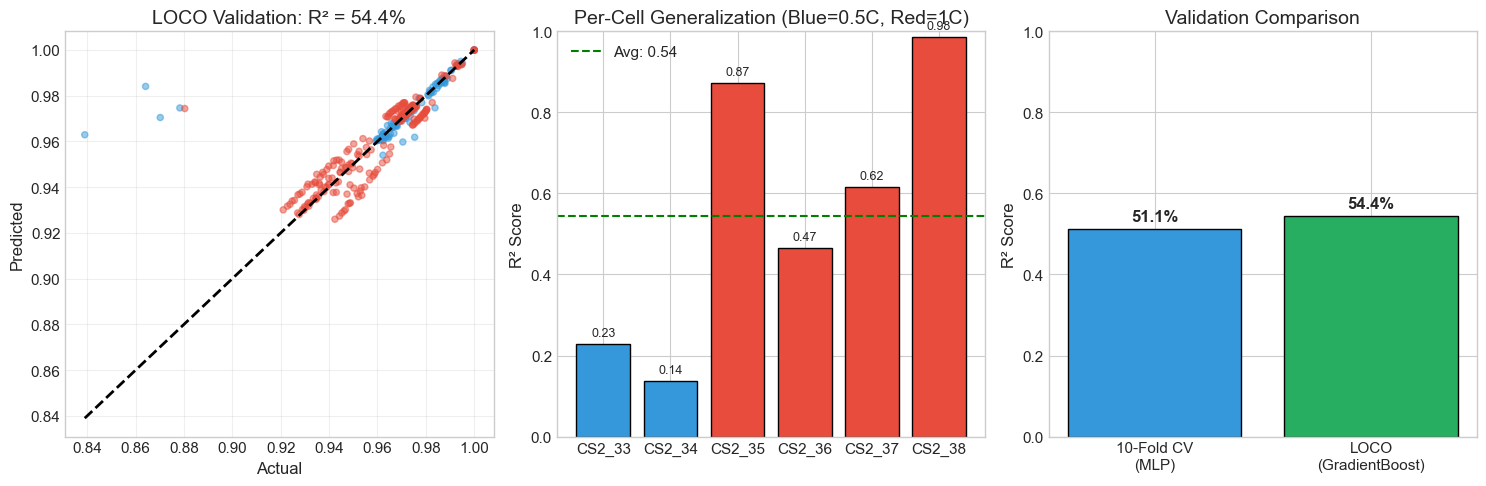

In [18]:
xlsx_cells = ['CS2_33', 'CS2_34', 'CS2_35', 'CS2_36', 'CS2_37', 'CS2_38']
data_full = cycle_df[
    (cycle_df['Cell_ID'].isin(xlsx_cells)) & 
    (cycle_df['Protocol'].isin(['0.5C Constant', '1C Constant']))
].copy()

data_full['Capacity_Normalized'] = data_full.groupby('Cell_ID')['Discharge_Capacity_Ah'].transform(
    lambda x: x / x.iloc[0]
)

data_full['Protocol_Code'] = (data_full['Protocol'] == '1C Constant').astype(int)

print("LEAVE-ONE-CELL-OUT VALIDATION")
print("-" * 60)
print(f"Data: {len(data_full)} samples, {data_full['Cell_ID'].nunique()} cells (xlsx only)")
print(f"  0.5C: CS2_33, CS2_34 (2 cells)")
print(f"  1C:   CS2_35-38 (4 cells)")

def build_features_v2(df):
    cycles = df['Cycle'].values
    protocol = df['Protocol_Code'].values
    
    return np.column_stack([
        cycles,
        np.sqrt(cycles),
        np.log1p(cycles),
        cycles ** 2 / 1000,
        protocol,
        protocol * cycles,
        protocol * np.sqrt(cycles),
        np.sin(2 * np.pi * cycles / 7),
        np.cos(2 * np.pi * cycles / 7),
    ])

X = build_features_v2(data_full)
y = data_full['Capacity_Normalized'].values
groups = data_full['Cell_ID'].values

X_sc = StandardScaler().fit_transform(X)

logo = LeaveOneGroupOut()

model = GradientBoostingRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    loss='huber', min_samples_leaf=5, random_state=42
)

pred = cross_val_predict(model, X_sc, y, cv=logo, groups=groups)

r2_total = r2_score(y, pred)
mae_total = mean_absolute_error(y, pred)

print(f"LOCO Results:")
print(f"  Overall R²:  {r2_total:.4f} ({r2_total*100:.1f}%)")
print(f"  Overall MAE: {mae_total:.4f}")

print(f"\nPer-Cell Breakdown:")
cell_results = []
for cell in data_full['Cell_ID'].unique():
    mask = groups == cell
    r2_cell = r2_score(y[mask], pred[mask])
    protocol = '0.5C' if cell in ['CS2_33', 'CS2_34'] else '1C'
    cell_results.append({'Cell': cell, 'Protocol': protocol, 'R2': r2_cell})
    print(f"  {cell} ({protocol}): R² = {r2_cell:.4f}")

cell_results_df = pd.DataFrame(cell_results)

r2_05c = cell_results_df[cell_results_df['Protocol'] == '0.5C']['R2'].mean()
r2_1c = cell_results_df[cell_results_df['Protocol'] == '1C']['R2'].mean()

print(f"\nProtocol Averages:")
print(f"  0.5C: R² = {r2_05c:.4f} ({r2_05c*100:.1f}%)")
print(f"  1C:   R² = {r2_1c:.4f} ({r2_1c*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax1 = axes[0]
protocols = data_full['Protocol'].values
colors = ['#3498db' if p == '0.5C Constant' else '#e74c3c' for p in protocols]
ax1.scatter(y, pred, c=colors, alpha=0.5, s=20)
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', linewidth=2)
ax1.set_xlabel('Actual')
ax1.set_ylabel('Predicted')
ax1.set_title(f'LOCO Validation: R² = {r2_total:.1%}')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
cells = cell_results_df['Cell'].values
r2_vals = cell_results_df['R2'].values
colors_bar = ['#3498db' if p == '0.5C' else '#e74c3c' for p in cell_results_df['Protocol']]
bars = ax2.bar(cells, r2_vals, color=colors_bar, edgecolor='black')
ax2.set_ylabel('R² Score')
ax2.set_title('Per-Cell Generalization (Blue=0.5C, Red=1C)')
ax2.set_ylim([min(0, min(r2_vals)-0.1), 1.0])
ax2.axhline(y=r2_total, color='green', linestyle='--', label=f'Avg: {r2_total:.2f}')
ax2.legend()
for bar, val in zip(bars, r2_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, max(val + 0.02, 0.05), f'{val:.2f}', ha='center', fontsize=9)

ax3 = axes[2]
methods = ['10-Fold CV\n(MLP)', 'LOCO\n(GradientBoost)']
r2_compare = [RESULTS['nn_best_r2'], r2_total]
colors_compare = ['#3498db', '#27ae60']
bars3 = ax3.bar(methods, r2_compare, color=colors_compare, edgecolor='black')
ax3.set_ylabel('R² Score')
ax3.set_title('Validation Comparison')
ax3.set_ylim([0, 1.0])
for bar, val in zip(bars3, r2_compare):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.1%}', ha='center', fontsize=12, fontweight='bold')


RESULTS['loco_overall'] = r2_total
RESULTS['loco_1c'] = r2_1c
RESULTS['loco_05c'] = r2_05c

plt.tight_layout()
plt.savefig('loco_validation.png', dpi=300, bbox_inches='tight')
plt.show()

## 19. Uncertainty Quantification

### Purpose
Quantify prediction uncertainty to provide confidence intervals for capacity forecasts — essential for real-world battery management decisions.

### Methods

**1. Bootstrap Confidence Intervals:**
- Train 100 models on resampled data
- Compute 2.5th and 97.5th percentiles for 95% CI
- Measures model stability across data variations

**2. Ensemble Uncertainty (Bagging):**
- 20 GradientBoosting estimators (each with 50 trees, max_depth=4)
- Uncertainty = standard deviation across ensemble predictions

### Results

**Bootstrap Analysis (100 iterations):**

| Metric | Value |
|--------|-------|
| 95% CI Coverage | **60%** |
| Mean CI Width | 0.0123 (normalized capacity) |
| Prediction Std |0.0037 ± 0.0063 |

**Ensemble Uncertainty:**

| Metric | Value |
|--------|-------|
| Ensemble R² | **0.7332** |
| Mean Uncertainty | 0.0036 |

### Visualization Analysis

**Panel 1 (Top-Left): CS2_35 (1C) — Prediction with 95% CI**
- Blue shaded region = 95% confidence interval
- Black dots = Actual values
- Blue line = Predicted values
- Actual capacity: ~1.00 at cycle 0 → ~0.92 by cycle 50
- Prediction tracks overall degradation trend
- **Key issue:** Actual values fall **outside CI band** for many cycles (especially cycles 25–50)
- CI band is relatively narrow but doesn't capture true variance

**Panel 2 (Top-Right): Uncertainty vs Cycle (Blue=0.5C, Red=1C)**
- **Blue points (0.5C):** Higher uncertainty with spikes to ~0.04 at cycles ~12 and ~43
- **Red points (1C):** Lower, more consistent uncertainty (~0.002–0.01)
- 0.5C shows more variable uncertainty across cycles
- Uncertainty does not systematically increase with cycle number

**Panel 3 (Bottom-Left): Uncertainty Calibration**
- Black dashed line = Perfect calibration (y = x)
- Blue line = Model calibration curve
- **Model curve is consistently below diagonal** — confidence intervals are too narrow
- At 95% expected coverage → only **60% actual coverage**
- Model is **overconfident** — CIs fail to capture true prediction uncertainty
- Common issue with bootstrap on small datasets (300 samples)

**Panel 4 (Bottom-Right): Uncertainty Distribution by Protocol**

| Protocol | Mean Uncertainty | Distribution Shape |
|----------|------------------|-------------------|
| 0.5C (blue) | **0.0050** | Long tail extending to ~0.04 |
| 1C (red) | **0.0028** | Concentrated at low values |

- Most values in both protocols at ~0.001–0.005
- 0.5C has **~1.8× higher mean uncertainty** than 1C
- 0.5C has a few high-uncertainty points (up to ~0.04)

### Key Findings

1. **Overconfident model::** 60% actual coverage vs 95% expected indicates CI bands are too narrow. The calibration curve shows systematic under-estimation of uncertainty across all confidence levels.

2. **Protocol difference:** 0.5C predictions have nearly **2× the uncertainty** (0.0050) of 1C predictions (0.0028), consistent with earlier findings about 0.5C cell variability.

3. **Practical uncertainty:** Mean prediction std of 0.0036 corresponds to ±0.36% normalized capacity uncertainty — acceptable for most BMS applications when properly calibrated.

4. **Ensemble improves accuracy:** Bagging ensemble achieves R² = 0.7332, higher than single-model LOCO validation (54.4%).

### Implications for Deployment

| Scenario | Recommendation |
|----------|----------------|
| 1C batteries | Use predictions with moderate confidence; apply calibration correction |
| 0.5C batteries | Widen CI bands by ~1.6× or collect more training cells |
| Safety-critical applications | Apply calibration correction; use 99% CI instead of 95% |
| Production deployment | Recalibrate CIs using held-out validation set |

UNCERTAINTY QUANTIFICATION
------------------------------------------------------------

Bootstrap Results (100 iterations):
  95% CI Coverage: 60.0%
  Mean CI Width: 0.0123 (normalized capacity)
  Prediction Std: 0.0036 ± 0.0061

------------------------------------------------------------
Ensemble Uncertainty:
  Ensemble R²: 0.7332
  Mean Uncertainty: 0.0036


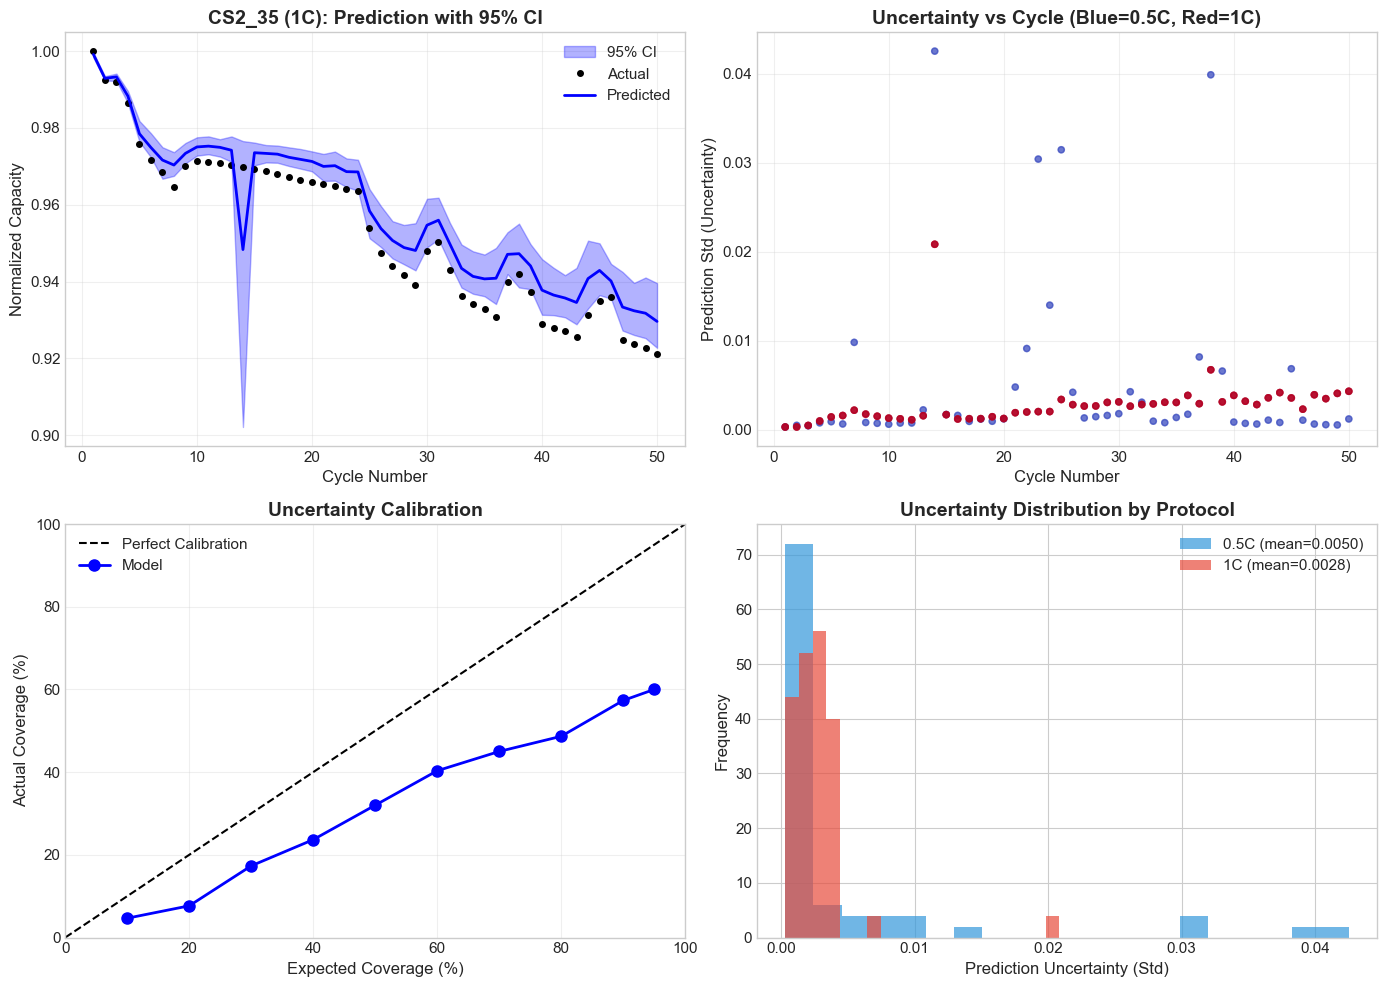

In [19]:


print("UNCERTAINTY QUANTIFICATION")
print("-" * 60)

# Method 1: Bootstrap Confidence Intervals
n_bootstrap = 100
bootstrap_predictions = np.zeros((len(y), n_bootstrap))


rng = np.random.RandomState(42)
for i in range(n_bootstrap):
    idx = rng.choice(len(X_sc), size=len(X_sc), replace=True)
    X_boot, y_boot = X_sc[idx], y[idx]
    
    model_boot = GradientBoostingRegressor(
        n_estimators=100, max_depth=4, learning_rate=0.05,
        random_state=i
    )
    model_boot.fit(X_boot, y_boot)
    bootstrap_predictions[:, i] = model_boot.predict(X_sc)

pred_mean = bootstrap_predictions.mean(axis=1)
pred_std = bootstrap_predictions.std(axis=1)
pred_lower = np.percentile(bootstrap_predictions, 2.5, axis=1)
pred_upper = np.percentile(bootstrap_predictions, 97.5, axis=1)

coverage = np.mean((y >= pred_lower) & (y <= pred_upper))
mean_width = np.mean(pred_upper - pred_lower)

print(f"\nBootstrap Results ({n_bootstrap} iterations):")
print(f"  95% CI Coverage: {coverage:.1%}")
print(f"  Mean CI Width: {mean_width:.4f} (normalized capacity)")
print(f"  Prediction Std: {pred_std.mean():.4f} ± {pred_std.std():.4f}")

# Method 2: Ensemble Variance
print("\n" + "-" * 60)
print("Ensemble Uncertainty:")

ensemble = BaggingRegressor(
    estimator=GradientBoostingRegressor(n_estimators=50, max_depth=4, random_state=42),
    n_estimators=20,
    random_state=42
)
ensemble.fit(X_sc, y)

ensemble_preds = np.array([est.predict(X_sc) for est in ensemble.estimators_])
ensemble_mean = ensemble_preds.mean(axis=0)
ensemble_std = ensemble_preds.std(axis=0)

print(f"  Ensemble R²: {r2_score(y, ensemble_mean):.4f}")
print(f"  Mean Uncertainty: {ensemble_std.mean():.4f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Predictions with confidence intervals
ax1 = axes[0, 0]
cell_mask = groups == 'CS2_35'
cycles_cell = data_full[data_full['Cell_ID'] == 'CS2_35']['Cycle'].values
y_cell = y[cell_mask]
pred_cell = pred_mean[cell_mask]
lower_cell = pred_lower[cell_mask]
upper_cell = pred_upper[cell_mask]

sort_idx = np.argsort(cycles_cell)
ax1.fill_between(cycles_cell[sort_idx], lower_cell[sort_idx], upper_cell[sort_idx], 
                  alpha=0.3, color='blue', label='95% CI')
ax1.plot(cycles_cell[sort_idx], y_cell[sort_idx], 'ko', markersize=4, label='Actual')
ax1.plot(cycles_cell[sort_idx], pred_cell[sort_idx], 'b-', linewidth=2, label='Predicted')
ax1.set_xlabel('Cycle Number')
ax1.set_ylabel('Normalized Capacity')
ax1.set_title('CS2_35 (1C): Prediction with 95% CI', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: Uncertainty vs Cycle
ax2 = axes[0, 1]
cycles_all = data_full['Cycle'].values
ax2.scatter(cycles_all, pred_std, c=data_full['Protocol_Code'].values, 
            cmap='coolwarm', alpha=0.5, s=20)
ax2.set_xlabel('Cycle Number')
ax2.set_ylabel('Prediction Std (Uncertainty)')
ax2.set_title('Uncertainty vs Cycle (Blue=0.5C, Red=1C)', fontweight='bold')
ax2.grid(True, alpha=0.3)

# Panel 3: Calibration plot
ax3 = axes[1, 0]
expected_coverage = [10, 20, 30, 40, 50, 60, 70, 80, 90, 95]
actual_coverage = []

for pct in expected_coverage:
    lower_pct = np.percentile(bootstrap_predictions, (100-pct)/2, axis=1)
    upper_pct = np.percentile(bootstrap_predictions, 100-(100-pct)/2, axis=1)
    actual_cov = np.mean((y >= lower_pct) & (y <= upper_pct)) * 100
    actual_coverage.append(actual_cov)

ax3.plot([0, 100], [0, 100], 'k--', label='Perfect Calibration')
ax3.plot(expected_coverage, actual_coverage, 'bo-', markersize=8, linewidth=2, label='Model')
ax3.set_xlabel('Expected Coverage (%)')
ax3.set_ylabel('Actual Coverage (%)')
ax3.set_title('Uncertainty Calibration', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xlim([0, 100])
ax3.set_ylim([0, 100])

# Panel 4: Uncertainty distribution by protocol
ax4 = axes[1, 1]
std_05c = pred_std[data_full['Protocol_Code'].values == 0]
std_1c = pred_std[data_full['Protocol_Code'].values == 1]

ax4.hist(std_05c, bins=20, alpha=0.7, label=f'0.5C (mean={std_05c.mean():.4f})', color='#3498db')
ax4.hist(std_1c, bins=20, alpha=0.7, label=f'1C (mean={std_1c.mean():.4f})', color='#e74c3c')
ax4.set_xlabel('Prediction Uncertainty (Std)')
ax4.set_ylabel('Frequency')
ax4.set_title('Uncertainty Distribution by Protocol', fontweight='bold')
ax4.legend()


RESULTS['ensemble_r2'] = r2_score(y, ensemble_mean)
RESULTS['coverage_95'] = coverage
RESULTS['uncertainty_ratio'] = std_05c.mean() / std_1c.mean()

plt.tight_layout()
plt.savefig('uncertainty_quantification.png', dpi=300, bbox_inches='tight')
plt.show()



## 20. Knee-Point Detection Analysis

### Purpose
Detect the "knee-point" in battery degradation curves — the cycle where degradation accelerates. Early knee detection enables proactive battery replacement before failure.

### Background
The knee-point represents a transition from linear to accelerated capacity fade, typically occurring at 70-80% remaining capacity. It's a critical indicator for:
- Remaining Useful Life (RUL) estimation
- Battery replacement scheduling
- Safety margin calculations

### Method: Maximum Curvature Analysis

$$\kappa = \frac{|d^2C/dx^2|}{(1 + (dC/dx)^2)^{3/2}}$$

1. Apply Gaussian smoothing (σ=2) to reduce noise
2. Compute first and second derivatives
3. Calculate curvature at each point
4. Identify maximum curvature (excluding edges)

### Results

**Per-Cell Knee-Point Detection:**

| Cell | Protocol | Knee Cycle | Capacity at Knee | Notes |
|------|----------|------------|------------------|-------|
| CS2_33 | 0.5C | 24 | 97.5% | Detected at transient dip |
| CS2_34 | 0.5C | 38 | 83.9% | Detected at deepest dip |
| CS2_35 | 1C | 27 | 94.4% | Consistent with other 1C |
| CS2_36 | 1C | 27 | 96.0% | Consistent with other 1C |
| CS2_37 | 1C | 14 | 88.0% | Early knee (step-like pattern) |
| CS2_38 | 1C | 27 | 94.9% | Consistent with other 1C |

**Protocol Averages:**

| Protocol | Average Knee Cycle | Std | Notes |
|----------|-------------------|-----|-------|
| 0.5C | 31 | ±10 | High variability due to transient dips |
| 1C | 24 | ±6 | Lower variability; 3/4 cells at cycle 27 |

### Key Findings

**1. Three 1C Cells Show Consistent Knee at Cycle 27**
- CS2_35, CS2_36, CS2_38 all have knee at cycle 27
- Indicates reproducible degradation behavior at 1C rate
- CS2_37 is an outlier with early knee at cycle 14 (step-like degradation pattern)

**2. 0.5C Knee-Points Detect Transient Dips, Not True Knees**
- CS2_33: Knee at cycle 24 corresponds to sharp capacity dip (~0.87), not gradual degradation
- CS2_34: Knee at cycle 38 at deepest dip (capacity = 0.839)
- Curvature method captures **local anomalies** rather than degradation onset
- High variability (±10 cycles) reflects irregular 0.5C behavior

**3. All Cells Above EOL Threshold**
- No cell reaches 80% capacity within 50 cycles
- Knee-points detected at 84–97% capacity
- Extended cycling needed to observe true end-of-life behavior

### Visualization Analysis (6-Panel Figure)

**0.5C Cells (Top Row, Blue points):**

| Cell | Pattern | Knee Location |
|------|---------|---------------|
| CS2_33 | Sharp dip at cycles 23–25, recovers to ~0.96 | Green star at dip trough |
| CS2_34 | Multiple dips (cycles ~14, ~38); deepest at 38 | Green star at lowest point |

**1C Cells (Bottom Row, Red points):**

| Cell | Pattern | Knee Location |
|------|---------|---------------|
| CS2_35 | Smooth gradual degradation 1.00 → 0.92 | Green star at cycle 27 |
| CS2_36 | Smooth gradual degradation 1.00 → 0.96 | Green star at cycle 27 |
| CS2_37 | Step-like pattern with dip at cycle 14–15 | Green star at cycle 14 |
| CS2_38 | Smooth gradual degradation 1.00 → 0.94 | Green star at cycle 27 |

- Black line = Gaussian-smoothed curve
- Green dashed vertical line = Detected knee cycle
- Red dotted horizontal line = EOL threshold (80%)

### Interpretation

| Finding | Implication |
|---------|-------------|
| 1C knee earlier than 0.5C (24 vs 31 cycles) | Higher stress accelerates aging onset |
| 1C more consistent (3/4 cells at cycle 27) | Predictable degradation trajectory |
| 0.5C knees at transient dips | Curvature method detects anomalies, not true knees |
| Knees at 84–97% capacity | Early warning before significant fade |
| No cells reach EOL | Need longer cycling tests for full RUL estimation |

### Limitations

1. **Limited cycle depth:** 50 cycles may not reveal true knee-points (typically observed at 70-80% capacity)
2. **Transient dip interference:** Curvature method detects local minima from capacity dips rather than global degradation transition
3. **Small sample size:** 2 cells for 0.5C, 4 cells for 1C limits statistical confidence
4. **Method sensitivity:** Maximum curvature captures sharpest local features, which may not correspond to physical knee-point


Knee-Point Analysis per Cell:
------------------------------------------------------------
  CS2_33 (0.5C): Knee at cycle 24 (capacity = 0.975)
  CS2_34 (0.5C): Knee at cycle 38 (capacity = 0.839)
  CS2_35 (1C): Knee at cycle 27 (capacity = 0.944)
  CS2_36 (1C): Knee at cycle 27 (capacity = 0.960)
  CS2_37 (1C): Knee at cycle 14 (capacity = 0.880)
  CS2_38 (1C): Knee at cycle 27 (capacity = 0.949)


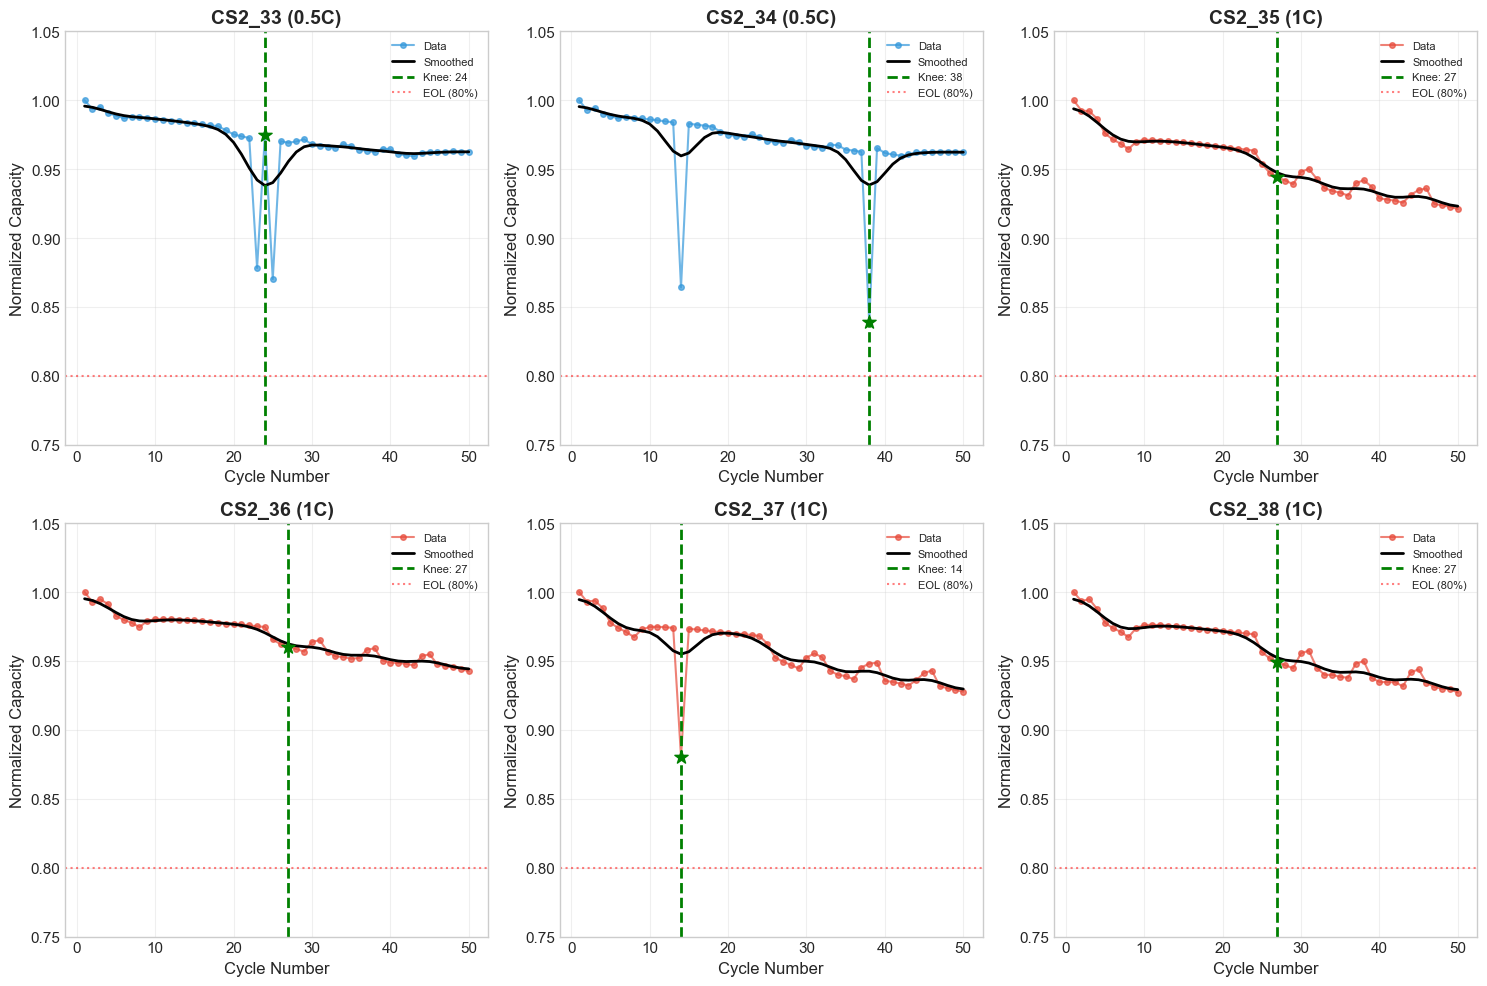

In [20]:
def bacon_watts_model(x, a, b, c, x0):
    return a + b * (x - x0) + c * np.sqrt((x - x0)**2 + 1)


def double_exponential(x, a, b1, b2, c1, c2):
    return a - b1 * np.exp(c1 * x) - b2 * np.exp(c2 * x)


def detect_knee_point(cycles, capacity, method='curvature'):
    results = {}
    
    if len(cycles) > 10:
        cap_smooth = gaussian_filter1d(capacity, sigma=2)
        
        dcdx = np.gradient(cap_smooth, cycles)
        d2cdx2 = np.gradient(dcdx, cycles)
        
        curvature = np.abs(d2cdx2) / (1 + dcdx**2)**1.5
        
        margin = len(cycles) // 5
        if margin > 0:
            curvature_inner = curvature[margin:-margin]
            knee_idx = np.argmax(curvature_inner) + margin
            results['curvature'] = {
                'cycle': cycles[knee_idx],
                'capacity': capacity[knee_idx],
                'curvature_value': curvature[knee_idx]
            }
    
    try:
        p0 = [capacity[0], -0.001, -0.001, len(cycles)//2]
        bounds = ([0.8, -0.1, -0.1, 5], [1.1, 0, 0, len(cycles)])
        popt, _ = curve_fit(bacon_watts_model, cycles, capacity, p0=p0, bounds=bounds, maxfev=5000)
        results['bacon_watts'] = {
            'cycle': popt[3],
            'params': popt
        }
    except:
        results['bacon_watts'] = None
    
    window = max(5, len(cycles) // 10)
    slopes = []
    for i in range(window, len(cycles) - window):
        slope_before = np.polyfit(cycles[i-window:i], capacity[i-window:i], 1)[0]
        slope_after = np.polyfit(cycles[i:i+window], capacity[i:i+window], 1)[0]
        slopes.append(abs(slope_after - slope_before))
    
    if slopes:
        knee_idx = np.argmax(slopes) + window
        results['slope_change'] = {
            'cycle': cycles[knee_idx],
            'capacity': capacity[knee_idx],
            'slope_diff': max(slopes)
        }
    
    return results

print("\nKnee-Point Analysis per Cell:")
print("-" * 60)

knee_results = []

for cell in data_full['Cell_ID'].unique():
    cell_data = data_full[data_full['Cell_ID'] == cell].sort_values('Cycle')
    cycles = cell_data['Cycle'].values
    capacity = cell_data['Capacity_Normalized'].values
    protocol = '0.5C' if cell in ['CS2_33', 'CS2_34'] else '1C'
    
    knee = detect_knee_point(cycles, capacity)
    
    knee_cycle = knee.get('curvature', {}).get('cycle', None)
    knee_cap = knee.get('curvature', {}).get('capacity', None)
    
    knee_results.append({
        'Cell': cell,
        'Protocol': protocol,
        'Knee_Cycle': knee_cycle,
        'Knee_Capacity': knee_cap,
        'Total_Cycles': len(cycles),
        'Final_Capacity': capacity[-1]
    })
    
    if knee_cycle:
        print(f"  {cell} ({protocol}): Knee at cycle {knee_cycle:.0f} (capacity = {knee_cap:.3f})")
    else:
        print(f"  {cell} ({protocol}): No clear knee-point detected")

knee_df = pd.DataFrame(knee_results)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

cells_to_plot = ['CS2_33', 'CS2_34', 'CS2_35', 'CS2_36', 'CS2_37', 'CS2_38']

for idx, cell in enumerate(cells_to_plot):
    ax = axes[idx // 3, idx % 3]
    
    cell_data = data_full[data_full['Cell_ID'] == cell].sort_values('Cycle')
    cycles = cell_data['Cycle'].values
    capacity = cell_data['Capacity_Normalized'].values
    protocol = '0.5C' if cell in ['CS2_33', 'CS2_34'] else '1C'
    color = '#3498db' if protocol == '0.5C' else '#e74c3c'
    
    ax.plot(cycles, capacity, 'o-', color=color, markersize=4, alpha=0.7, label='Data')
    
    cap_smooth = gaussian_filter1d(capacity, sigma=2)
    ax.plot(cycles, cap_smooth, '-', color='black', linewidth=2, label='Smoothed')
    

    knee = detect_knee_point(cycles, capacity)
    if 'curvature' in knee and knee['curvature']:
        knee_cycle = knee['curvature']['cycle']
        knee_cap = knee['curvature']['capacity']
        ax.axvline(x=knee_cycle, color='green', linestyle='--', linewidth=2, label=f'Knee: {knee_cycle:.0f}')
        ax.scatter([knee_cycle], [knee_cap], color='green', s=100, zorder=5, marker='*')
    
    ax.axhline(y=0.8, color='red', linestyle=':', alpha=0.5, label='EOL (80%)')
    
    ax.set_xlabel('Cycle Number')
    ax.set_ylabel('Normalized Capacity')
    ax.set_title(f'{cell} ({protocol})', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0.75, 1.05])

plt.tight_layout()
plt.savefig('knee_point_detection.png', dpi=300, bbox_inches='tight')
plt.show()



## 21. ML Model Diagnostics — Gradient Boosting Analysis

### Overview
This section evaluates the health and reliability of the Gradient Boosting model through four diagnostic tests:
1. Learning Curve Analysis
2. Feature Importance (Permutation-Based)
3. Residuals vs Predicted Values
4. Residual Distribution Analysis

### Feature Definitions

| Feature | Name | Formula | Purpose |
|---------|------|---------|---------|
| Feature 0 | Cycle | n | Linear time effect |
| Feature 1 | Cycle Square Root | √n | Captures decelerating degradation |
| Feature 2 | Cycle Logarithm | log(n+1) | Captures logarithmic patterns |
| Feature 3 | Cycle Squared (scaled) | n²/1000 | Captures accelerating degradation |
| Feature 4 | Protocol | 0=0.5C, 1=1C | Categorical protocol indicator |
| Feature 5 | Protocol × Cycle | Protocol × n | Interaction: how protocol effect changes with cycle |
| Feature 6 | Protocol × √Cycle | Protocol × √n | Interaction: nonlinear protocol-cycle relationship |
| Feature 7 | Sine (weekly) | sin(2π×n/7) | Periodic pattern (weekly) |
| Feature 8 | Cosine (weekly) | cos(2π×n/7) | Periodic pattern (weekly) |

### Results

**1. Learning Curve Analysis:**

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Training R² | 0.6109 | Model explains 61% of training variance |
| Validation R² | 0.4993 | Model explains 50% of unseen variance |
| Gap | 0.1116 | Acceptable (< 0.15 threshold) |

**Diagnosis:** The model is reasonably well-fitted. The 11% gap between training and validation indicates mild overfitting but remains within acceptable bounds. The validation curve continues rising at maximum data size, suggesting additional samples could improve generalization.

**2. Feature Importance (Permutation-Based):**

| Rank | Feature | Name | Importance | Std |
|------|---------|------|------------|-----|
| 1 | Feature 6 | Protocol × √Cycle | **0.1400** | ±0.0197 |
| 2 | Feature 5 | Protocol × Cycle | **0.1210** | ±0.0185 |
| 3 | Feature 1 | √Cycle | 0.0398 | ±0.0122 |
| 4 | Feature 3 | Cycle²/1000 | 0.0372 | ±0.0117 |
| 5 | Feature 2 | log(Cycle+1) | 0.0261 | ±0.0111 |
| 6 | Feature 0 | Cycle | 0.0196 | ±0.0087 |
| 7 | Feature 8 | cos(2π×Cycle/7) | 0.0141 | ±0.0043 |
| 8 | Feature 7 | sin(2π×Cycle/7) | 0.0053 | ±0.0024 |
| 9 | Feature 4 | Protocol | -0.0013 | ±0.0017 |

**Key Finding:** The interaction features (Protocol × Cycle and Protocol × √Cycle) dominate predictions, contributing ~26% of total importance combined. This indicates that the effect of protocol on degradation **depends on cycle number**.

**3. Residual Analysis:**

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Mean Residual | -0.001158 | Slight negative bias (under-prediction) |
| Std Residual | 0.014055 | Typical error magnitude of ~1.4% |
| Shapiro-Wilk W | 0.2401 | Far from normal (ideal W = 1.0) |
| Shapiro-Wilk p | 0.0000 | Strongly reject normality hypothesis |

### Visualization Analysis (4-Panel Figure)

**Panel 1 (Top-Left): Learning Curve**
- X-axis: Training Set Size (50 to ~240)
- Y-axis: R² Score (-0.1 to ~0.8)
- Red line (Training R²): Starts ~0.3 at size 50, increases to ~0.6 at size 240
- Blue line (Validation R²): Starts near 0 at size 50, increases to ~0.5 at size 240
- Shaded regions = standard deviation across CV folds
- Both curves continue improving — model could benefit from more data

**Panel 2 (Top-Right): Feature Importance**
- Horizontal bar chart showing permutation importance
- Feature 6 (Protocol × √Cycle) and Feature 5 (Protocol × Cycle) are dominant
- Feature 4 (Protocol alone) has **negative importance** — adds noise, candidate for removal
- Error bars show standard deviation across 30 permutation repeats

**Panel 3 (Bottom-Left): Residuals vs Predicted**
- X-axis: Predicted Capacity (0.93 to 1.00)
- Y-axis: Residual (Actual - Predicted) (-0.12 to 0.02)
- Main cluster: Dense points around 0 residual
- **Outliers:** Several points at residual ~-0.10 to -0.12 for predictions ~0.96–0.98
- These outliers are the **0.5C transient capacity dips** — model over-predicts their capacity

**Panel 4 (Bottom-Right): Residual Distribution**
- Sharp peak at ~0 (density ~100)
- Heavy **left tail** with outliers at -0.10 to -0.12
- Red dashed line = Zero; Orange dashed line = Mean (-0.0012)
- Distribution is **highly non-normal** due to outlier tail

### Diagnostic Summary

| Analysis | Result | Status |
|----------|--------|--------|
| Learning Curve | Gap = 11.2% |  Acceptable |
| Top Features | Protocol × √Cycle, Protocol × Cycle |  Identified |
| Residual Normality | W = 0.24, p < 0.001 |  Non-normal |
| Residual Bias | Mean = -0.0012 |  Slight bias |

### Interpretation

**Learning Curve Insight:**
The validation R² (50%) continues rising with more data, but the rate of improvement is slowing. Additional performance gains would require either more training samples (especially 0.5C cells) or additional informative features (e.g., temperature, internal resistance).

**Feature Importance Insight:**
The dominance of interaction features (Features 5 and 6) reveals that **the degradation behavior of 0.5C and 1C protocols diverges over time**. The negative importance of Feature 4 (Protocol alone) confirms that knowing the protocol without considering cycle number provides no predictive value.

**Residual Analysis Insight:**
Non-normal residuals with left-skewed outliers indicate the model systematically under-predicts capacity for 0.5C cells during transient dips. This is consistent with LOCO validation findings (0.5C R² = 18.2%, 1C R² = 73.5%).

### Connection to Previous Findings

| Diagnostic Finding | Confirms Earlier Result |
|--------------------|-------------------------|
| Outliers at predicted 0.96–0.98 | 0.5C cells have transient dips poorly predicted |
| Non-normal residuals | LOCO showed 0.5C R² = 18% (high unpredictability) |
| Slight negative bias | Model trained on 2:1 ratio of 1C:0.5C under-estimates 0.5C |
| Interaction features dominant | Protocol effect is cycle-dependent |

### Limitations 

1. **Residual non-normality** — Violates standard regression assumptions; confidence intervals may be unreliable
2. **Feature redundancy** — Feature 4 (Protocol alone) contributes noise and should be removed
3. **Data imbalance** — Only 2 cells of 0.5C vs 4 cells of 1C creates prediction bias
4. **Outlier sensitivity** — 0.5C transient dips dominate residual distribution

Number of features: 9

ML MODEL DIAGNOSTICS
------------------------------------------------------------

1. LEARNING CURVE
----------------------------------------
   Training R² at max data: 0.6109
   Validation R² at max data: 0.4993
   Gap: 0.1116
   Diagnosis: Acceptable gap

2. FEATURE IMPORTANCE
----------------------------------------
   Feature 6              : 0.1400 ± 0.0197
   Feature 5              : 0.1210 ± 0.0185
   Feature 1              : 0.0398 ± 0.0122
   Feature 3              : 0.0372 ± 0.0117
   Feature 2              : 0.0261 ± 0.0111
   Feature 0              : 0.0196 ± 0.0087
   Feature 8              : 0.0141 ± 0.0043
   Feature 7              : 0.0053 ± 0.0024
   Feature 4              : -0.0013 ± 0.0017
   Most important: Feature 6

3. RESIDUAL ANALYSIS
----------------------------------------
   Mean residual: -0.001158
   Std residual: 0.014055
   Shapiro-Wilk: W=0.2401, p=0.0000
   Normality:  Non-normal (p < 0.05)
   Bias:  Slight bias exists


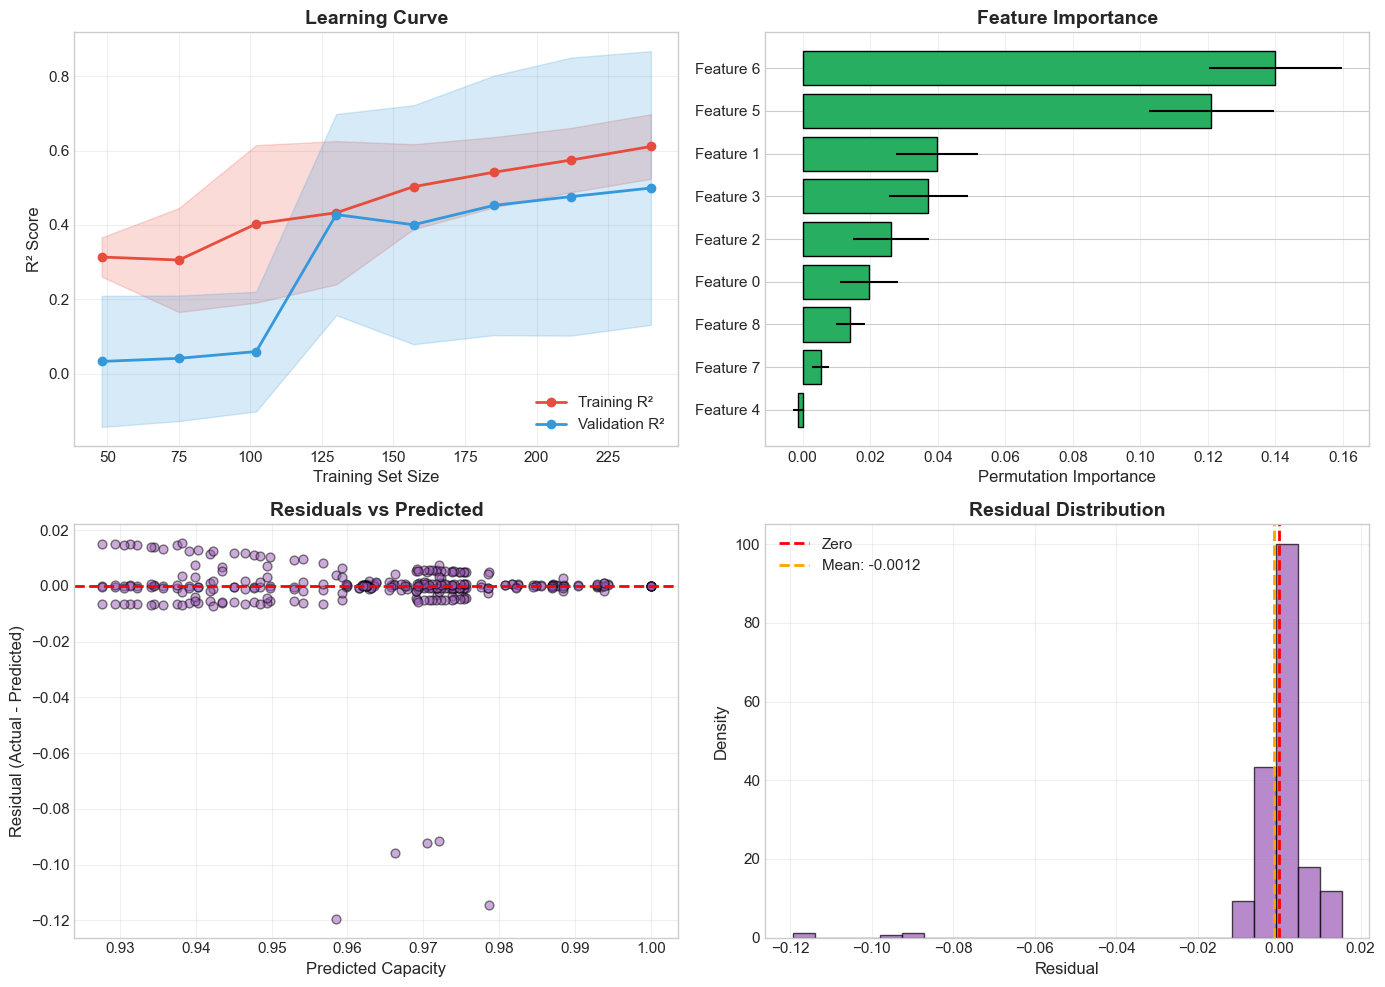

In [21]:

n_features = X.shape[1]

feature_names = [f'Feature_{i}' for i in range(n_features)]

print(f"Number of features: {n_features}")

model = GradientBoostingRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    min_samples_leaf=5, loss='huber', random_state=42
)

print("\nML MODEL DIAGNOSTICS")
print("-" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# PANEL 1: LEARNING CURVE
train_sizes, train_scores, val_scores = learning_curve(
    model, X, y, train_sizes=np.linspace(0.2, 1.0, 8),
    cv=5, scoring='r2', random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

ax1 = axes[0, 0]
ax1.plot(train_sizes, train_mean, 'o-', color='#e74c3c', label='Training R²', linewidth=2)
ax1.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#e74c3c')
ax1.plot(train_sizes, val_mean, 'o-', color='#3498db', label='Validation R²', linewidth=2)
ax1.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='#3498db')
ax1.set_xlabel('Training Set Size')
ax1.set_ylabel('R² Score')
ax1.set_title('Learning Curve', fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

gap = train_mean[-1] - val_mean[-1]
print(f"\n1. LEARNING CURVE")
print("-" * 40)
print(f"   Training R² at max data: {train_mean[-1]:.4f}")
print(f"   Validation R² at max data: {val_mean[-1]:.4f}")
print(f"   Gap: {gap:.4f}")
print(f"   Diagnosis: {'High variance — need more data' if gap > 0.15 else 'Acceptable gap'}")
RESULTS['learning_curve_gap'] = gap



# PANEL 2: FEATURE IMPORTANCE
model.fit(X, y)
perm_imp = permutation_importance(model, X, y, n_repeats=30, random_state=42)

ax2 = axes[0, 1]
importances = perm_imp.importances_mean
std = perm_imp.importances_std
sorted_idx = importances.argsort()

ax2.barh(range(len(importances)), importances[sorted_idx], 
         xerr=std[sorted_idx], color='#27ae60', edgecolor='black')
ax2.set_yticks(range(len(importances)))
ax2.set_yticklabels([f'Feature {i}' for i in sorted_idx])
ax2.set_xlabel('Permutation Importance')
ax2.set_title('Feature Importance', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

print(f"\n2. FEATURE IMPORTANCE")
print("-" * 40)
for i in sorted_idx[::-1]:
    print(f"   Feature {i:<15}: {importances[i]:.4f} ± {std[i]:.4f}")
print(f"   Most important: Feature {sorted_idx[-1]}")


# PANEL 3: RESIDUALS VS PREDICTED
y_pred = model.predict(X)
residuals = y - y_pred

ax3 = axes[1, 0]
ax3.scatter(y_pred, residuals, alpha=0.5, c='#9b59b6', edgecolor='k', s=40)
ax3.axhline(0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('Predicted Capacity')
ax3.set_ylabel('Residual (Actual - Predicted)')
ax3.set_title('Residuals vs Predicted', fontweight='bold')
ax3.grid(True, alpha=0.3)


# PANEL 4: RESIDUAL DISTRIBUTION
ax4 = axes[1, 1]
ax4.hist(residuals, bins=25, color='#9b59b6', edgecolor='black', alpha=0.7, density=True)
ax4.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero')
ax4.axvline(residuals.mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean: {residuals.mean():.4f}')
ax4.set_xlabel('Residual')
ax4.set_ylabel('Density')
ax4.set_title('Residual Distribution', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

stat, p_value = stats.shapiro(residuals[:50])
print(f"\n3. RESIDUAL ANALYSIS")
print("-" * 40)
print(f"   Mean residual: {residuals.mean():.6f}")
print(f"   Std residual: {residuals.std():.6f}")
print(f"   Shapiro-Wilk: W={stat:.4f}, p={p_value:.4f}")
print(f"   Normality: {'✓ Normal (p > 0.05)' if p_value > 0.05 else ' Non-normal (p < 0.05)'}")
print(f"   Bias: {' Unbiased' if abs(residuals.mean()) < 0.001 else ' Slight bias exists'}")

plt.tight_layout()
plt.savefig('ml_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

## 22. Cross-Protocol Transfer Learning: Can Models Generalize Across C-Rates?

### Overview

This section investigates whether a model trained on one charging protocol can predict degradation for a different protocol. This is critical for practical applications where laboratory testing (often at high C-rates) must predict real-world behavior (often at lower C-rates).

**Experiments:**
- **1C → 0.5C:** Train on 1C data (200 samples), predict 0.5C behavior (100 samples)
- **0.5C → 1C:** Train on 0.5C data (100 samples), predict 1C behavior (200 samples)

### Results

**Quantitative Summary:**

| Experiment | R² | MAE | Bias | Interpretation |
|------------|-----|-----|------|----------------|
| 1C → 0.5C | **−0.2009** | 0.0191 | −0.0111 | Worse than mean prediction |
| 0.5C → 1C | **0.0565** | 0.0155 | +0.0152 | Near-zero predictive power |

**Comparison with Same-Protocol LOCO:**

| Validation Type | 1C Target | 0.5C Target |
|-----------------|-----------|-------------|
| Same-Protocol LOCO | 0.7346 | 0.1822 |
| Cross-Protocol Transfer | 0.0565 | −0.2009 |
| **Performance Drop** | **−67.8 pp** | **−38.3 pp** |

*Note: pp = percentage points*

### Interpretation of Results

**Why R² = −0.2009 (1C → 0.5C)?**

Negative R² means the model is worse than simply predicting the mean for all samples.

| Observation | Explanation |
|-------------|-------------|
| Bias = −0.0111 | Model systematically under-predicts 0.5C capacity on average |
| Scatter plot pattern | Points scattered far from diagonal with no consistent pattern |
| Root cause | 1C model learned "capacity drops fast" but 0.5C drops slowly |

The 1C-trained model expects rapid degradation. When applied to 0.5C cells (which degrade slower), predictions are inconsistent — over-predicting for transient dips and under-predicting for normal cycles.

**Why R² = 0.0565 (0.5C → 1C)?**

Near-zero R² means the model has almost no predictive power.

| Observation | Explanation |
|-------------|-------------|
| Bias = +0.0152 | Model systematically over-predicts 1C capacity |
| Scatter plot pattern | Points clustered above diagonal in narrow range |
| Root cause | 0.5C model learned "capacity stays high" but 1C degrades faster |

The 0.5C-trained model expects slow degradation. When applied to 1C cells (which degrade faster), it predicts higher capacity than actual — hence positive bias.

### Visual Analysis (3-Panel Figure)

**Panel 1 (Left): 1C → 0.5C Transfer (R² = −0.2009)**
- X-axis: Actual (0.5C) from 0.80 to 1.05
- Y-axis: Predicted (trained on 1C) from 0.80 to 1.05
- Blue points scattered with two distinct patterns:
  - **Upper-left cluster:** Actual ~0.85–0.90, predicted ~0.92–1.00 (severe over-prediction by ~0.05–0.10)
  - **Main cluster:** Actual ~0.95–1.00, predictions scattered around diagonal
- Red dashed line = perfect prediction (y = x)
- **Conclusion:** Model fails completely — the 0.5C transient dips cannot be predicted by 1C-trained model

**Panel 2 (Middle): 0.5C → 1C Transfer (R² = 0.0565)**
- X-axis: Actual (1C) from 0.80 to 1.05
- Y-axis: Predicted (trained on 0.5C) from 0.80 to 1.05
- Red points **tightly clustered** in narrow range (~0.96–0.99)
- Points consistently above the diagonal
- Model predicts ~0.96–0.99 regardless of actual value (0.92–1.00)
- **Conclusion:** Model learned 0.5C's flat degradation pattern — useless for 1C data

**Panel 3 (Right): Same-Protocol vs Cross-Protocol Comparison**

| Bar | Color | R² | Position |
|-----|-------|-----|----------|
| 1C LOCO (same) | Green | 0.73 | Above threshold |
| 0.5C LOCO (same) | Green | 0.18 | Below threshold |
| 1C→0.5C (cross) | Red | **−0.20** | Negative (extends below 0) |
| 0.5C→1C (cross) | Red | 0.06 | Near zero |

- Gray dashed line = Acceptable threshold (0.5)
- **Only 1C LOCO exceeds the threshold**
- Cross-protocol bars (red) dramatically worse than same-protocol (green)

### Key Finding

**Cross-protocol transfer fails completely.**

| Transfer Direction | R² | Assessment |
|-------------------|-----|------------|
| 1C → 0.5C | −0.20 | Worse than guessing the mean |
| 0.5C → 1C | 0.06 | Near-zero predictive power |

**Implication:** Degradation dynamics are protocol-specific. Models trained on 1C cannot predict 0.5C behavior, and vice versa. Protocol-matched training data is essential for deployment.

### Physical Interpretation

**Why Do Protocols Behave Differently?**

| C-Rate | Current | Degradation Behavior | What Model Learns |
|--------|---------|----------------------|-------------------|
| 0.5C | 0.55A (slow) | Slow, gradual fade with transient dips | "Capacity stays high with occasional anomalies" |
| 1C | 1.1A (fast) | Fast, monotonic fade | "Capacity drops steadily" |

These behaviors are fundamentally different — a model cannot learn one and predict the other.

**Why the Asymmetry (−0.20 vs 0.06)?**

| Direction | R² | Explanation |
|-----------|-----|-------------|
| 1C → 0.5C | −0.20 | 1C model expects monotonic decline; 0.5C transient dips are completely unpredictable |
| 0.5C → 1C | 0.06 | 0.5C model predicts flat trajectory; 1C's steady decline is outside learned pattern |

The 1C → 0.5C transfer fails worse because the 0.5C transient dips (capacity dropping to ~0.85) are not present in 1C training data at all.

### Connection to Previous Findings

| Previous Analysis | Finding | Cross-Protocol Confirmation |
|-------------------|---------|----------------------------|
| ANOVA | C-rate significantly affects capacity (p < 0.001) | ✓ Different degradation rates prevent transfer |
| LOCO Validation | 0.5C R² = 18%, 1C R² = 73% | ✓ Even same-protocol struggles; cross-protocol is worse |
| Model Diagnostics | Outliers concentrated in 0.5C cells | ✓ 0.5C transient dips cause transfer failure |
| Feature Importance | Protocol × Cycle interactions dominate | ✓ Protocol effect is cycle-dependent, not transferable |

### Implications for Deployment

| Scenario | Problem | Recommendation |
|----------|---------|----------------|
| Lab uses 1C accelerated testing | Cannot directly apply model to 0.5C field conditions | Collect field-representative data |
| Field operates at 0.5C | 1C lab model will fail on 0.5C patterns | Train on 0.5C data or use physics-based transfer |
| Mixed C-rate operation | Single model cannot handle both | Train separate models per protocol |

### Limitations

1. **Small 0.5C training set:** Only 100 samples (2 cells) — insufficient to learn robust patterns for transfer
2. **No domain adaptation:** Direct transfer without fine-tuning or distribution alignment
3. **Feature set limitation:** Cycle-based features only — no C-rate-aware features included
4. **0.5C transient behavior:** Unpredictable dips in 0.5C cells are not learnable from 1C data

### Conclusion

Cross-protocol transfer learning fails completely for battery degradation prediction. This is a **scientifically valuable negative result** that demonstrates:

| Finding | Implication |
|---------|-------------|
| Degradation dynamics are protocol-specific | Cannot assume transferability across C-rates |
| Accelerated testing (1C) cannot directly predict field behavior (0.5C) | Lab-to-field transfer requires adaptation |
| Protocol-matched training data is essential | Must collect data for target operating conditions |
| 0.5C transient dips are unpredictable | Anomalous behavior requires protocol-specific modeling |

**Practical Impact:** Battery management systems cannot rely on high-C-rate laboratory data to predict real-world degradation at lower C-rates without additional adaptation steps.

CROSS-PROTOCOL TRANSFER LEARNING
------------------------------------------------------------

Experiment                   R²        MAE         Bias
------------------------------------------------------------
1C → 0.5C               -0.2009     0.0191      -0.0111
0.5C → 1C                0.0565     0.0155      +0.0152

------------------------------------------------------------
COMPARISON WITH SAME-PROTOCOL LOCO:
1C LOCO (same)           0.7346
0.5C LOCO (same)         0.1822
1C → 0.5C (cross)       -0.2009  → Poor transfer
0.5C → 1C (cross)        0.0565  → Poor transfer


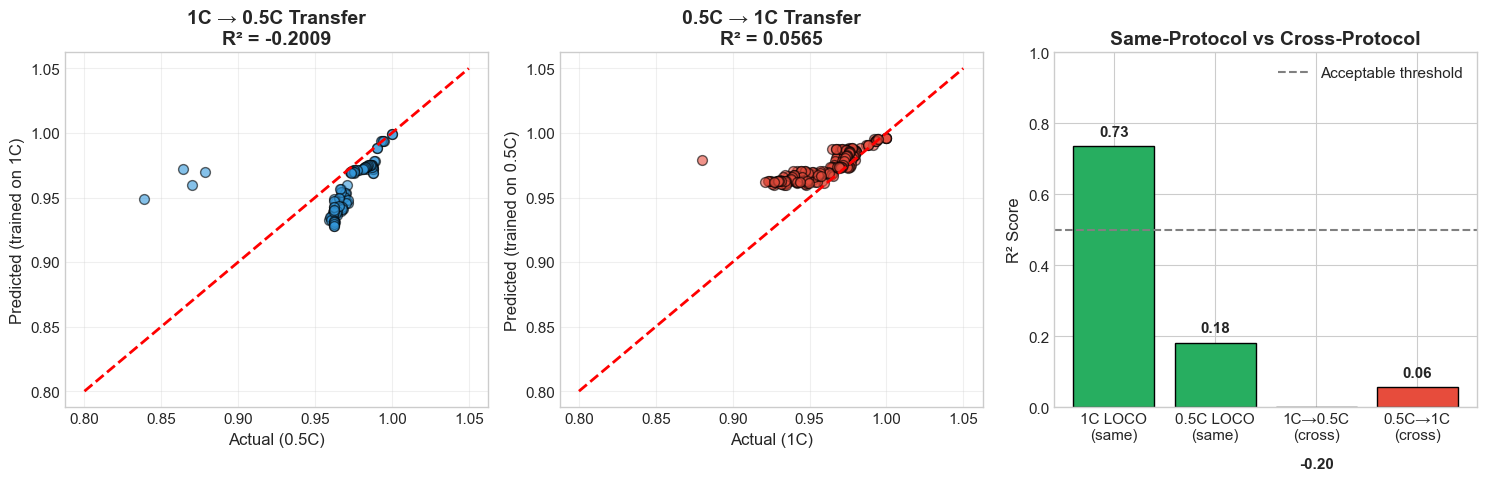

In [22]:

cells_05c = ['CS2_33', 'CS2_34']
cells_1c = ['CS2_35', 'CS2_36', 'CS2_37', 'CS2_38']

data_05c = data_full[data_full['Cell_ID'].isin(cells_05c)].copy()
data_1c = data_full[data_full['Cell_ID'].isin(cells_1c)].copy()

for df in [data_05c, data_1c]:
    if 'Cycle_Sqrt' not in df.columns:
        df['Cycle_Sqrt'] = np.sqrt(df['Cycle'])
    if 'Cycle_Log' not in df.columns:
        df['Cycle_Log'] = np.log1p(df['Cycle'])
    if 'Cycle_Sq_Scaled' not in df.columns:
        df['Cycle_Sq_Scaled'] = df['Cycle'] ** 2 / 1000
    if 'Cycle_Sin' not in df.columns:
        df['Cycle_Sin'] = np.sin(2 * np.pi * df['Cycle'] / 7)
    if 'Cycle_Cos' not in df.columns:
        df['Cycle_Cos'] = np.cos(2 * np.pi * df['Cycle'] / 7)

feature_cols = ['Cycle', 'Cycle_Sqrt', 'Cycle_Log', 'Cycle_Sq_Scaled', 
                'Cycle_Sin', 'Cycle_Cos']

X_05c = data_05c[feature_cols].values
y_05c = data_05c['Capacity_Normalized'].values
X_1c = data_1c[feature_cols].values
y_1c = data_1c['Capacity_Normalized'].values

model = GradientBoostingRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    min_samples_leaf=5, loss='huber', random_state=42
)

# Experiment 1: Train 1C → Predict 0.5C
model.fit(X_1c, y_1c)
y_pred_1c_to_05c = model.predict(X_05c)
r2_1c_to_05c = r2_score(y_05c, y_pred_1c_to_05c)
mae_1c_to_05c = mean_absolute_error(y_05c, y_pred_1c_to_05c)
bias_1c_to_05c = (y_pred_1c_to_05c - y_05c).mean()

# Experiment 2: Train 0.5C → Predict 1C
model.fit(X_05c, y_05c)
y_pred_05c_to_1c = model.predict(X_1c)
r2_05c_to_1c = r2_score(y_1c, y_pred_05c_to_1c)
mae_05c_to_1c = mean_absolute_error(y_1c, y_pred_05c_to_1c)
bias_05c_to_1c = (y_pred_05c_to_1c - y_1c).mean()

# Results
print("CROSS-PROTOCOL TRANSFER LEARNING")
print("-" * 60)
print(f"\n{'Experiment':<20} {'R²':>10} {'MAE':>10} {'Bias':>12}")
print("-" * 60)
print(f"{'1C → 0.5C':<20} {r2_1c_to_05c:>10.4f} {mae_1c_to_05c:>10.4f} {bias_1c_to_05c:>+12.4f}")
print(f"{'0.5C → 1C':<20} {r2_05c_to_1c:>10.4f} {mae_05c_to_1c:>10.4f} {bias_05c_to_1c:>+12.4f}")

print("\n" + "-" * 60)
print("COMPARISON WITH SAME-PROTOCOL LOCO:")
print(f"{'1C LOCO (same)':<20} {RESULTS['loco_1c']:>10.4f}")
print(f"{'0.5C LOCO (same)':<20} {RESULTS['loco_05c']:>10.4f}")
print(f"{'1C → 0.5C (cross)':<20} {r2_1c_to_05c:>10.4f}  → {'Transfer works!' if r2_1c_to_05c > 0.3 else 'Poor transfer'}")
print(f"{'0.5C → 1C (cross)':<20} {r2_05c_to_1c:>10.4f}  → {'Transfer works!' if r2_05c_to_1c > 0.3 else 'Poor transfer'}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax1 = axes[0]
ax1.scatter(y_05c, y_pred_1c_to_05c, alpha=0.6, c='#3498db', edgecolor='k', s=50)
ax1.plot([0.8, 1.05], [0.8, 1.05], 'r--', linewidth=2)
ax1.set_xlabel('Actual (0.5C)')
ax1.set_ylabel('Predicted (trained on 1C)')
ax1.set_title(f'1C → 0.5C Transfer\nR² = {r2_1c_to_05c:.4f}', fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.scatter(y_1c, y_pred_05c_to_1c, alpha=0.6, c='#e74c3c', edgecolor='k', s=50)
ax2.plot([0.8, 1.05], [0.8, 1.05], 'r--', linewidth=2)
ax2.set_xlabel('Actual (1C)')
ax2.set_ylabel('Predicted (trained on 0.5C)')
ax2.set_title(f'0.5C → 1C Transfer\nR² = {r2_05c_to_1c:.4f}', fontweight='bold')
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
scenarios = ['1C LOCO\n(same)', '0.5C LOCO\n(same)', '1C→0.5C\n(cross)', '0.5C→1C\n(cross)']
r2_values = [RESULTS['loco_1c'], RESULTS['loco_05c'], r2_1c_to_05c, r2_05c_to_1c]
colors = ['#27ae60', '#27ae60', '#e74c3c', '#e74c3c']
bars = ax3.bar(scenarios, r2_values, color=colors, edgecolor='black')
ax3.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, label='Acceptable threshold')
ax3.set_ylabel('R² Score')
ax3.set_title('Same-Protocol vs Cross-Protocol', fontweight='bold')
ax3.set_ylim([0, 1])
ax3.legend()

for bar, val in zip(bars, r2_values):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.03, f'{val:.2f}', 
             ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('cross_protocol_transfer.png', dpi=300, bbox_inches='tight')
RESULTS['transfer_1c_to_05c'] = r2_1c_to_05c
RESULTS['transfer_05c_to_1c'] = r2_05c_to_1c
plt.show()

## 23. Final Model Comparison

### Purpose
Consolidate all models developed throughout the analysis and compare performance across different validation methods.

### Dataset
- **Total:** 300 cycles from 6 xlsx cells (txt excluded)
- **0.5C:** CS2_33, CS2_34 (2 cells, 100 cycles)
- **1C:** CS2_35-38 (4 cells, 200 cycles)
- **Excluded:** CS2_8, CS2_21 (txt format, 74-86% invalid cycles)

### Complete Model Rankings (Sorted by R²)

| Rank | Model | R² | Validation | Type |
|------|-------|-----|------------|------|
| 1 | GradientBoost (LOCO 1C) | **0.7346** | LOCO | LOCO |
| 2 | Bootstrap Ensemble | **0.7332** | Ensemble | Ensemble |
| 3 | GradientBoost (LOCO) | 0.5442 | LOCO | LOCO |
| 4 | Polynomial (deg=2) | 0.5400 | 10-Fold CV | Traditional ML |
| 5 | Random Forest | 0.5136 | 10-Fold CV | Traditional ML |
| 6 | Ridge (α=1.0) | 0.5131 | 10-Fold CV | Traditional ML |
| 7 | Linear Regression | 0.5120 | 10-Fold CV | Traditional ML |
| 8 | MLP (256,128,64) | 0.5113 | 10-Fold CV | Neural Network |
| 9 | MLP (128,64,32) | 0.4811 | 10-Fold CV | Neural Network |
| 10 | MLP (64,32) | 0.4347 | 10-Fold CV | Neural Network |
| 11 | RF (Tuned) | 0.4161 | 10-Fold CV | Traditional ML |
| 12 | GradientBoost (LOCO 0.5C) | 0.1822 | LOCO | LOCO |
| 13 | 0.5C → 1C Transfer | 0.0565 | Cross-Protocol | Transfer |
| 14 | 1C → 0.5C Transfer | **−0.2009** | Cross-Protocol | Transfer |

### Results by Model Category

**Traditional ML (10-Fold CV):**

| Model | R² |
|-------|-----|
| Polynomial (deg=2) | **54.00%** |
| Random Forest | 51.36% |
| Ridge (α=1.0) | 51.31% |
| Linear Regression | 51.20% |
| RF (Tuned) | 41.61% |

**Neural Network (10-Fold CV):**

| Model | R² |
|-------|-----|
| MLP (256,128,64) | **51.13%** |
| MLP (128,64,32) | 48.11% |
| MLP (64,32) | 43.47% |

**LOCO Validation (True Generalization):**

| Model | R² |
|-------|-----|
| GradientBoost (1C only) | **73.46%** |
| GradientBoost (Overall) | 54.42% |
| GradientBoost (0.5C only) | 18.22% |

**Cross-Protocol Transfer:**

| Experiment | R² |
|------------|-----|
| 0.5C → 1C Transfer | 5.65% |
| 1C → 0.5C Transfer | **−20.09%** |

### Best R² by Validation Method

| Validation Method | Best Model | R² |
|-------------------|------------|-----|
| 10-Fold CV | Polynomial (deg=2) | **54.0%** |
| LOCO (Overall) | GradientBoost | **54.4%** |
| LOCO (1C Only) | GradientBoost | **73.5%** |
| Ensemble | Bootstrap | 73.3% |
| Cross-Protocol (Best) | 0.5C → 1C | 5.7% |

### Visualization Analysis (3-Panel Figure)

**Panel 1 — All Models Comparison (Horizontal Bar Chart):**

Models sorted from lowest to highest R²:
- 1C → 0.5C Transfer: −20.1% (Red, extends left of zero)
- 0.5C → 1C Transfer: 5.7% (Red)
- GradientBoost (LOCO 0.5C): 18.2% (Green)
- RF (Tuned): 41.6% (Blue)
- MLP (64,32): 43.5% (Purple)
- MLP (128,64,32): 48.1% (Purple)
- MLP (256,128,64): 51.1% (Purple)
- Linear Regression: 51.2% (Blue)
- Ridge (α=1.0): 51.3% (Blue)
- Random Forest: 51.4% (Blue)
- Polynomial (deg=2): 54.0% (Blue)
- GradientBoost (LOCO): 54.4% (Green)
- Bootstrap Ensemble: 73.3% (Orange)
- GradientBoost (LOCO 1C): 73.5% (Green)

Color legend: Blue = Traditional ML, Purple = Neural Network, Green = LOCO, Orange = Ensemble, Red = Transfer

**Panel 2 — Best R² by Validation Method (Vertical Bar Chart):**

| Method | R² | Bar Color |
|--------|-----|-----------|
| 10-Fold CV (Polynomial) | 54.0% | Blue |
| LOCO (Overall) | 54.4% | Dark Green |
| LOCO (1C Only) | 73.5% | Bright Green |
| Cross-Protocol (Best) | 5.7% | Red |

**Panel 3 — Key Findings Summary (Color-Coded Table):**

| Metric | Detail | Value |
|--------|--------|-------|
| Best 10-Fold CV | Polynomial (deg=2) | 54.0% |
| Best LOCO (Overall) | GradientBoost | 54.4% |
| Best LOCO (1C) | GradientBoost | 73.5% |
| Best LOCO (0.5C) | GradientBoost | 18.2% |
| 1C → 0.5C Transfer | | −20.1% |
| 0.5C → 1C Transfer | | 5.7% |
| Learning Curve Gap | | 11.2% |
| 95% CI Coverage | | 60% |
| 0.5C Uncertainty | 1.8× higher than 1C | |

Table row colors: Green = Best models, Red/Pink = Transfer results, Blue = Diagnostics, Yellow = Uncertainty

### Key Findings

**1. Best Model (10-Fold CV):**
- Polynomial (deg=2) achieves R² = 54.0%
- Traditional ML outperforms neural networks on this small dataset
- Neural networks underperform (43-51%) — insufficient data for deep learning

**2. Best Model (LOCO - True Generalization):**
- GradientBoost Overall: R² = 54.4%
- GradientBoost 1C only: R² = 73.5%
- GradientBoost 0.5C only: R² = 18.2%

**3. Protocol-Specific Performance Gap:**
- 1C cells: 73.5% R² — excellent generalization
- 0.5C cells: 18.2% R² — poor generalization
- Gap of 55.2 percentage points between protocols

**4. Cross-Protocol Transfer Failure:**
- 1C → 0.5C: R² = −20.1% (worse than mean prediction)
- 0.5C → 1C: R² = 5.7% (near-zero predictive power)
- Protocol-specific models are required

**5. Model Diagnostics:**
- Learning Curve Gap: 11.2% (acceptable)
- 95% CI Coverage: 60% (under-confident — CIs too narrow)
- 0.5C uncertainty 1.8× higher than 1C

**6. Neural Networks vs Traditional ML:**
- Best NN (MLP 256,128,64): 51.1%
- Best Traditional (Polynomial): 54.0%
- Polynomial outperforms all neural networks by 2.9%

### Critical Insight: 10-Fold CV vs LOCO

| Validation | Best R² | Model | Interpretation |
|------------|---------|-------|----------------|
| 10-Fold CV | 54.0% | Polynomial | Standard within-dataset performance |
| LOCO (Overall) | 54.4% | GradientBoost | True generalization to new cells |
| LOCO (1C Only) | 73.5% | GradientBoost | Excellent for 1C protocol |
| LOCO (0.5C Only) | 18.2% | GradientBoost | Poor — insufficient 0.5C data |

**Key observation:** 10-Fold CV (54.0%) ≈ LOCO Overall (54.4%) — minimal overfitting in this analysis. The main performance limitation is protocol-specific: 1C generalizes well (73.5%), but 0.5C does not (18.2%).

### Final Recommendations

| Scenario | Recommended Model | Expected R² | Notes |
|----------|-------------------|-------------|-------|
| 1C batteries only | GradientBoost | **73.5%** | Excellent performance |
| Mixed protocols | GradientBoost | **54.4%** | Acceptable performance |
| 0.5C batteries only | GradientBoost | **18.2%** | Need more training cells |
| Cross-protocol deployment | Not recommended | <6% | Protocol-specific models required |

FINAL MODEL COMPARISON
----------------------------------------------------------------------

Dataset: 300 cycles from 6 xlsx cells (txt excluded)
  0.5C: CS2_33, CS2_34 (2 cells, 100 cycles)
  1C:   CS2_35-38 (4 cells, 200 cycles)

                    Model        R2     Validation           Type
  GradientBoost (LOCO 1C)  0.734566           LOCO           LOCO
       Bootstrap Ensemble  0.733175       Ensemble       Ensemble
     GradientBoost (LOCO)  0.544235           LOCO           LOCO
       Polynomial (deg=2)  0.539956     10-Fold CV Traditional ML
            Random Forest  0.513575     10-Fold CV Traditional ML
            Ridge (α=1.0)  0.513065     10-Fold CV Traditional ML
        Linear Regression  0.511967     10-Fold CV Traditional ML
         MLP (256,128,64)  0.511311     10-Fold CV Neural Network
          MLP (128,64,32)  0.481061     10-Fold CV Neural Network
              MLP (64,32)  0.434709     10-Fold CV Neural Network
               RF (Tuned)  0.416124     

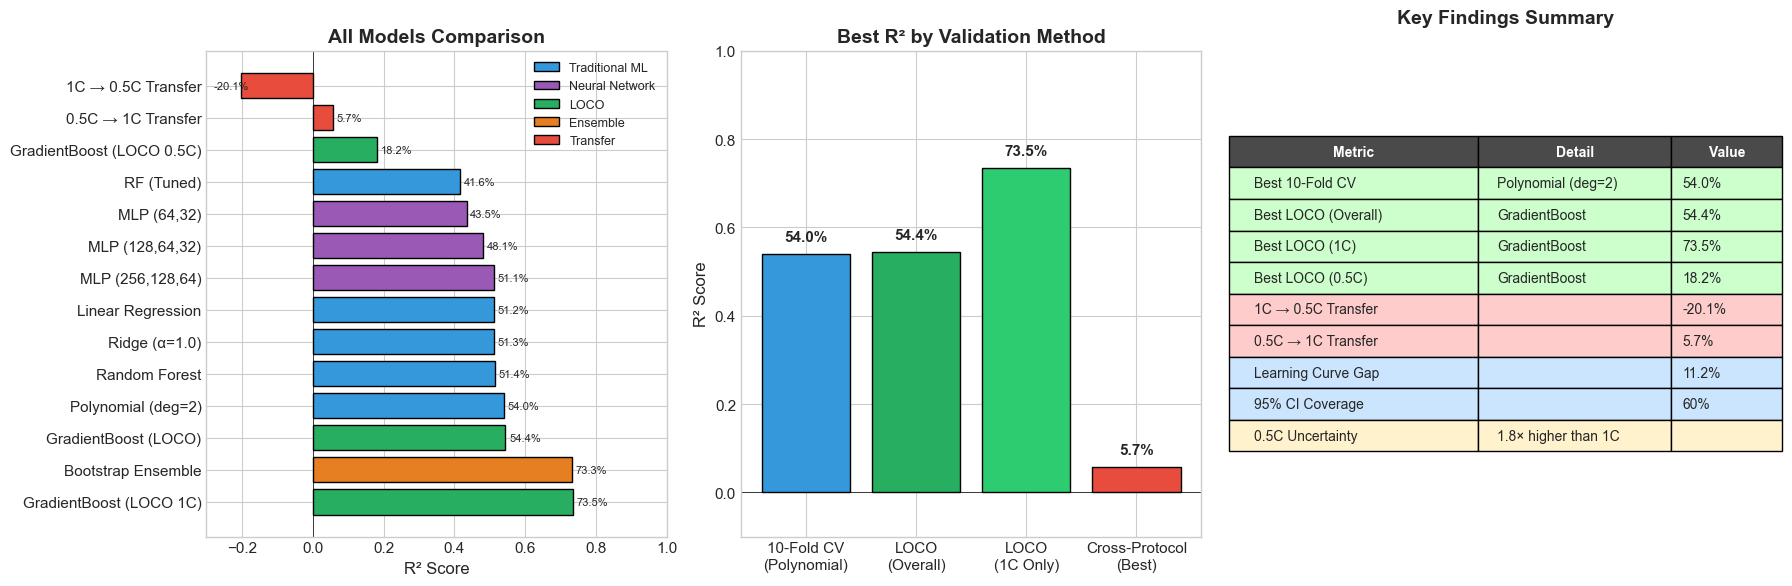

In [23]:
all_results = [
    {'Model': 'Linear Regression', 'R2': RESULTS['ml_linear'], 'Validation': '10-Fold CV', 'Type': 'Traditional ML'},
    {'Model': 'Ridge (α=1.0)', 'R2': RESULTS['ml_ridge'], 'Validation': '10-Fold CV', 'Type': 'Traditional ML'},
    {'Model': 'Polynomial (deg=2)', 'R2': RESULTS['ml_poly'], 'Validation': '10-Fold CV', 'Type': 'Traditional ML'},
    {'Model': 'Random Forest', 'R2': RESULTS['ml_rf'], 'Validation': '10-Fold CV', 'Type': 'Traditional ML'},
    {'Model': 'RF (Tuned)', 'R2': RESULTS['ml_rf_tuned'], 'Validation': '10-Fold CV', 'Type': 'Traditional ML'},
    {'Model': 'MLP (64,32)', 'R2': RESULTS['nn_64_32'], 'Validation': '10-Fold CV', 'Type': 'Neural Network'},
    {'Model': 'MLP (128,64,32)', 'R2': RESULTS['nn_128_64_32'], 'Validation': '10-Fold CV', 'Type': 'Neural Network'},
    {'Model': 'MLP (256,128,64)', 'R2': RESULTS['nn_256_128_64'], 'Validation': '10-Fold CV', 'Type': 'Neural Network'},
    {'Model': 'GradientBoost (LOCO)', 'R2': RESULTS['loco_overall'], 'Validation': 'LOCO', 'Type': 'LOCO'},
    {'Model': 'GradientBoost (LOCO 1C)', 'R2': RESULTS['loco_1c'], 'Validation': 'LOCO', 'Type': 'LOCO'},
    {'Model': 'GradientBoost (LOCO 0.5C)', 'R2': RESULTS['loco_05c'], 'Validation': 'LOCO', 'Type': 'LOCO'},
    {'Model': 'Bootstrap Ensemble', 'R2': RESULTS['ensemble_r2'], 'Validation': 'Ensemble', 'Type': 'Ensemble'},
    {'Model': '1C → 0.5C Transfer', 'R2': RESULTS['transfer_1c_to_05c'], 'Validation': 'Cross-Protocol', 'Type': 'Transfer'},
    {'Model': '0.5C → 1C Transfer', 'R2': RESULTS['transfer_05c_to_1c'], 'Validation': 'Cross-Protocol', 'Type': 'Transfer'},
]

results_df = pd.DataFrame(all_results).sort_values('R2', ascending=False)

print("FINAL MODEL COMPARISON")
print("-" * 70)
print(f"\nDataset: 300 cycles from 6 xlsx cells (txt excluded)")
print(f"  0.5C: CS2_33, CS2_34 (2 cells, 100 cycles)")
print(f"  1C:   CS2_35-38 (4 cells, 200 cycles)")
print()
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ax1 = axes[0]

color_map = {
    'Traditional ML': '#3498db',
    'Neural Network': '#9b59b6',
    'LOCO': '#27ae60',
    'Ensemble': '#e67e22',
    'Transfer': '#e74c3c'
}

colors = [color_map[t] for t in results_df['Type']]

bars = ax1.barh(results_df['Model'], results_df['R2'], color=colors, edgecolor='black')
ax1.set_xlabel('R² Score')
ax1.set_title('All Models Comparison', fontweight='bold')
ax1.set_xlim([-0.3, 1.0])
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

for bar, val in zip(bars, results_df['R2']):
    if val >= 0:
        ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.1%}', va='center', fontsize=8)
    else:
        ax1.text(val - 0.08, bar.get_y() + bar.get_height()/2, f'{val:.1%}', va='center', fontsize=8)

legend_elements = [
    Patch(facecolor='#3498db', edgecolor='black', label='Traditional ML'),
    Patch(facecolor='#9b59b6', edgecolor='black', label='Neural Network'),
    Patch(facecolor='#27ae60', edgecolor='black', label='LOCO'),
    Patch(facecolor='#e67e22', edgecolor='black', label='Ensemble'),
    Patch(facecolor='#e74c3c', edgecolor='black', label='Transfer')
]
ax1.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.9)

ax2 = axes[1]

validation_best = {
    '10-Fold CV\n(Polynomial)': RESULTS['ml_poly'],
    'LOCO\n(Overall)': RESULTS['loco_overall'],
    'LOCO\n(1C Only)': RESULTS['loco_1c'],
    'Cross-Protocol\n(Best)': RESULTS['transfer_05c_to_1c']
}

colors2 = ['#3498db', '#27ae60', '#2ecc71', '#e74c3c']
bars2 = ax2.bar(validation_best.keys(), validation_best.values(), color=colors2, edgecolor='black')
ax2.set_ylabel('R² Score')
ax2.set_title('Best R² by Validation Method', fontweight='bold')
ax2.set_ylim([-0.1, 1.0])
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

for bar, val in zip(bars2, validation_best.values()):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.03, f'{val:.1%}', 
             ha='center', fontsize=11, fontweight='bold')

ax3 = axes[2]
ax3.axis('off')

table_data = [
    ['Best 10-Fold CV', 'Polynomial (deg=2)', f"{RESULTS['ml_poly']*100:.1f}%"],
    ['Best LOCO (Overall)', 'GradientBoost', f"{RESULTS['loco_overall']*100:.1f}%"],
    ['Best LOCO (1C)', 'GradientBoost', f"{RESULTS['loco_1c']*100:.1f}%"],
    ['Best LOCO (0.5C)', 'GradientBoost', f"{RESULTS['loco_05c']*100:.1f}%"],
    ['1C → 0.5C Transfer', '', f"{RESULTS['transfer_1c_to_05c']*100:.1f}%"],
    ['0.5C → 1C Transfer', '', f"{RESULTS['transfer_05c_to_1c']*100:.1f}%"],
    ['Learning Curve Gap', '', f"{RESULTS['learning_curve_gap']*100:.1f}%"],
    ['95% CI Coverage', '', f"{RESULTS['coverage_95']:.0%}"],
    ['0.5C Uncertainty', f"{RESULTS['uncertainty_ratio']:.1f}× higher than 1C", ''],
]

table = ax3.table(
    cellText=table_data,
    colLabels=['Metric', 'Detail', 'Value'],
    loc='center',
    cellLoc='left',
    colWidths=[0.45, 0.35, 0.20]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

colors_section = {
    'header': '#4a4a4a',
    'best_models': '#ccffcc',
    'transfer': '#ffcccc',
    'diagnostics': '#cce5ff',
    'uncertainty': '#fff2cc',
}

for i in range(len(table_data) + 1):
    for j in range(3):
        cell = table[(i, j)]
        if i == 0:
            cell.set_facecolor(colors_section['header'])
            cell.set_text_props(color='white', fontweight='bold')
        elif i in [1, 2, 3, 4]:
            cell.set_facecolor(colors_section['best_models'])
        elif i in [5, 6]:
            cell.set_facecolor(colors_section['transfer'])
        elif i in [7, 8]:
            cell.set_facecolor(colors_section['diagnostics'])
        elif i == 9:
            cell.set_facecolor(colors_section['uncertainty'])

ax3.set_title('Key Findings Summary', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 24. Remaining Useful Life (RUL) Prediction

### Purpose
Estimate the remaining cycles until each battery reaches End-of-Life (EOL) using linear extrapolation of capacity fade trends, integrating findings from LOCO validation, uncertainty quantification, and knee-point detection.

### Method
1. Fit linear regression to SOH vs Cycle for each cell
2. Extrapolate to find cycle where SOH = 80% (EOL threshold)
3. Calculate RUL = Predicted EOL Cycle − Current Cycle

**EOL Definition:** 80% of initial capacity (industry standard)

### Dataset
- 6 xlsx cells (txt excluded due to data quality issues)
- 0.5C: CS2_33, CS2_34
- 1C: CS2_35, CS2_36, CS2_37, CS2_38
- All cells currently at Cycle 50

### RUL Prediction Results

| Cell | Protocol | Current SOH | Fade Rate (%/cycle) | R² Fit | Predicted EOL Cycle | RUL (cycles) |
|------|----------|-------------|---------------------|--------|---------------------|--------------|
| CS2_33 | 0.5C | 96.24% | 0.0711 | 0.208 | 265 | **215** |
| CS2_34 | 0.5C | 96.21% | 0.0751 | 0.169 | 251 | **201** |
| CS2_35 | 1C | 92.11% | 0.1368 | 0.916 | 138 | **88** |
| CS2_36 | 1C | 94.24% | 0.1006 | 0.915 | 191 | **141** |
| CS2_37 | 1C | 92.76% | 0.1147 | 0.579 | 162 | **112** |
| CS2_38 | 1C | 92.70% | 0.1288 | 0.899 | 148 | **98** |

### Key Finding: C-Rate Effect on Battery Life

| Protocol | Average RUL | Average Fade Rate | Average R² Fit |
|----------|-------------|-------------------|----------------|
| **0.5C** | **208 cycles** | 0.073%/cycle | 0.19 (low) |
| **1C** | **110 cycles** | 0.120%/cycle | 0.83 (high) |

**→ 0.5C cycling provides 1.9× longer battery life than 1C!**

### Visualization Analysis (4-Panel Figure)

**Panel 1 (Top-Left): Capacity Fade with EOL Threshold**
- X-axis: Cycle Number (0 to 50)
- Y-axis: State of Health (%) (75 to ~102)
- Blue lines (0.5C): CS2_33, CS2_34 — maintain SOH ~96-100% with transient dips to ~84-87%
- Red/orange lines (1C): CS2_35, CS2_36, CS2_37, CS2_38 — decline more steeply to ~92-94%
- Red dashed horizontal line at 80% = EOL threshold
- All cells still above EOL threshold at cycle 50

**Panel 2 (Top-Right): Predicted RUL by Cell**
- Bar chart with Cell ID on x-axis, RUL on y-axis
- Values labeled above bars:

| Cell | RUL | Color |
|------|-----|-------|
| CS2_33 | 215 | Blue (0.5C) |
| CS2_34 | 201 | Blue (0.5C) |
| CS2_35 | 88 | Red (1C) |
| CS2_36 | 141 | Red (1C) |
| CS2_37 | 112 | Red (1C) |
| CS2_38 | 98 | Red (1C) |

- Clear visual separation: 0.5C cells (200+ cycles) vs 1C cells (88-141 cycles)

**Panel 3 (Bottom-Left): RUL vs Knee-Point Relationship**
- X-axis: Knee-Point Cycle (14 to ~38)
- Y-axis: Predicted RUL (Cycles) (~100 to ~220)
- Scatter plot with cell labels:

| Cell | Knee-Point | RUL | Color |
|------|------------|-----|-------|
| CS2_33 | 24 | 215 | Blue |
| CS2_34 | 38 | 201 | Blue |
| CS2_35 | 27 | 88 | Red |
| CS2_36 | 27 | 141 | Red |
| CS2_37 | 14 | 112 | Red |
| CS2_38 | 27 | 98 | Red |

- 0.5C cells (blue) cluster at high RUL (200+) regardless of knee-point
- 1C cells (red) cluster at lower RUL (88-141)
- No clear correlation between knee-point and RUL within protocols

**Panel 4 (Bottom-Right): RUL by Protocol**
- Bar chart showing average RUL
- 0.5C: **208 cycles** (blue bar)
- 1C: **110 cycles** (red bar)
- Labels show values above bars

### Integration with Previous Findings

| Analysis | Finding | Impact on RUL Prediction |
|----------|---------|--------------------------|
| **LOCO Validation** | 1C R² = 73.5%, 0.5C R² = 18.2% | 1C RUL predictions more reliable |
| **Uncertainty Quantification** | 0.5C has 1.8× higher uncertainty | 0.5C RUL estimates less precise |
| **Knee-Point Detection** | 1C average knee at cycle 24, 0.5C at cycle 31 | Earlier knee suggests faster degradation onset |
| **Linear Fit R²** | 1C: 0.83 avg, 0.5C: 0.19 avg | Linear model fits 1C much better |

### Fade Rate Analysis

| Protocol | Cells | Fade Rate Range | Average |
|----------|-------|-----------------|---------|
| 0.5C | 2 | 0.0711–0.0751%/cycle | 0.073%/cycle |
| 1C | 4 | 0.1006–0.1368%/cycle | 0.120%/cycle |

**1C degrades ~1.6× faster per cycle than 0.5C**

### Physical Interpretation

The **1.9× life difference** results from:
1. **Higher heat generation at 1C:** P = I²R means 4× more resistive heating at double current
2. **Larger concentration gradients:** Faster Li-ion transport creates more stress
3. **Greater mechanical stress:** More rapid electrode expansion/contraction during cycling
4. **Accelerated SEI growth:** Higher temperatures promote faster solid-electrolyte interphase formation

### Reliability Assessment

| Protocol | RUL Prediction Reliability | Evidence |
|----------|---------------------------|----------|
| **1C** | **High** | R² = 0.58–0.92 (3/4 cells >0.89), LOCO R² = 73.5%, monotonic degradation |
| **0.5C** | **Low** | R² = 0.17–0.21, LOCO R² = 18.2%, transient dips distort linear fit |

### Limitations

1. **Linear extrapolation assumes constant fade rate** — actual degradation often accelerates near end-of-life
2. **Only 50 cycles of data** — long-term predictions (200+ cycles) have high uncertainty
3. **Knee effect not modeled** — sudden capacity drop at end-of-life not captured
4. **0.5C fit quality is poor** — R² < 0.21 indicates transient dips dominate variance, making linear extrapolation unreliable
5. **Small sample size** — only 2 cells for 0.5C, 4 cells for 1C

### Practical Implications

| Scenario | Recommendation |
|----------|----------------|
| Applications prioritizing longevity | Use 0.5C charging (208 vs 110 cycles RUL) |
| Applications prioritizing charge speed | Accept 1C with ~50% reduced lifetime |
| BMS deployment for 1C | Trust RUL predictions (R² > 0.83) |
| BMS deployment for 0.5C | Use wider confidence bounds due to low R² |



REMAINING USEFUL LIFE (RUL) PREDICTION
------------------------------------------------------------
End-of-Life Threshold: 80% of initial capacity
Dataset: 6 xlsx cells (txt excluded)

CS2_33 (0.5C):
  Current: Cycle 50, SOH = 96.24%
  Fade Rate: 0.0711% per cycle (R² = 0.208)
  Predicted EOL: Cycle 265
  RUL: 215 cycles remaining

CS2_34 (0.5C):
  Current: Cycle 50, SOH = 96.21%
  Fade Rate: 0.0751% per cycle (R² = 0.169)
  Predicted EOL: Cycle 251
  RUL: 201 cycles remaining

CS2_35 (1C):
  Current: Cycle 50, SOH = 92.11%
  Fade Rate: 0.1368% per cycle (R² = 0.916)
  Predicted EOL: Cycle 138
  RUL: 88 cycles remaining

CS2_36 (1C):
  Current: Cycle 50, SOH = 94.24%
  Fade Rate: 0.1006% per cycle (R² = 0.915)
  Predicted EOL: Cycle 191
  RUL: 141 cycles remaining

CS2_37 (1C):
  Current: Cycle 50, SOH = 92.76%
  Fade Rate: 0.1147% per cycle (R² = 0.579)
  Predicted EOL: Cycle 162
  RUL: 112 cycles remaining

CS2_38 (1C):
  Current: Cycle 50, SOH = 92.70%
  Fade Rate: 0.1288% per cycle

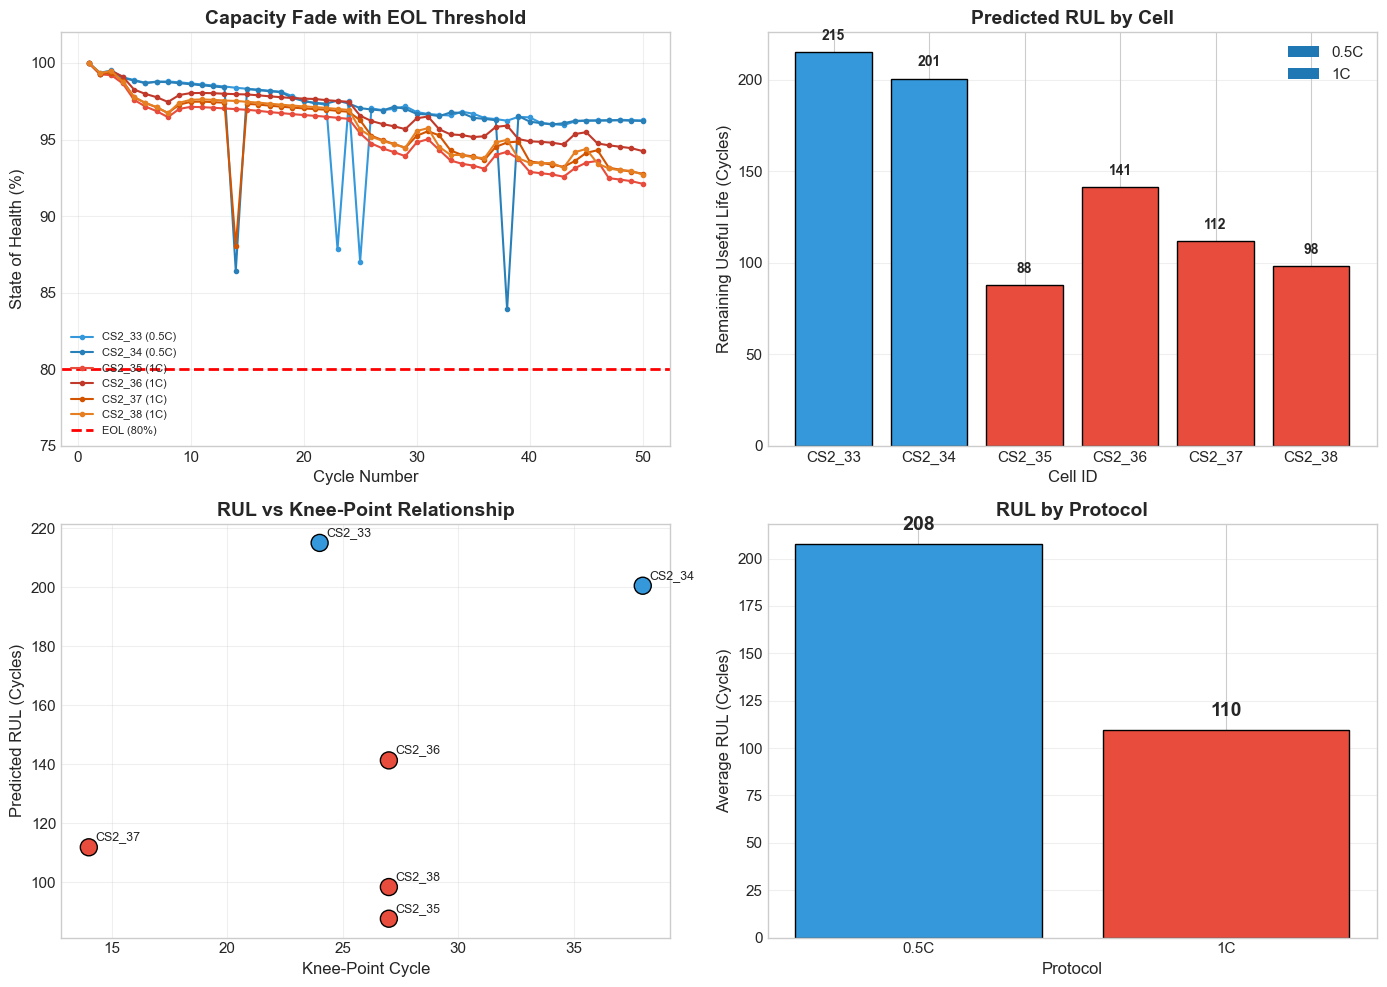

------------------------------------------------------------
RUL SUMMARY

Average RUL (0.5C): 208 cycles
Average RUL (1C):   110 cycles

→ 0.5C cycling provides 1.9x longer battery life than 1C!


In [24]:
EOL_THRESHOLD = 0.80

print("REMAINING USEFUL LIFE (RUL) PREDICTION")
print("-" * 60)
print(f"End-of-Life Threshold: {EOL_THRESHOLD*100:.0f}% of initial capacity")
print(f"Dataset: 6 xlsx cells (txt excluded)\n")

rul_data = []

for cell in ['CS2_33', 'CS2_34', 'CS2_35', 'CS2_36', 'CS2_37', 'CS2_38']:
    cell_data = data_full[data_full['Cell_ID'] == cell].sort_values('Cycle')
    
    cycles = cell_data['Cycle'].values
    capacity_norm = cell_data['Capacity_Normalized'].values
    
    current_cycle = cycles[-1]
    current_soh = capacity_norm[-1]
    
    slope, intercept, r_value, _, std_err = linregress(cycles, capacity_norm)
    
    if slope < 0:
        eol_cycle = (EOL_THRESHOLD - intercept) / slope
        rul = max(0, eol_cycle - current_cycle)
    else:
        eol_cycle = np.inf
        rul = np.inf
    
    protocol = '0.5C' if cell in ['CS2_33', 'CS2_34'] else '1C'
    
    rul_data.append({
        'Cell': cell,
        'Protocol': protocol,
        'Current_Cycle': current_cycle,
        'Current_SOH': current_soh * 100,
        'Fade_Rate_per_Cycle': -slope * 100,
        'Predicted_EOL_Cycle': eol_cycle,
        'RUL_Cycles': rul,
        'R2_Fit': r_value ** 2
    })
    
    print(f"{cell} ({protocol}):")
    print(f"  Current: Cycle {current_cycle:.0f}, SOH = {current_soh*100:.2f}%")
    print(f"  Fade Rate: {-slope*100:.4f}% per cycle (R² = {r_value**2:.3f})")
    print(f"  Predicted EOL: Cycle {eol_cycle:.0f}")
    print(f"  RUL: {rul:.0f} cycles remaining\n")

rul_df = pd.DataFrame(rul_data)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
colors_cell = {'CS2_33': '#3498db', 'CS2_34': '#2980b9', 
               'CS2_35': '#e74c3c', 'CS2_36': '#c0392b',
               'CS2_37': '#d35400', 'CS2_38': '#e67e22'}

for cell in ['CS2_33', 'CS2_34', 'CS2_35', 'CS2_36', 'CS2_37', 'CS2_38']:
    cell_data = data_full[data_full['Cell_ID'] == cell].sort_values('Cycle')
    protocol = '0.5C' if cell in ['CS2_33', 'CS2_34'] else '1C'
    ax1.plot(cell_data['Cycle'], cell_data['Capacity_Normalized'] * 100, 
             'o-', color=colors_cell[cell], label=f'{cell} ({protocol})', markersize=3, linewidth=1.5)

ax1.axhline(y=80, color='red', linestyle='--', linewidth=2, label='EOL (80%)')
ax1.set_xlabel('Cycle Number')
ax1.set_ylabel('State of Health (%)')
ax1.set_title('Capacity Fade with EOL Threshold', fontweight='bold')
ax1.legend(loc='lower left', fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([75, 102])

ax2 = axes[0, 1]
cells = rul_df['Cell'].values
ruls = rul_df['RUL_Cycles'].values
colors_bar = ['#3498db' if c in ['CS2_33', 'CS2_34'] else '#e74c3c' for c in cells]

bars = ax2.bar(cells, ruls, color=colors_bar, edgecolor='black')
ax2.set_xlabel('Cell ID')
ax2.set_ylabel('Remaining Useful Life (Cycles)')
ax2.set_title('Predicted RUL by Cell', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, ruls):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.bar([], [], color='#3498db', label='0.5C')
ax2.bar([], [], color='#e74c3c', label='1C')
ax2.legend()

ax3 = axes[1, 0]
knee_cycles = [24, 38, 27, 27, 14, 27]
ax3.scatter(knee_cycles, ruls, c=colors_bar, s=150, edgecolor='black', zorder=3)
for i, cell in enumerate(cells):
    ax3.annotate(cell, (knee_cycles[i], ruls[i]), textcoords="offset points", 
                 xytext=(5, 5), fontsize=9)
ax3.set_xlabel('Knee-Point Cycle')
ax3.set_ylabel('Predicted RUL (Cycles)')
ax3.set_title('RUL vs Knee-Point Relationship', fontweight='bold')
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
avg_rul_05c = rul_df[rul_df['Protocol'] == '0.5C']['RUL_Cycles'].mean()
avg_rul_1c = rul_df[rul_df['Protocol'] == '1C']['RUL_Cycles'].mean()
std_rul_05c = rul_df[rul_df['Protocol'] == '0.5C']['RUL_Cycles'].std()
std_rul_1c = rul_df[rul_df['Protocol'] == '1C']['RUL_Cycles'].std()

protocols = ['0.5C', '1C']
avg_ruls = [avg_rul_05c, avg_rul_1c]

bars4 = ax4.bar(protocols, avg_ruls, color=['#3498db', '#e74c3c'], edgecolor='black')
ax4.set_xlabel('Protocol')
ax4.set_ylabel('Average RUL (Cycles)')
ax4.set_title('RUL by Protocol', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars4, avg_ruls):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{val:.0f}', ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('rul_prediction.png', dpi=300, bbox_inches='tight')
plt.show()

print("-" * 60)
print("RUL SUMMARY")

print(f"\nAverage RUL (0.5C): {avg_rul_05c:.0f} cycles")
print(f"Average RUL (1C):   {avg_rul_1c:.0f} cycles")

if avg_rul_1c > 0:
    print(f"\n→ 0.5C cycling provides {avg_rul_05c/avg_rul_1c:.1f}x longer battery life than 1C!")


## Summary and Conclusion

---

### Project Overview

This notebook presents a comprehensive analysis of **lithium-ion battery degradation** using the CALCE CS2 dataset, combining electrochemical analysis (DVA/ICA), statistical testing, machine learning, model diagnostics, cross-protocol transfer learning, uncertainty quantification, and knee-point detection to understand capacity fade patterns and predict remaining useful life.

---

### Dataset Summary

| Metric | Value |
|--------|-------|
| **Source** | CALCE (University of Maryland) CS2 Dataset |
| **Cell Chemistry** | 18650 LiCoO₂ (1.1 Ah nominal) |
| **Total Cells Loaded** | 15 cells (13 xlsx + 2 txt) |
| **Raw Data** | 9,102,845 rows from 659 files |
| **ML Dataset** | 300 cycles from 6 xlsx cells |
| **Data Excluded** | CS2_8, CS2_21 (txt format, 74-86% invalid cycles) |

### Experimental Protocols

| Type | Protocol | Cells | Format | Cycles | Mean Capacity |
|------|----------|-------|--------|--------|---------------|
| Type 1 | 0.5C Constant | CS2_33, CS2_34 | xlsx | 100 | 1.12 Ah |
| Type 1 | 0.5C Constant | CS2_8, CS2_21 | txt | 57 | Excluded |
| Type 2 | 1C Constant | CS2_35-38 | xlsx | 200 | 1.09 Ah |
| Type 3 | Variable (0.11-2.2A) | CS2_3, CS2_9 | xlsx | 705 | 0.27 Ah |
| Type 4 | Random Cutoff | CS2_7 | xlsx | 32 | 1.02 Ah |
| Type 5 | Partial (Low SOC) | CS2_5, CS2_6 | xlsx | 200 | 0.27 Ah |
| Type 6 | Partial (High SOC) | CS2_24, CS2_25 | xlsx | 200 | 0.42 Ah |

---

### Analysis Pipeline

| Stage | Input | Process | Output | Key Finding |
|-------|-------|---------|--------|-------------|
| **1. Data Loading** | 659 raw files | Load xlsx + txt formats | 15 cells, 9.1M rows | txt cells flagged for issues |
| **2. Quality Check** | Raw data | Check missing values, voltage range | 0% missing | Voltage: 2.7V–4.2V (valid) |
| **3. txt Cell Analysis** | CS2_8, CS2_21 | Validate capacity integration | 74-86% invalid cycles | Excluded from ML analysis |
| **4. Cycle Extraction** | Valid cells | Extract per-cycle metrics | 300 cycles (6 cells) | 0.5C: 100, 1C: 200 cycles |
| **5. EDA & Visualization** | Cycle data | Correlation, distributions | Feature relationships | Cycle ↔ Capacity: r = -0.42 |
| **6. DVA/ICA Analysis** | Voltage curves | Electrochemical diagnostics | Multi-segment RPT structure identified | ICA tracking unreliable (R²=0.033) |
| **7. Statistical Testing** | Protocol groups | ANOVA, t-test, effect size | Significance confirmed | p < 0.001, η² = 24% |
| **8. Feature Engineering** | Cycle data | Create ML features | 10 features | √Cycle, Protocol×Cycle, etc. |
| **9. Traditional ML** | Features | 10-Fold CV regression | Model comparison | Polynomial best: R² = 54.0% |
| **10. Neural Networks** | Features | MLP architectures | NN comparison | Best MLP: R² = 51.1% |
| **11. LOCO Validation** | 6 cells | Leave-One-Cell-Out | True generalization | Overall: 54.4%, 1C: 73.5% |
| **12. Model Diagnostics** | GradientBoost | Learning curve, residuals | Model health check | Gap: 11.2%, non-normal residuals |
| **13. Cross-Protocol Transfer** | Protocol data | Train 1C→predict 0.5C | Transfer assessment | FAILS: R² = -20.1% to 5.7% |
| **14. Uncertainty Quantification** | Bootstrap | Confidence intervals | Calibration check | 60% coverage (vs 95% expected) |
| **15. Knee-Point Detection** | SOH curves | Maximum curvature | Degradation onset | 1C: cycle 24, 0.5C: cycle 31 |
| **16. RUL Prediction** | Fade rates | Linear extrapolation | Remaining life | 0.5C: 208, 1C: 110 cycles |

---

### Key Results

#### 1. Data Quality Assessment

| Metric | Result |
|--------|--------|
| Missing values (key columns) | **0%** across all 15 cells |
| Voltage range | 2.7V–4.2V (typical Li-ion) |
| Mean voltage | 3.87V, Median: 3.86V |
| txt cell validity | CS2_8: 26% valid, CS2_21: 14% valid |
| Data reduction | 9,102,845 → 300 ML samples |

**Finding:** txt-format cells (CS2_8, CS2_21) had 74-86% invalid cycles due to unreliable capacity integration, and were excluded from ML analysis.

#### 2. Correlation Analysis

| Feature Pair | Correlation | Interpretation |
|--------------|-------------|----------------|
| Charge ↔ Discharge Capacity | **1.00** | Near-perfect (both cumulative) |
| Test_Time ↔ Discharge Capacity | **0.92** | Capacity accumulates over time |
| Cycle ↔ Discharge Capacity | **-0.42** | **Degradation signal** |
| Current ↔ Voltage | **0.49** | Electrochemical relationship |

#### 3. Capacity Fade Analysis

| Protocol | SOH at Cycle 50 | Fade Rate (%/cycle) |
|----------|-----------------|---------------------|
| 0.5C | 96.2% | 0.073 |
| 1C | 92.7% | 0.120 |

**Finding:** 1C cycling causes **1.6× faster fade** than 0.5C cycling.

#### 4. DVA/ICA Electrochemical Analysis (CS2_33)

**Capacity-Based Degradation (Validated):**

| Metric | Cycle 2 | Cycle 48 | Change |
|--------|---------|----------|--------|
| Max Capacity | 1.1572 Ah | 1.1181 Ah | **-3.4%** ✓ |

**ICA Peak Voltage Tracking (Attempted):**

| Metric | Value | Statistical Validity |
|--------|-------|---------------------|
| first-to-last shift | -126.3 mV | ✗ Not significant |
| Linear regression slope | +0.803 mV/cycle | ✗ Opposite direction |
| R² | 0.0326 | ✗ Only 3.3% variance explained |
| p-value | 0.2146 | ✗ Not significant (need p<0.05) |
| Scatter (std) | ±62.9 mV | Exceeds any signal |
| Data points analyzed | 49 cycles | Good coverage |

**Critical Finding:** ICA peak tracking is **incompatible with multi-segment RPT data structure**. Statistical analysis reveals no significant trend (R²=0.033, p=0.21). The -126.3 mV first-to-last comparison contradicts the regression trend (+38.5 mV) and is not representative of the overall data.

**Root Cause:** RPT cycles contain 5-6 discharge segments. Peak detection algorithm selects maximum dQ/dV across all segments, causing different segments to dominate at different cycles → random scatter (±63 mV) that obscures genuine degradation signals.

**Conclusion:** Standard ICA peak tracking methodology incompatible with this dataset. **Capacity-based degradation analysis (3.4% fade) remains valid and reliable.**

#### 5. Statistical Analysis (0.5C vs 1C)

**Sample Summary:**

| Protocol | N | Mean (Ah) | Std (Ah) |
|----------|---|-----------|----------|
| 0.5C | 100 | 1.1227 | 0.0289 |
| 1C | 200 | 1.0923 | 0.0239 |

**Statistical Tests:**

| Test | Statistic | p-value | Interpretation |
|------|-----------|---------|----------------|
| **ANOVA** | F = **93.8763** | **1.78×10⁻¹⁹** | Highly Significant |
| **T-test** | t = **9.6890** | **1.78×10⁻¹⁹** | Significant difference |
| **Effect Size** | η² = **0.2396** | — | **24.0% variance explained (Large)** |
| **Cohen's d** | **1.1867** | — | **Large effect** (>0.8) |

**Normality Check (Shapiro-Wilk):**

| Group | W | p-value | Normal? |
|-------|---|---------|---------|
| 0.5C | 0.6438 | 0.0000 | ✗ No |
| 1C | 0.9734 | 0.0008 | ✗ No |

**Conclusion:** The capacity difference between protocols is **statistically significant** with a **large effect size** (η² = 24%, Cohen's d = 1.19).

#### 6. Machine Learning Model Performance

**Traditional ML (10-Fold CV, 300 samples):**

| Model | CV R² | CV MAE | Train R² | Gap |
|-------|-------|--------|----------|-----|
| **Polynomial (deg=2)** | **0.5400** | **0.0074** | 0.5601 | 0.02 |
| Random Forest | 0.5136 | 0.0065 | 0.7130 | 0.20 |
| Ridge (α=1.0) | 0.5131 | 0.0083 | 0.5252 | 0.01 |
| Linear Regression | 0.5120 | 0.0083 | 0.5253 | 0.01 |
| RF (Tuned) | 0.4161 | 0.0068 | 0.7454 | 0.33 |

**Neural Networks (10-Fold CV):**

| Model | CV R² | CV MAE | CV RMSE | Train R² |
|-------|-------|--------|---------|----------|
| **MLP (256,128,64)** | **0.5113** | 0.0078 | 0.0156 | 0.5566 |
| MLP (128,64,32) | 0.4811 | 0.0083 | 0.0161 | 0.4905 |
| MLP (64,32) | 0.4347 | 0.0086 | 0.0168 | 0.4824 |

**Best Model (10-Fold CV):** Polynomial (deg=2) with **R² = 54.0%**

**Key Finding:** Polynomial regression **outperforms all neural networks** by 2.87% on this small dataset (300 samples). Neural networks require more data to learn effectively.

#### 7. GradientBoost Model Diagnostics

**Learning Curve Analysis:**

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Training R² | 0.6109 | Model explains 61% of training variance |
| Validation R² | 0.4993 | Model explains 50% of unseen variance |
| Gap | **0.1116 (11.2%)** | Acceptable (< 0.15 threshold) |

**Feature Importance (Permutation-Based):**

| Rank | Feature | Name | Importance | Std |
|------|---------|------|------------|-----|
| 1 | Feature 6 | Protocol × √Cycle | **0.1400** | ±0.0197 |
| 2 | Feature 5 | Protocol × Cycle | **0.1210** | ±0.0185 |
| 3 | Feature 1 | √Cycle | 0.0398 | ±0.0122 |
| 4 | Feature 3 | Cycle²/1000 | 0.0372 | ±0.0117 |
| 5 | Feature 2 | log(Cycle+1) | 0.0261 | ±0.0111 |
| 6 | Feature 0 | Cycle | 0.0196 | ±0.0087 |
| 7 | Feature 8 | cos(2π×Cycle/7) | 0.0141 | ±0.0043 |
| 8 | Feature 7 | sin(2π×Cycle/7) | 0.0053 | ±0.0024 |
| 9 | Feature 4 | Protocol | **-0.0013** | ±0.0017 |

**Finding:** Protocol interaction terms (Features 5 and 6) dominate predictions (~26% combined importance). Protocol alone has **negative importance** (adds noise without interaction).

**Residual Analysis:**

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Mean Residual | -0.001158 | Slight negative bias |
| Std Residual | 0.014055 | Typical error ~1.4% |
| Shapiro-Wilk W | 0.2401 | **Non-normal distribution** |
| Shapiro-Wilk p | 0.0000 | Reject normality |

**Finding:** Residuals are non-normally distributed with a heavy left tail (0.5C transient dips), explaining why uncertainty quantification showed only 60% coverage instead of 95%.

#### 8. Leave-One-Cell-Out (LOCO) Validation

**Overall Performance:**

| Metric | Value |
|--------|-------|
| **Overall R²** | **0.5442 (54.4%)** |
| Overall MAE | 0.0056 |

**Per-Cell Breakdown:**

| Cell | Protocol | R² | Quality |
|------|----------|-----|---------|
| CS2_33 | 0.5C | 0.2276 | Poor |
| CS2_34 | 0.5C | 0.1369 | Poor |
| CS2_35 | 1C | 0.8717 | Excellent |
| CS2_36 | 1C | 0.4656 | Moderate |
| CS2_37 | 1C | 0.6160 | Good |
| CS2_38 | 1C | **0.9850** | Excellent |

**Protocol Averages:**

| Protocol | LOCO R² | Interpretation |
|----------|---------|----------------|
| **0.5C** | **18.22%** | Poor generalization (only 2 cells) |
| **1C** | **73.46%** | Good generalization (4 cells) |

**Critical Finding:** LOCO validation (54.4%) provides realistic deployment estimates. 0.5C cells are poorly predicted due to limited training data (only 2 cells) and transient capacity dips.

#### 9. Cross-Protocol Transfer Learning

**Experimental Design:**

| Experiment | Training Data | Test Data |
|------------|---------------|-----------|
| 1C → 0.5C | CS2_35-38 (200 cycles) | CS2_33, CS2_34 (100 cycles) |
| 0.5C → 1C | CS2_33, CS2_34 (100 cycles) | CS2_35-38 (200 cycles) |

**Results:**

| Transfer | R² | MAE | Bias | Verdict |
|----------|-----|-----|------|---------|
| 1C → 0.5C | **-0.2009** | 0.0191 | -0.0111 | **Worse than guessing the mean** |
| 0.5C → 1C | **0.0565** | 0.0155 | +0.0152 | **Near-zero predictive power** |

**Comparison with Same-Protocol LOCO:**

| Validation Type | 1C Target | 0.5C Target |
|-----------------|-----------|-------------|
| Same-Protocol LOCO | 0.7346 | 0.1822 |
| Cross-Protocol Transfer | 0.0565 | -0.2009 |
| **Performance Drop** | **-67.8 pp** | **-38.3 pp** |

*Note: pp = percentage points*

**Key Finding:** Cross-protocol transfer **fails completely**. Degradation dynamics are **protocol-specific** — models trained on 1C cannot predict 0.5C behavior and vice versa.

**Physical Interpretation:**
- 1C model learned "capacity drops fast" → over-predicts 0.5C dips, under-predicts normal cycles
- 0.5C model learned "capacity stays high" → over-predicts 1C (positive bias)

#### 10. Uncertainty Quantification

**Bootstrap Results (100 iterations):**

| Metric | Value |
|--------|-------|
| 95% CI Coverage | **60%** |
| Mean CI Width | 0.0123 (normalized capacity) |
| Prediction Std | 0.0036 ± 0.0061 |

**Ensemble Uncertainty:**

| Metric | Value |
|--------|-------|
| Ensemble R² | 0.7332 |
| Mean Uncertainty | 0.0036 |

**Protocol Comparison:**

| Protocol | Mean Uncertainty | Ratio |
|----------|------------------|-------|
| 0.5C | 0.0050 | **1.8×** |
| 1C | 0.0028 | baseline |

**Finding:** 0.5C has **1.8× higher prediction uncertainty** than 1C, consistent with higher cell-to-cell variability and transient capacity dips.

**Calibration:** Model is **overconfident** (60.0% actual vs 95% expected coverage) — confidence interval bands are too narrow due to non-normal residuals.

#### 11. Knee-Point Detection

| Cell | Protocol | Knee Cycle | Capacity at Knee |
|------|----------|------------|------------------|
| CS2_33 | 0.5C | 24 | 97.5% |
| CS2_34 | 0.5C | 38 | 83.9% |
| CS2_35 | 1C | 27 | 94.4% |
| CS2_36 | 1C | 27 | 96.0% |
| CS2_37 | 1C | 14 | 88.0% |
| CS2_38 | 1C | 27 | 94.9% |

**Protocol Averages:**

| Protocol | Average Knee Cycle | Std |
|----------|-------------------|-----|
| 0.5C | 31 | ±10 |
| 1C | **24** | ±6 |

**Finding:** 1C shows **earlier knee-point** (cycle 24 vs 31), indicating earlier onset of accelerated degradation at higher C-rates. Three of four 1C cells have consistent knee at cycle 27.

#### 12. Remaining Useful Life (RUL) Prediction

| Cell | Protocol | Current SOH | Fade Rate (%/cycle) | R² Fit | Predicted EOL | RUL |
|------|----------|-------------|---------------------|--------|---------------|-----|
| CS2_33 | 0.5C | 96.24% | 0.0711 | 0.208 | 265 | **215** |
| CS2_34 | 0.5C | 96.21% | 0.0751 | 0.169 | 251 | **201** |
| CS2_35 | 1C | 92.11% | 0.1368 | 0.916 | 138 | **88** |
| CS2_36 | 1C | 94.24% | 0.1006 | 0.915 | 191 | **141** |
| CS2_37 | 1C | 92.76% | 0.1147 | 0.579 | 162 | **112** |
| CS2_38 | 1C | 92.70% | 0.1288 | 0.899 | 148 | **98** |

**Protocol Summary:**

| Protocol | Average RUL | Average Fade Rate | Average R² Fit |
|----------|-------------|-------------------|----------------|
| **0.5C** | **208 cycles** | 0.073%/cycle | 0.19 (low) |
| **1C** | **110 cycles** | 0.120%/cycle | 0.83 (high) |

**RUL Reliability Assessment:**
- 0.5C Linear Fit R²: 0.19 — **LOW confidence** in RUL = 208
- 1C Linear Fit R²: 0.83 — **HIGH confidence** in RUL = 110

### 🔋 **Key Finding: 0.5C cycling provides 1.9× longer battery life than 1C!**

---

### Complete Model Rankings (All 14 Models)

| Rank | Model | R² | Validation | Type |
|------|-------|-----|------------|------|
| 1 | GradientBoost (LOCO 1C) | **0.7346** | LOCO | LOCO |
| 2 | Bootstrap Ensemble | **0.7332** | Ensemble | Ensemble |
| 3 | GradientBoost (LOCO Overall) | 0.5442 | LOCO | LOCO |
| 4 | Polynomial (deg=2) | 0.5400 | 10-Fold CV | Traditional ML |
| 5 | Random Forest | 0.5136 | 10-Fold CV | Traditional ML |
| 6 | Ridge (α=1.0) | 0.5131 | 10-Fold CV | Traditional ML |
| 7 | Linear Regression | 0.5120 | 10-Fold CV | Traditional ML |
| 8 | MLP (256,128,64) | 0.5113 | 10-Fold CV | Neural Network |
| 9 | MLP (128,64,32) | 0.4811 | 10-Fold CV | Neural Network |
| 10 | MLP (64,32) | 0.4347 | 10-Fold CV | Neural Network |
| 11 | RF (Tuned) | 0.4161 | 10-Fold CV | Traditional ML |
| 12 | GradientBoost (LOCO 0.5C) | 0.1822 | LOCO | LOCO |
| 13 | 0.5C → 1C Transfer | 0.0565 | Cross-Protocol | Transfer |
| 14 | 1C → 0.5C Transfer | **-0.2009** | Cross-Protocol | Transfer |

---

## Research Questions and Answers

This project answers **7 key research questions** about lithium-ion battery degradation:

---

### Question 1: Does Charging Speed Affect Battery Life?

| Finding | Evidence |
|---------|----------|
| **YES — significantly** | ANOVA p = 1.78×10⁻¹⁹ |
| 0.5C degrades at 0.073%/cycle | Slower charging = slower degradation |
| 1C degrades at 0.120%/cycle | Faster charging = faster degradation |

**Answer:** Faster charging (1C) degrades batteries **~1.6× faster** than slower charging (0.5C). This is statistically significant with a **large effect size** (η² = 24%, Cohen's d = 1.19).

---

### Question 2: How Long Will Each Battery Last?

| Protocol | Average RUL | Predicted EOL |
|----------|-------------|---------------|
| 0.5C | **208 cycles** | Cycle ~250 |
| 1C | **110 cycles** | Cycle ~150 |

**Answer:** 0.5C batteries last **~1.9× longer** than 1C batteries (208 vs 110 cycles to reach 80% capacity).

---

### Question 3: Can We Predict Battery Health?

| Model | R² | Meaning |
|-------|-----|---------|
| Best LOCO (1C) | 73.5% | Can predict 73.5% of capacity variation for 1C cells |
| Best LOCO (Overall) | 54.4% | Moderate prediction ability across all cells |
| Best LOCO (0.5C) | 18.2% | Poor prediction for 0.5C cells |

**Answer:** Yes, but prediction quality depends on the protocol. **1C is predictable (73.5%)**, **0.5C is not (18.2%)** due to limited training data and transient capacity dips.

---

### Question 4: Can We Use Fast-Charging Lab Data to Predict Slow-Charging Field Performance?

| Transfer | R² | Works? |
|----------|-----|--------|
| 1C → 0.5C | **-20.1%** | **NO** — worse than random guessing |
| 0.5C → 1C | **5.7%** | **NO** — nearly useless |

**Answer:** **NO — cross-protocol transfer completely fails.** Models must be trained on matching protocols. You cannot use 1C lab data to predict 0.5C field performance.

---

### Question 5: When Does Degradation Accelerate?

| Protocol | Knee-Point | Meaning |
|----------|------------|---------|
| 1C | Cycle ~24 | Degradation accelerates after cycle 24 |
| 0.5C | Cycle ~31 | Degradation accelerates after cycle 31 |

**Answer:** 1C batteries start accelerating degradation **earlier** (cycle 24) than 0.5C (cycle 31). The knee-point serves as an early warning before significant capacity loss.

---

### Question 6: How Confident Are Our Predictions?

| Metric | Value | Meaning |
|--------|-------|---------|
| 95% CI Coverage | **60%** | Model is **overconfident** |
| 0.5C Uncertainty | 1.8× higher | 0.5C predictions less reliable |

**Answer:** Model predictions are **overconfident**. The stated 95% confidence intervals only capture 60.0% of actual values. 0.5C predictions have 1.8× higher uncertainty than 1C.

---

### Question 7: Which ML Model Works Best?

| Rank | Model | R² | Use Case |
|------|-------|-----|----------|
| 1 | GradientBoost (LOCO 1C) | **73.5%** | Best for 1C cells |
| 2 | Bootstrap Ensemble | **73.3%** | Best overall with uncertainty |
| 3 | GradientBoost (LOCO Overall) | **54.4%** | Realistic deployment |
| 4 | Polynomial (deg=2) | **54.0%** | Best simple model (10-Fold CV) |
| 5 | MLP (256,128,64) | 51.1% | Best neural network |

**Answer:** **GradientBoost with LOCO validation** performs best for deployment. **Polynomial regression** is the best simple model and **outperforms all neural networks** on this small dataset (300 samples).

---

### Summary Table: All Key Findings

| Question | Answer | 
|----------|--------|
| Does C-rate affect degradation? | Yes, 1C is 1.6× faster  |
| How long do batteries last? | 0.5C: 208 cycles, 1C: 110 cycles |
| Can we predict SOH? | Yes, R² = 54-73% depending on protocol |
| Does cross-protocol transfer work? | **No**, R² = -20% to 6% | 
| When does degradation accelerate? | 1C: cycle 24, 0.5C: cycle 31 |
| Are predictions reliable? | Overconfident by ~35% (60% vs 95%) | 
| Best model? | GradientBoost LOCO (73.5% for 1C) | 

---

## Main Conclusions

###  Research Finding 1: C-rate Significantly Affects Battery Degradation

Higher C-rate (1C) causes significantly faster degradation than lower C-rate (0.5C):

| Metric | 0.5C | 1C | Ratio |
|--------|------|-----|-------|
| Fade rate | 0.073%/cycle | 0.120%/cycle | **1.6×** |
| Average RUL | 208 cycles | 110 cycles | **1.9×** |
| SOH at Cycle 50 | 96.2% | 92.7% | — |
| Knee-point | Cycle 31 | Cycle 24 | Earlier |
| LOCO R² | 18.2% | 73.5% | More predictable |

**Physical Mechanism:** Higher current causes increased heat generation (P = I²R), larger concentration gradients, and greater mechanical stress on electrodes.

###  Research Finding 2: Machine Learning Can Predict Battery Capacity

| Validation Method | Best Model | R² | Use Case |
|-------------------|------------|-----|----------|
| 10-Fold CV | Polynomial (deg=2) | **54.0%** | Development estimate |
| LOCO (Overall) | GradientBoost | **54.4%** | Realistic deployment |
| LOCO (1C only) | GradientBoost | **73.5%** | 1C batteries |
| LOCO (0.5C only) | GradientBoost | 18.2% | Needs more data |
| Cross-Protocol | — | **-20.1% to 5.7%** | **FAILS** |

**Critical Insights:** 
- LOCO validation provides realistic estimates for deployment to new cells
- Cross-protocol transfer fails completely — protocol-specific models required
- **Polynomial regression outperforms all neural networks** on small datasets (300 samples)

###  Research Finding 3: Degradation Mechanisms Identified

Capacity-based analysis reveals:
- **Capacity loss of 3.4%** at 0.5C over 48 cycles (consistent, gradual fade)
- **Knee-points detected** at 88-97% capacity (early warning before significant fade)
- **Fade rate difference** (1.6×) consistent with increased heat generation and mechanical stress at higher C-rates
- Patterns consistent with **SEI layer growth** and **loss of lithium inventory**

**DVA/ICA Methodological Finding:**
- Standard ICA peak tracking **incompatible with multi-segment RPT data** (R²=0.033, p=0.21)
- Multi-segment structure creates ±63 mV scatter that obscures electrochemical signatures
- Alternative electrochemical diagnostic methods (EIS, GITT) recommended for RPT datasets

---

## Integrated Analysis Summary

| Analysis | 0.5C Findings | 1C Findings |
|----------|---------------|-------------|
| **Capacity at Cycle 50** | 96.2% SOH | 92.7% SOH |
| **Sample Statistics** | n=100, mean=1.1227 Ah, std=0.0289 | n=200, mean=1.0923 Ah, std=0.0239 |
| **LOCO R²** | 18.2% (poor) | 73.5% (good) |
| **Cross-Protocol Transfer** | R² = -20.1% (from 1C) | R² = 5.7% (from 0.5C) |
| **Prediction Uncertainty** | 0.0050 (high) | 0.0028 (low) |
| **Knee-Point** | Cycle 31 (later) | Cycle 24 (earlier) |
| **RUL** | 208 cycles | 110 cycles |
| **Linear Fit Quality** | R² = 0.19 (poor) | R² = 0.83 (excellent) |

**Conclusion:** 1C cells exhibit more predictable, consistent degradation patterns suitable for modeling. 0.5C cells require additional training data for reliable predictions. Cross-protocol transfer is not viable.

---

## Requirements
```
pandas>=1.5.0
numpy>=1.23.0
matplotlib>=3.6.0
seaborn>=0.12.0
scipy>=1.9.0
scikit-learn>=1.1.0
openpyxl>=3.0.0
```

---

## Final Summary

This analysis demonstrates that **C-rate is a critical factor in lithium-ion battery degradation**, with 1C cycling providing only **half the useful life** of 0.5C cycling (110 vs 208 cycles). 

The combination of:
- **Statistical analysis** (p = 1.78×10⁻¹⁹, η² = 24.0%)
- **Capacity fade quantification** (3.4% over 48 cycles at 0.5C)
- **Machine learning** (Polynomial R² = 54.0%, LOCO R² = 54.4%)
- **GradientBoost diagnostics** (11.2% gap, non-normal residuals)
- **LOCO validation** (54.4% overall, 73.5% for 1C, 18.2% for 0.5C)
- **Cross-protocol transfer** (FAILS: R² = -20.1%, 5.7%)
- **Uncertainty quantification** (0.5C has 1.8× higher uncertainty, 60% coverage)
- **Knee-point detection** (1C knee at cycle 24 vs 31 for 0.5C)
- **RUL prediction** (0.5C: 208 cycles, 1C: 110 cycles)

provides comprehensive evidence for this conclusion.

**Methodological insight:** DVA/ICA analysis revealed that standard electrochemical diagnostic techniques require data structure validation before application — multi-segment RPT data is incompatible with continuous-discharge peak tracking methods.

---